In [ ]:
# https://github.com/sslotin/feddeg

In [22]:
import json
import requests

from tqdm import tqdm
from pprint import pprint
from collections import defaultdict
from hashlib import md5

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

from datetime import datetime, timedelta
def to_dt(ts: int): return datetime.fromtimestamp(ts // 1000)

In [2]:
elections_df = pd.read_csv('junk/data-expanded/2025/elections.csv')
results_df = pd.read_csv('junk/data-expanded/2025/results.csv')
uiks_df = pd.read_csv('junk/data-expanded/2025/uiks.csv')
votes_df = pd.read_csv('junk/data-expanded/2025/votes.csv')
ballots_df = pd.read_csv('junk/data-expanded/2025/ballots.csv')

## Checking hashes

In [2]:
requests.packages.urllib3.disable_warnings() 

url = 'https://stat.vybory.gov.ru/api/blocks/search'
headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_10_1) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/39.0.2171.95 Safari/537.36'}

new_blocks = json.loads(requests.post(url, json=json.loads('{"shard": null, "height": 58}'), headers=headers, verify=False).text)['data']['results']
pprint(new_blocks)

[]


In [31]:
import base58
base58.b58encode(b'hello world')

b'StV1DL6CwTryKyV'

In [27]:
with open('edg2024.json', 'r') as file:
    for line in file:
        block = json.loads(line)
        if block['reference'] == '2MU4sCKC6tsSDrXfVS41fzjUfsFiby5oRwsYxJXLptSRMkVEnSwuYrQCNEJbhMPusfvp1uHPLhV7ybgFUKgZDkbM':
            pprint(block)
            break

{'blocksize': 878,
 'cft-consensus': {'overall-skipped-rounds': 4322854,
                   'votes': [{'blockVotingHash': 'GupPzLBA3L3vCpC9d9jmDdxnEsPNArED8D8qPP8wRURj',
                              'sender': '3EUstFhyAUen7vyrsuxLxFXT2yEWWyqfJnb',
                              'signature': '34XPKeC5Ph6MCvZX5bknko3WSeFayx8kZCyvBG87LzvVR91QFvDwhx9AerZZiqSjqMfido48MLmwCjVgN97PHCdx'},
                             {'blockVotingHash': 'GupPzLBA3L3vCpC9d9jmDdxnEsPNArED8D8qPP8wRURj',
                              'sender': '3EKgAd9s72N8Vr4BwkBnyT7MexMQQttcgUS',
                              'signature': '31A3RgdjcfL4zAW3fxrNEtJ5FWQA2Ei6xkJMGh8brPLwcFo7pxAZAFFjhG8A6LAacV4dN4aTRXz9Zw3uHeAdsa2g'},
                             {'blockVotingHash': 'GupPzLBA3L3vCpC9d9jmDdxnEsPNArED8D8qPP8wRURj',
                              'sender': '3EXGuTgVx7BgCccaLC3sVsjGXpnVrJgwtXz',
                              'signature': '5ci5qgnZbuthNs5B1kq89uTVwuLNybfndZ3LNsYMWNCQEaGwJrUfwHoQ82WjqQwN2rgrF9Ee9SLAVYrUK8r

## Map visualization

In [ ]:
# map
# vote chart
# select specific region
# hashes and times

In [45]:
%%javascript
element.text('hello world');

<IPython.core.display.Javascript object>

## Continuity check

In [109]:
def get_hashes(fname: str) -> str:
    """Calculates a set of md5 hashes for every block"""
    hashes = set()
    with open(fname, 'r') as file:
        for line in tqdm(file):
            hashes.add(md5(line.encode('utf-8')).hexdigest())
    return hashes

In [110]:
d1 = get_hashes('../edg2025/dump14/edg2025.json')
d2 = get_hashes('../edg2025/edg2025.json')
d1 <= d2  # check if d1 is a subset of d2

62354it [00:43, 1421.68it/s] 
104548it [00:41, 2492.13it/s]


True

In [157]:
final = get_hashes('edg2024.json')
d2 <= final

103890it [00:18, 5751.46it/s] 


True

In [158]:
!md5sum ../dumps/control/dump_day1.json
!md5sum ../dumps/control/dump_day2.json
!md5sum edg2024.json

5bb6a646b780196bb5a3ff7cfbc4796b  ../dumps/control/dump_day1.json
d18208b23c3c85fc4b3135257bd654ab  ../dumps/control/dump_day2.json
74df97790a9d3245db583e5af4944797  edg2024.json


## Parsing metadata via API

In [10]:
def load(endpoint):
    headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_10_1) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/39.0.2171.95 Safari/537.36'}
    raw_data = requests.get(f'https://stat.vybory.gov.ru/api/{endpoint}', headers=headers, verify=False).text
    return json.loads(raw_data)['data']

requests.packages.urllib3.disable_warnings() 

In [12]:
map_contracts = {}  # id -> (region_code, region_name, election, district)
map_regions = {}  # region_code -> (region_name, region_description)
for region in load('voting/regions')['regions']:
    map_regions[region['code']] = (region['name'], region['description'])

    #elections = {}
    for level in load(f'elections/region/{region['code']}/elections')['elections']:
        for election in level['elections']:
            #elections[election['electionId']] = election['electionName']

            #districts = {}
            for district in load(f'elections/districts?regionCode={region['code']}&electionId={election['electionId']}'):
                #districts[district['id']] = district['name']
                data = load(f'statistics/voting?electionId={election['electionId']}&districtId={district['id']}')
                for voting in data['votings']:
                    map_contracts[voting['counters']['contractId']] = (data['regionCode'], data['regionName'], data['electionName'], data['districtName'])
                    pprint(map_contracts[voting['counters']['contractId']])

(10,
 'KARELIA',
 'Выборы депутатов Совета Кемского муниципального округа первого созыва',
 'Одномандатный избирательный округ №10')
(10,
 'KARELIA',
 'Выборы депутатов Совета Кемского муниципального округа первого созыва',
 'Одномандатный избирательный округ №5')
(10,
 'KARELIA',
 'Выборы депутатов Совета Кемского муниципального округа первого созыва',
 'Одномандатный избирательный округ №15')
(10,
 'KARELIA',
 'Выборы депутатов Совета Кемского муниципального округа первого созыва',
 'Одномандатный избирательный округ №14')
(10,
 'KARELIA',
 'Выборы депутатов Совета Кемского муниципального округа первого созыва',
 'Одномандатный избирательный округ №12')
(10,
 'KARELIA',
 'Выборы депутатов Совета Кемского муниципального округа первого созыва',
 'Одномандатный избирательный округ №4')
(10,
 'KARELIA',
 'Выборы депутатов Совета Кемского муниципального округа первого созыва',
 'Одномандатный избирательный округ №1')
(10,
 'KARELIA',
 'Выборы депутатов Совета Кемского муниципального округ

In [13]:
import pickle

with open('junk/legacy-notebook-output/maps.pkl', 'wb') as file:
    pickle.dump((map_regions, map_contracts), file)

In [2]:
import pickle

with open('junk/legacy-notebook-output/maps.pkl', 'rb') as file:
    map_regions, map_contracts = pickle.load(file)

## Parsing transactions

In [14]:
blocks = []

elections = {}  # contractId -> pollId
voter_lists = defaultdict(list)

raw_transactions = {}

all_hashes = set()
signature_hashes = set()

removed_hashes = set()
restored_hashes = set()

results = {}

signatures = defaultdict(list)
votes = defaultdict(list)

optypes = set()

counts = defaultdict(int)

with open('../edg2025/edg2025.json', 'r') as file:
    for line in file:
        block = json.loads(line)
        blocks.append((block['timestamp'], block['transactionCount']))
        for transaction in block['transactions']:
            if transaction['type'] == 105 and transaction['tx']['type'] == 104:
                ts = transaction['tx']['timestamp']
                contract_id = transaction['tx']['contractId']
                params = {p['key']: p['value'] for p in transaction['tx']['params']}

                optype = params['operation']
                optypes.add(optype)
                
                if optype == 'addVotersList' or optype == 'removeFromVotersList' or optype == 'addToVotersList':
                    #region = int(params['primaryUikRegionCode'])
                    uik = params['primaryUikNumber']
                    hashes = json.loads(params['userIdHashes'])

                    #all_hashes.update(hashes)  # adds delay
                    #if optype == 'addVotersList':
                    #    for h in hashes:
                    #        counts[h] += 1

                    voter_lists[(contract_id, uik)].append((optype, len(hashes)))

                    if optype == 'removeFromVotersList':
                        removed_hashes.update(hashes)
                        #for h in hashes:
                        #    counts[h] -= 1
                    elif optype == 'addToVotersList':
                        restored_hashes.update(hashes)

                    # check hashes?
                elif optype == 'startVoting':
                    poll_id = json.loads(transaction['results'][0]['value'])['pollId']
                    assert(contract_id not in elections)
                    elections[contract_id] = poll_id
                elif optype == 'blindSigIssue':
                    region = int(params['primaryUikRegionCode'])
                    uik = params['primaryUikNumber']
                    signatures[contract_id].append((region, uik, to_dt(ts)))
                    signature_hash = json.loads(params['data'])[0]['userId']
                    signature_hashes.add(signature_hash)
                elif optype == 'vote':
                    transaction_id = transaction['tx']['id']
                    raw_transactions[transaction_id] = transaction['tx']
                    votes[contract_id].append(to_dt(ts))
                elif optype == 'results':
                    results[transaction['tx']['contractId']] = json.loads(params['results'])[0]

In [78]:
#for h in removed_hashes:
#    print(counts[h])

In [76]:
len(signature_hashes), len(all_hashes), len(signature_hashes) / len(all_hashes)

(1548327, 1710180, 0.9053590850085956)

In [77]:
len(removed_hashes)

106

In [72]:
len(restored_hashes)

0

In [121]:
restored_hashes <= removed_hashes

True

In [12]:
blocks

[(1690978721861, 39),
 (1757611796214, 0),
 (1757611799556, 0),
 (1757611806279, 0),
 (1757611813064, 0),
 (1757611819961, 0),
 (1757611826672, 0),
 (1757611833559, 0),
 (1757611840267, 0),
 (1757611847158, 0),
 (1757611853867, 0),
 (1757611860758, 0),
 (1757611867467, 0),
 (1757611874357, 0),
 (1757611881066, 0),
 (1757611887957, 0),
 (1757611894666, 0),
 (1757611901557, 0),
 (1757611908266, 0),
 (1757611915156, 0),
 (1757611921865, 0),
 (1757611928757, 0),
 (1757611935466, 0),
 (1757611942357, 0),
 (1757611949065, 0),
 (1757611955956, 0),
 (1757611962665, 0),
 (1757611969555, 0),
 (1757611976265, 0),
 (1757611983155, 0),
 (1757611989864, 0),
 (1757611996755, 0),
 (1757612003464, 0),
 (1757612010355, 0),
 (1757612017064, 0),
 (1757612023955, 0),
 (1757612030664, 0),
 (1757612037555, 0),
 (1757612044264, 0),
 (1757612051155, 0),
 (1757612057864, 0),
 (1757612064755, 0),
 (1757612071464, 0),
 (1757612078354, 0),
 (1757612085064, 0),
 (1757612091955, 0),
 (1757612098664, 0),
 (1757612105

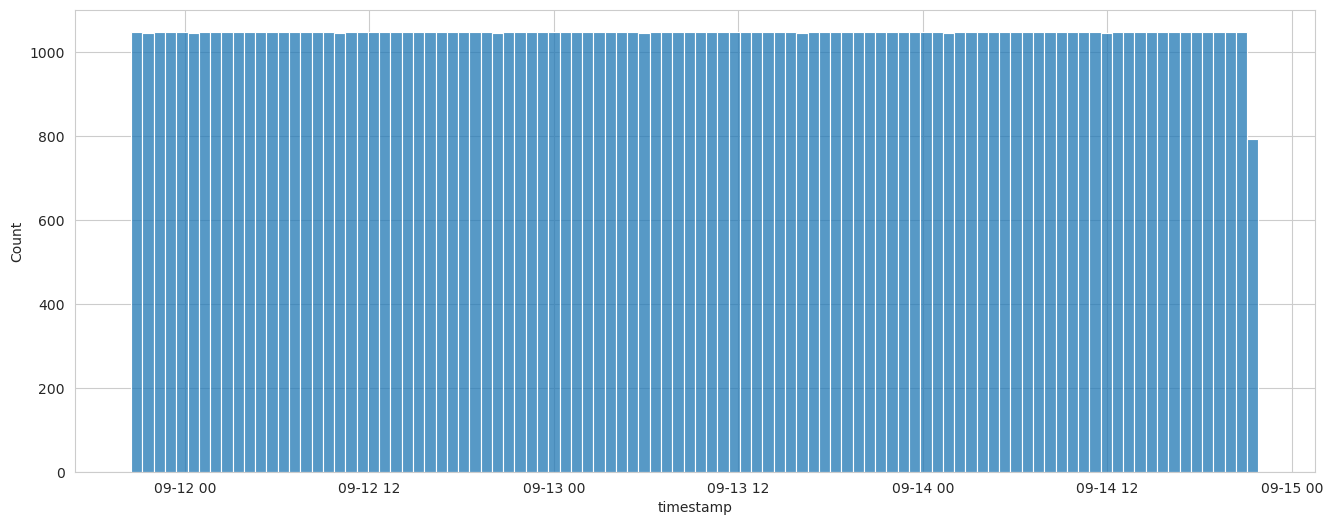

In [78]:
data = [(to_dt(ts), count) for ts, count in blocks]
df = pd.DataFrame(data, columns=['timestamp', 'transaction_count'])

plt.figure(figsize=(16, 6))
sns.histplot(df[df.timestamp > datetime(2025, 9, 10)].timestamp, bins=100)
plt.show()

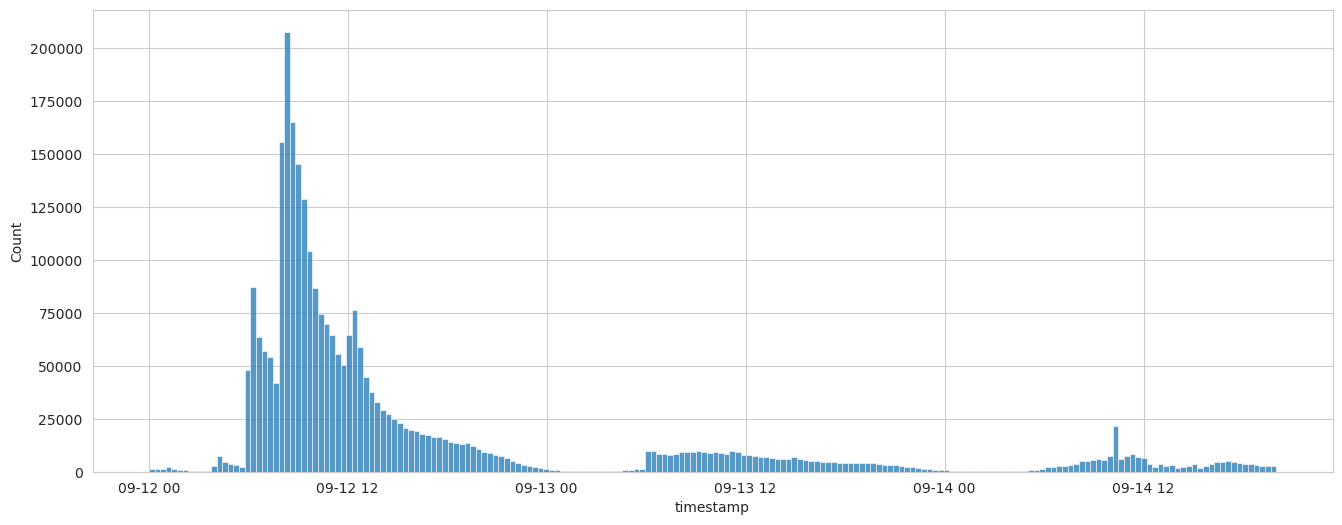

In [15]:
data = []

for contract_id, l in signatures.items():
    for region, uik, ts in l:
        data.append((contract_id, region, uik, ts))

df = pd.DataFrame(data, columns=['election', 'region', 'uik', 'timestamp'])


plt.figure(figsize=(16, 6))

#sns.histplot(df[(df.region == 2) & (df.timestamp < datetime(2024, 9, 6, 4, 10))].timestamp, bins=200)
#sns.histplot(df[(df.region == 50) & (df.timestamp < datetime(2024, 9, 6, 8, 10))].timestamp, bins=200)
#sns.histplot(df[(df.timestamp > datetime(2025, 9, 12, 10)) & (df.timestamp < datetime(2025, 9, 12, 15))].timestamp, bins=200)
sns.histplot(df.timestamp[df.timestamp > datetime(2025, 9, 10)], bins=200)

plt.show()
#plt.savefig('turnout.png')

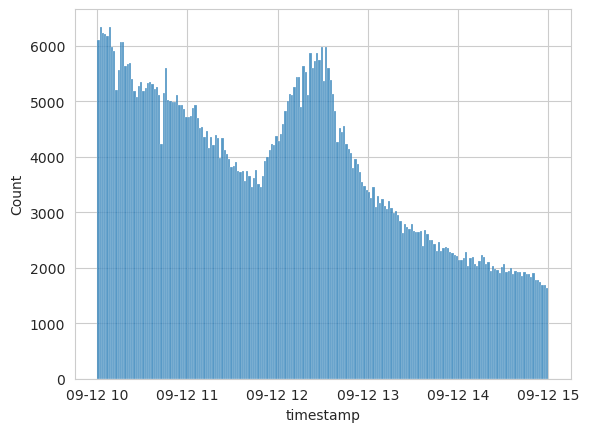

In [24]:
sns.histplot(df[(df.timestamp > datetime(2025, 9, 12, 10)) & (df.timestamp < datetime(2025, 9, 12, 15))].timestamp, bins=200)
plt.show()

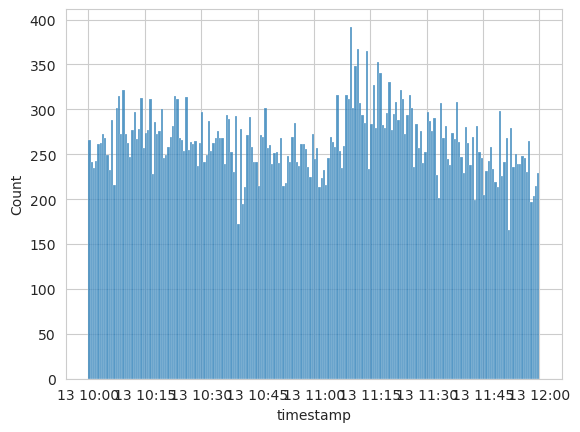

In [25]:
sns.histplot(df[(df.timestamp > datetime(2025, 9, 13, 10)) & (df.timestamp < datetime(2025, 9, 13, 12))].timestamp, bins=200)
plt.show()

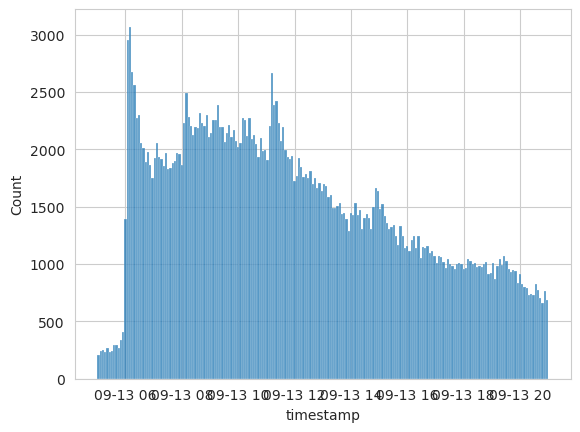

In [26]:
sns.histplot(df[(df.timestamp > datetime(2025, 9, 13, 5)) & (df.timestamp < datetime(2025, 9, 13, 21))].timestamp, bins=200)
plt.show()

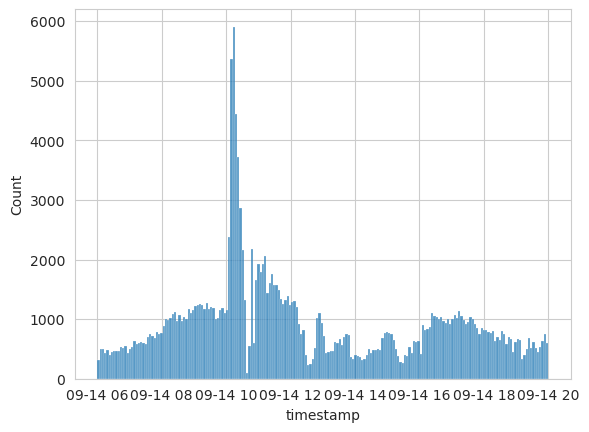

In [5]:
sns.histplot(df[(df.timestamp > datetime(2025, 9, 14, 6)) & (df.timestamp < datetime(2025, 9, 14, 21))].timestamp, bins=200)
plt.show()

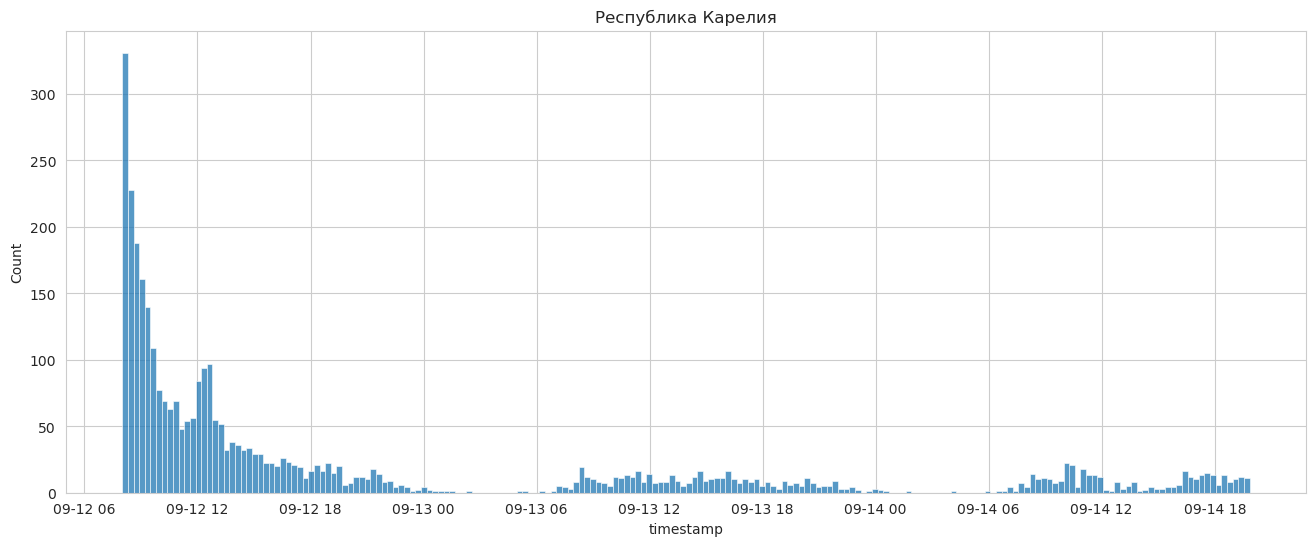

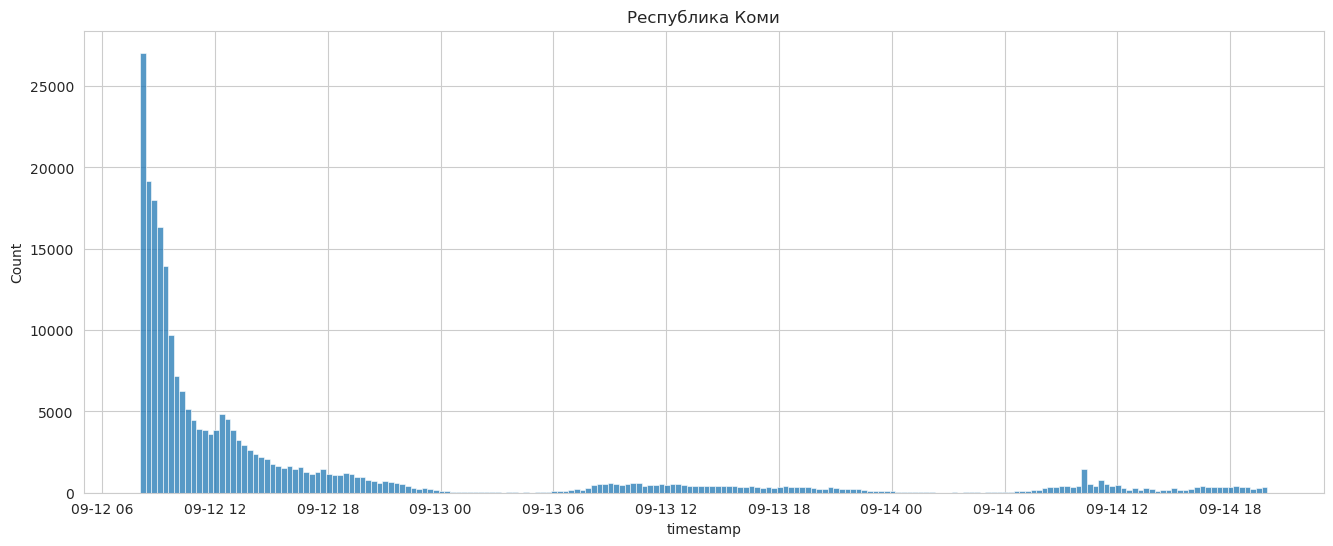

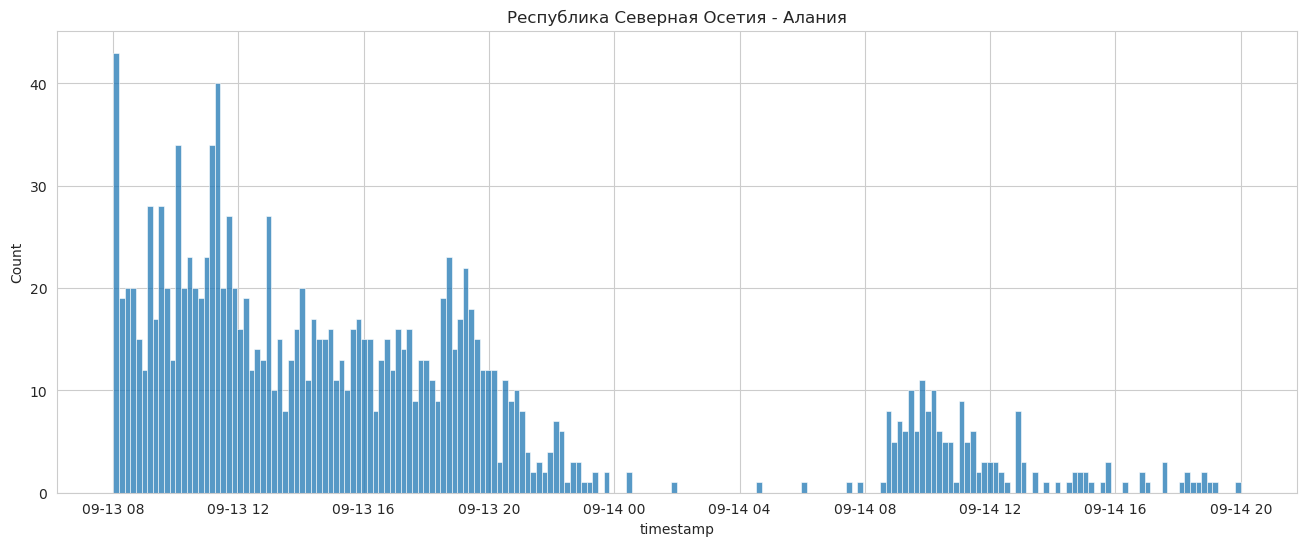

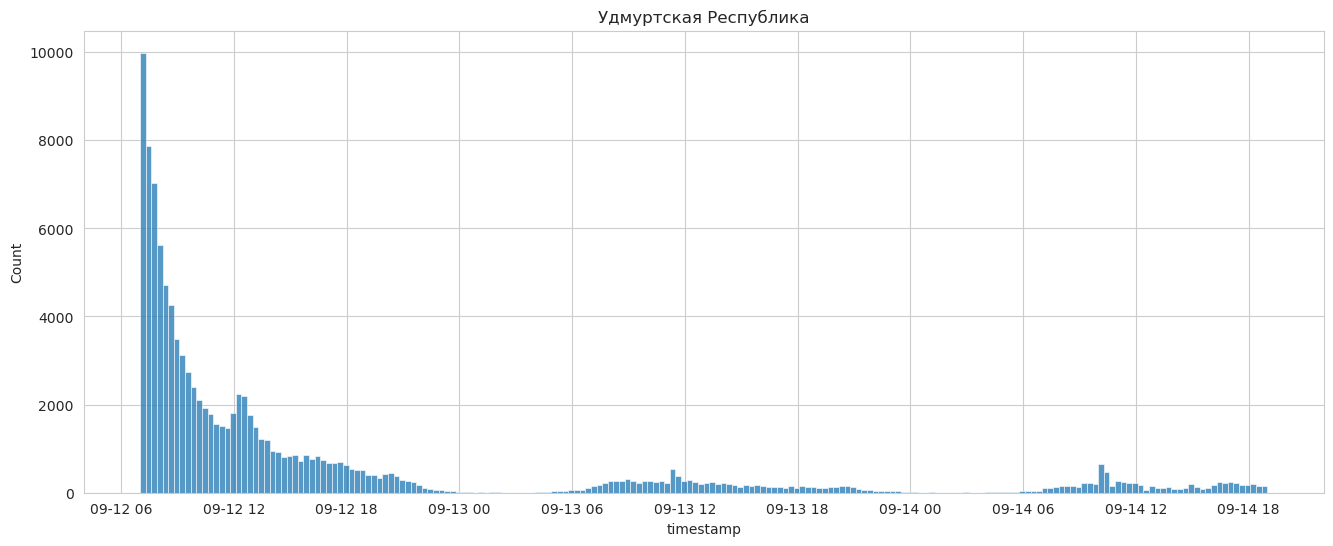

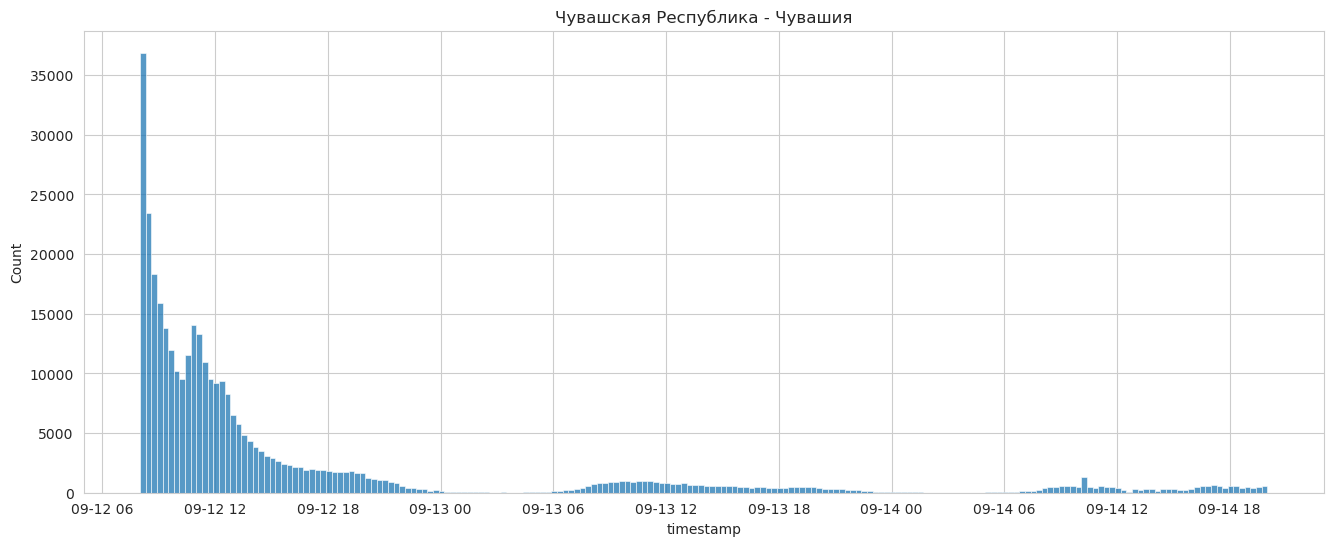

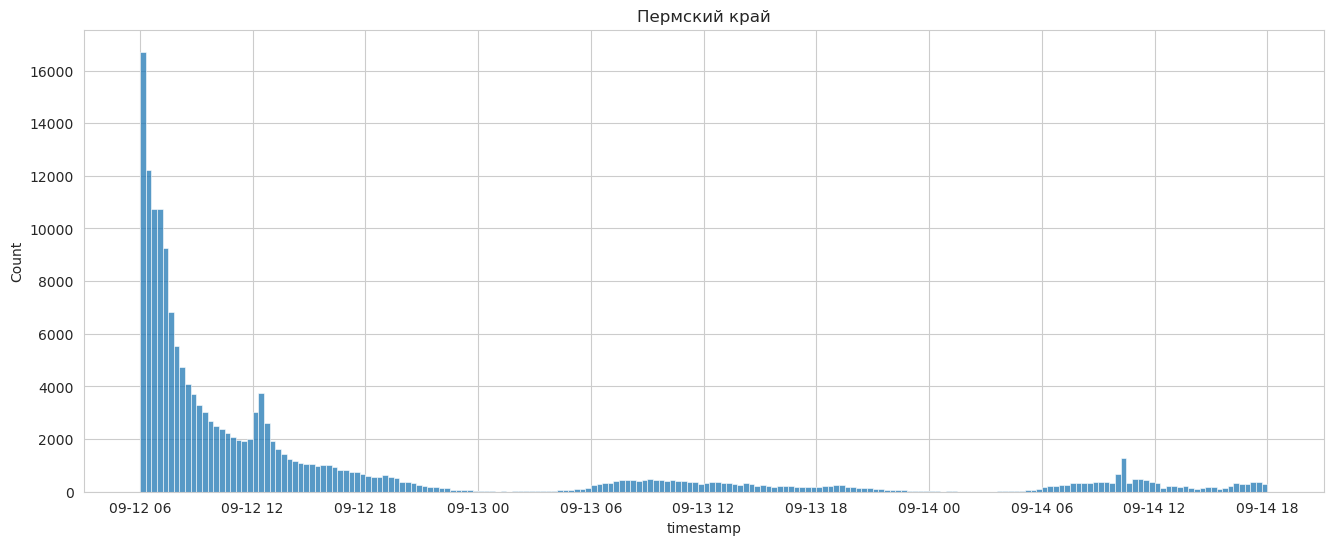

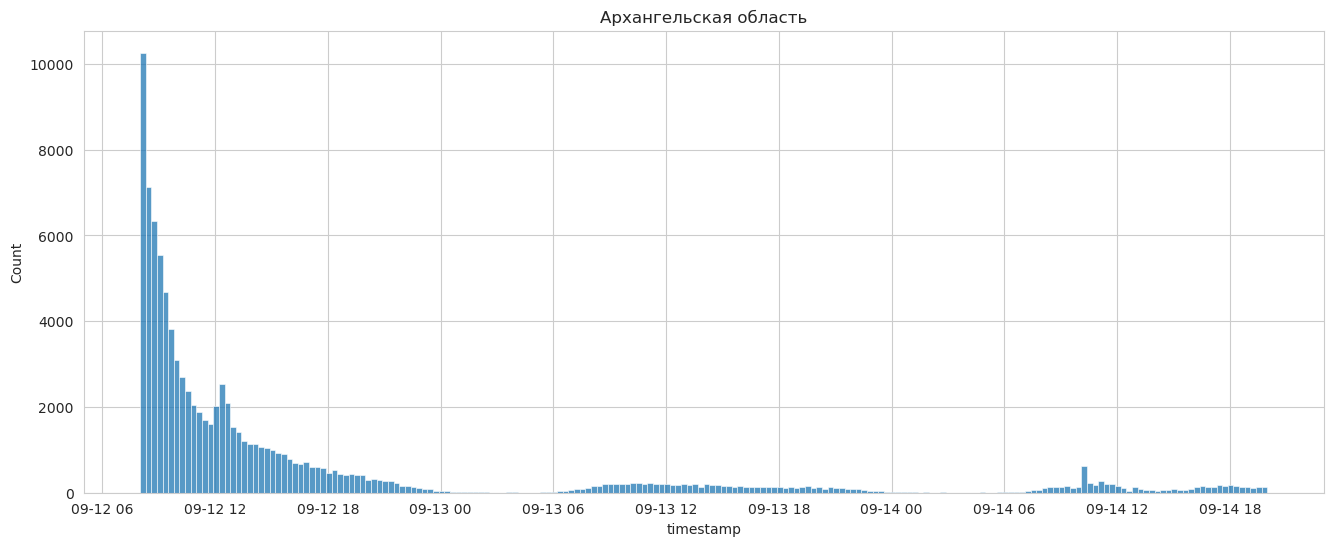

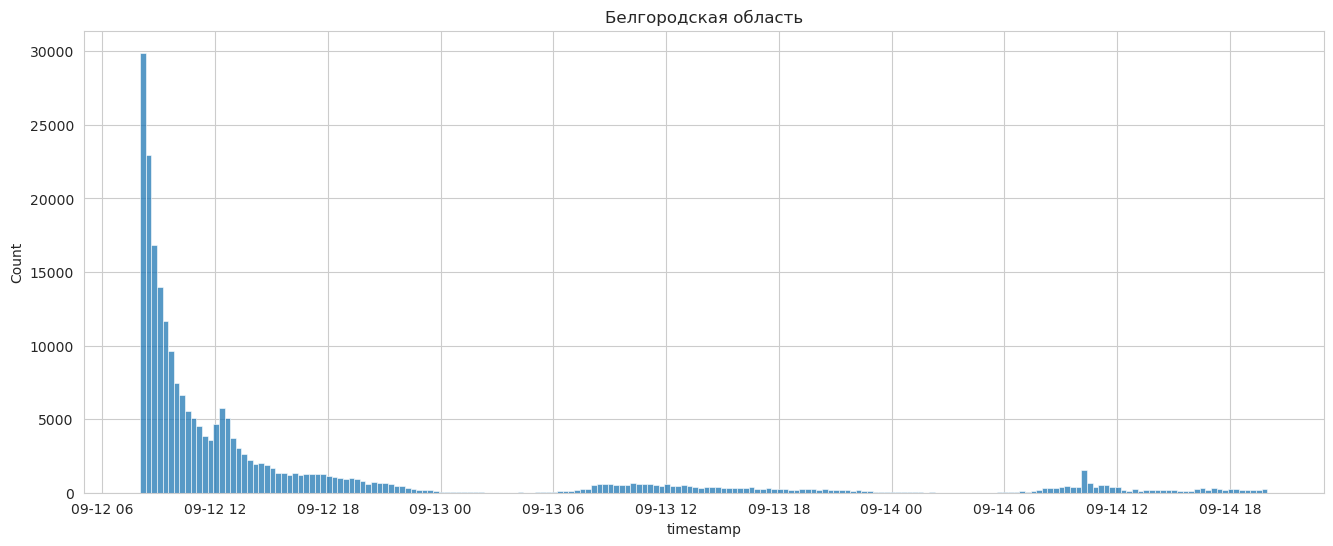

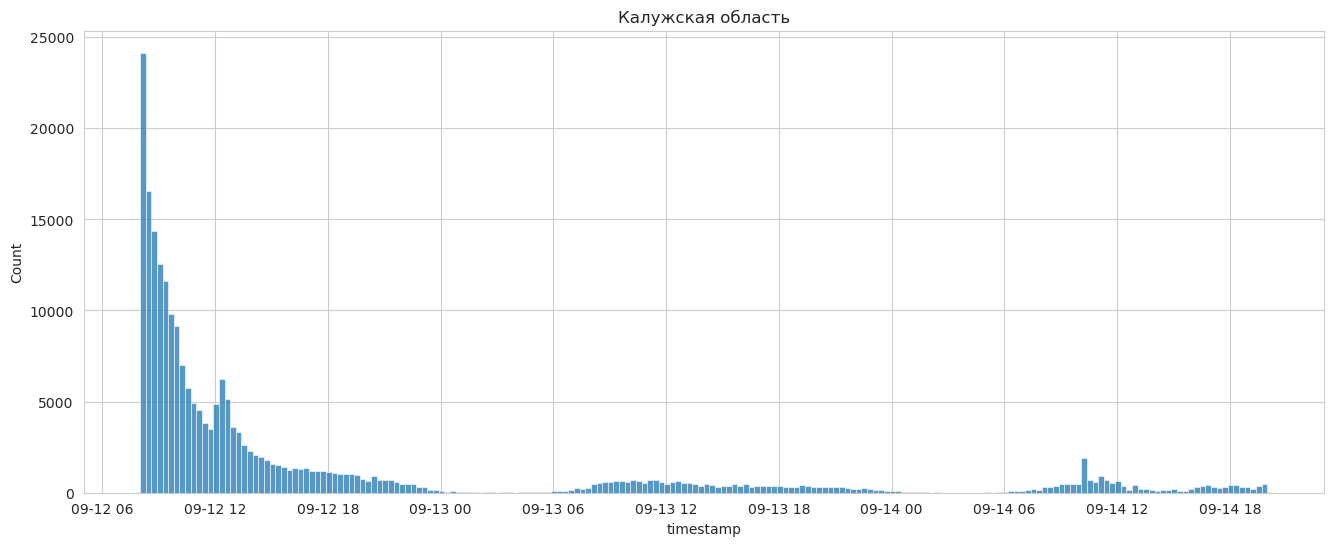

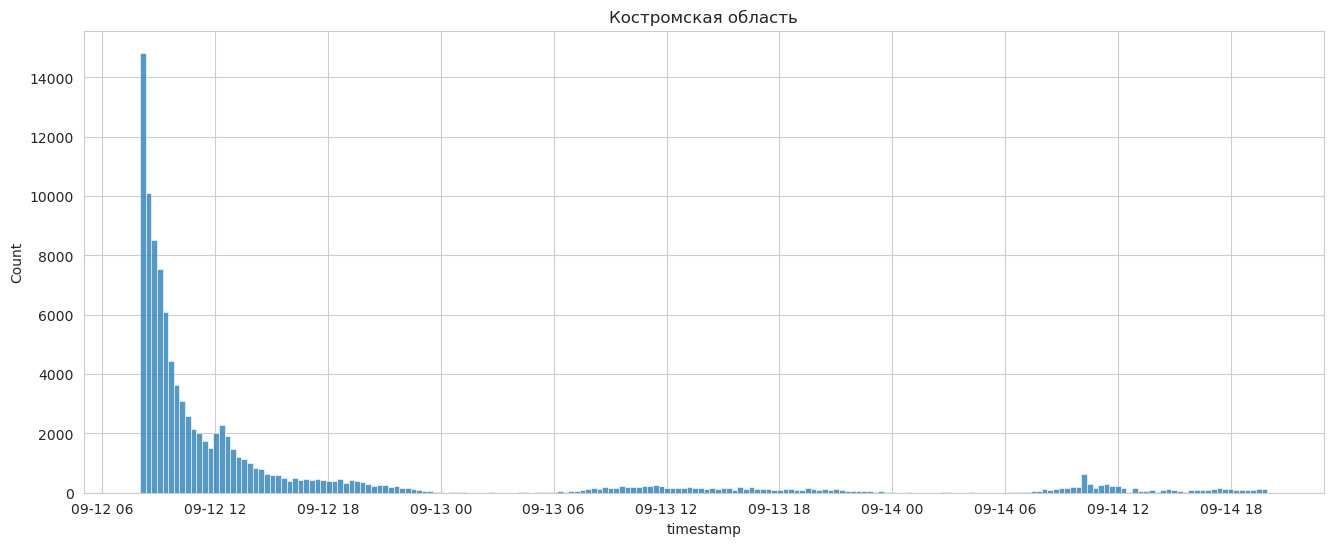

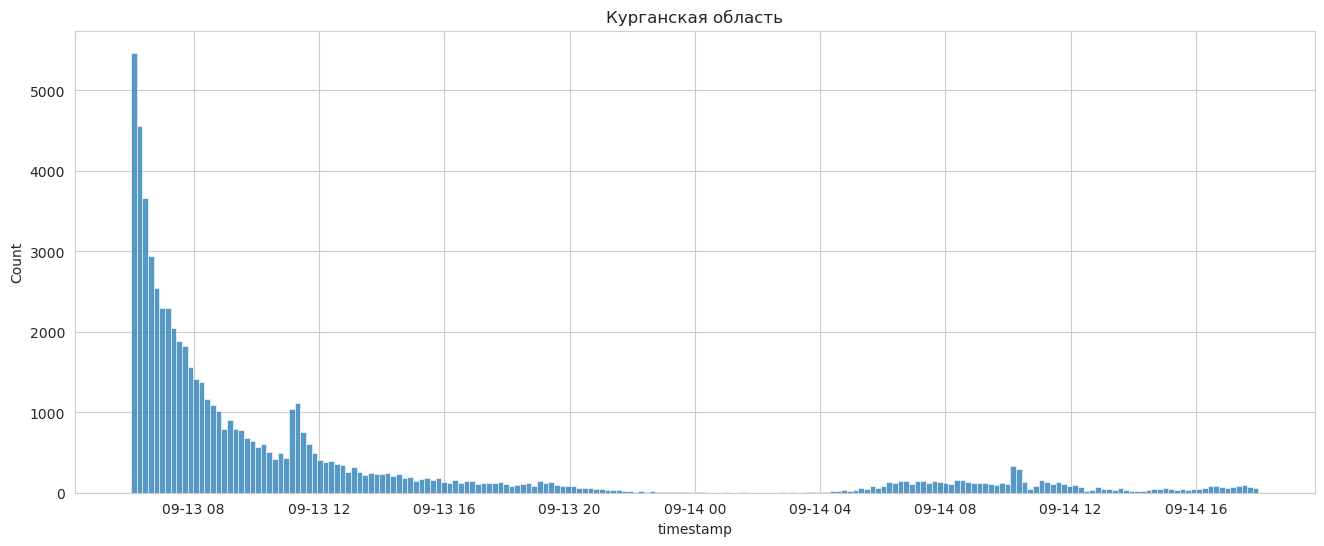

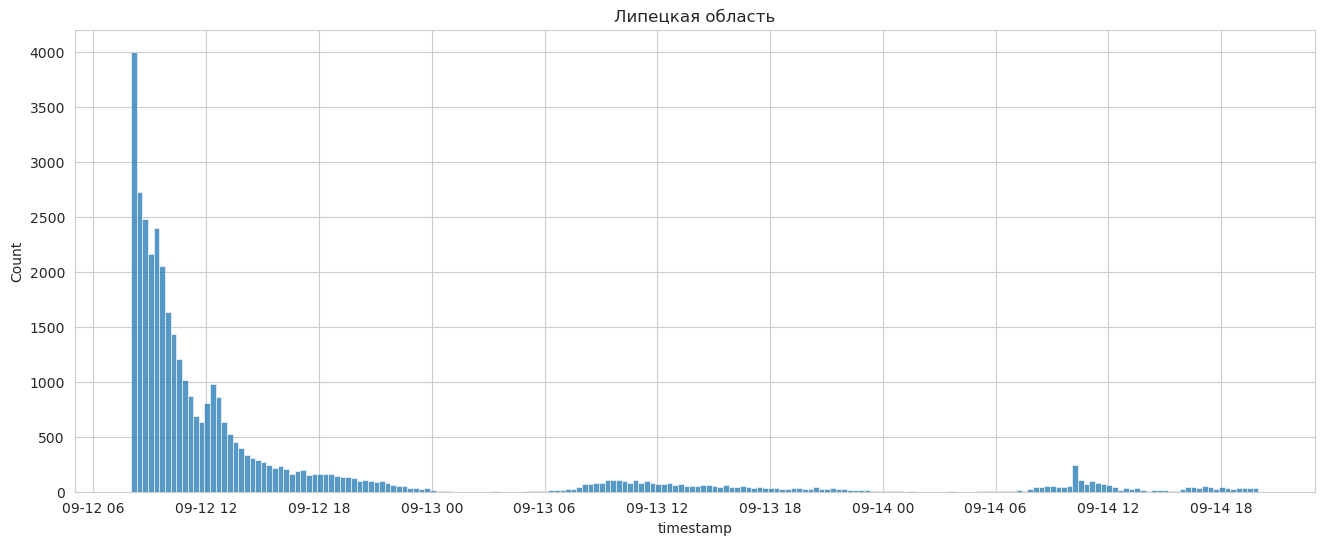

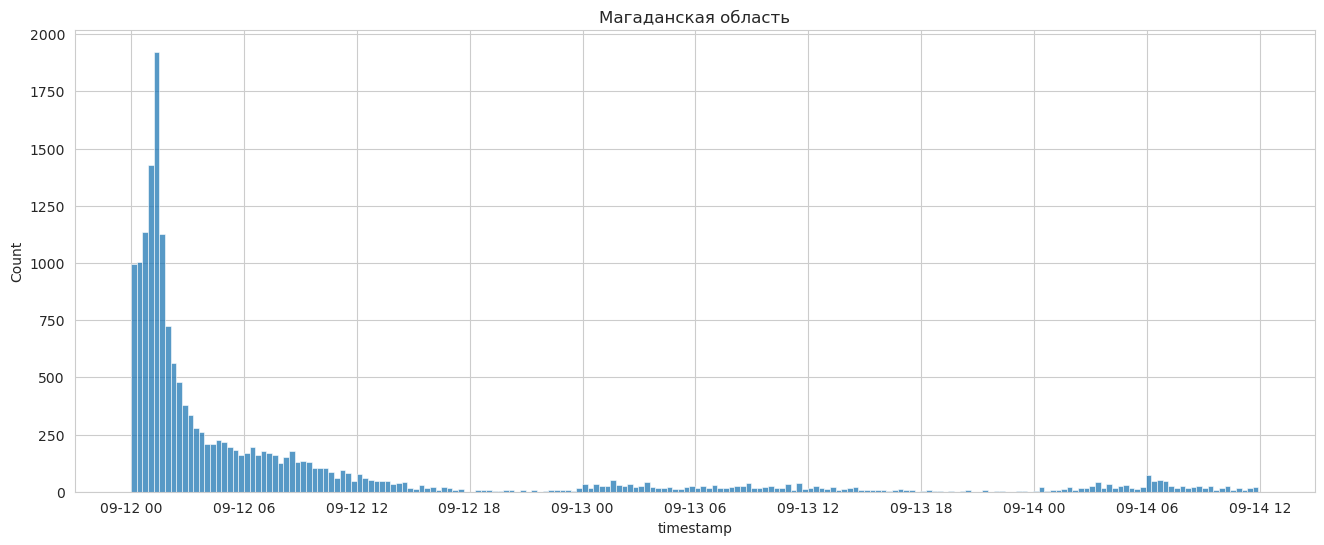

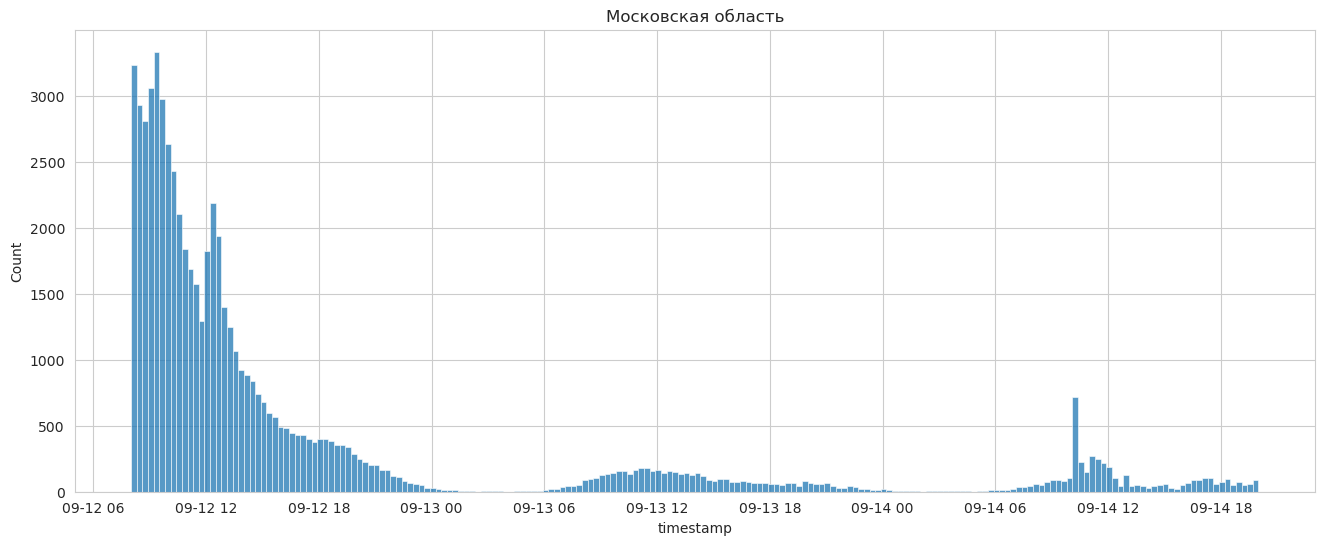

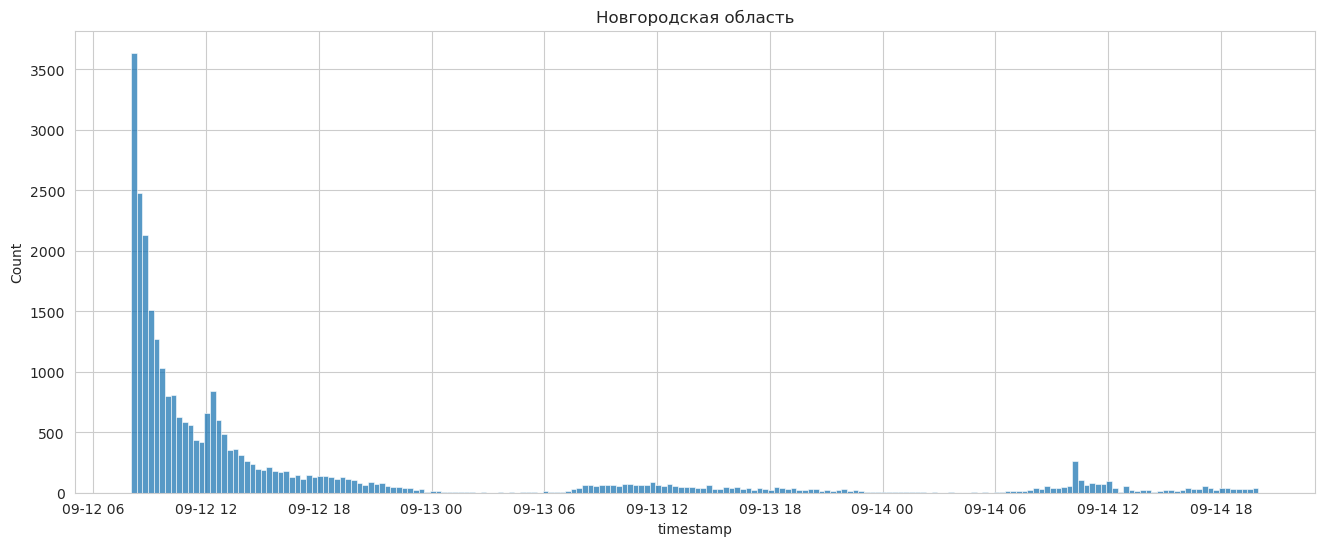

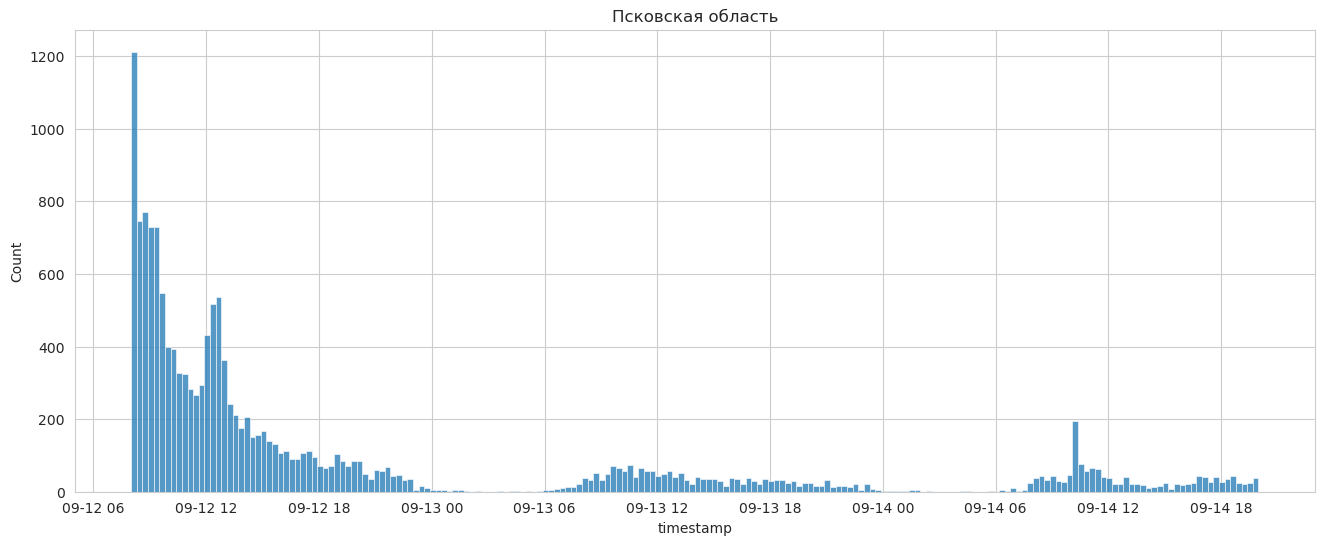

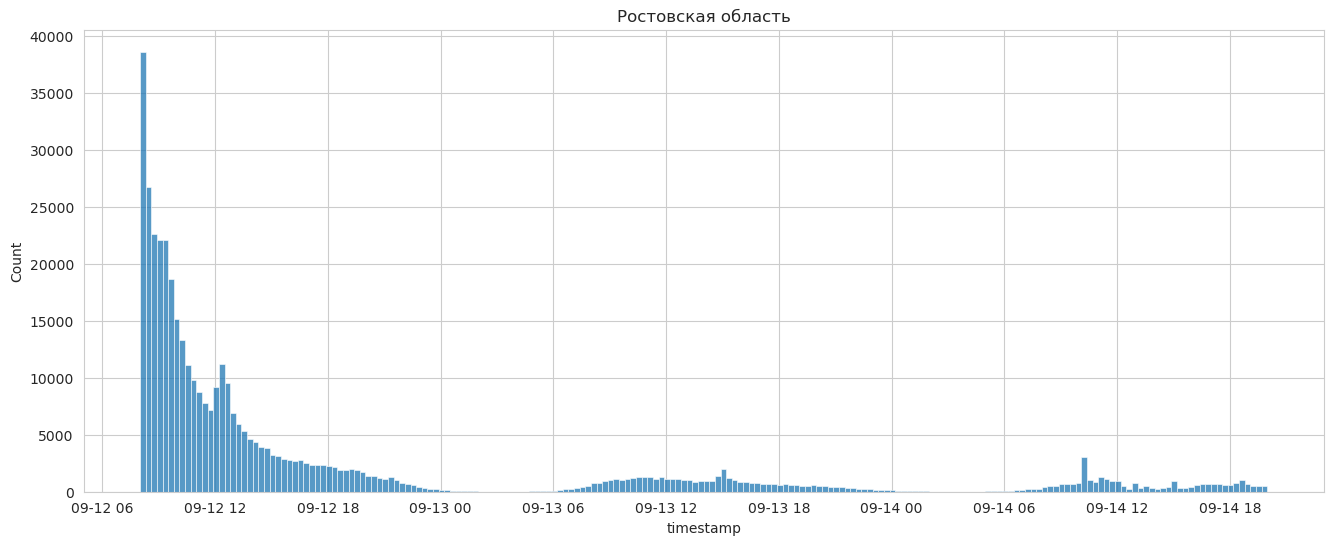

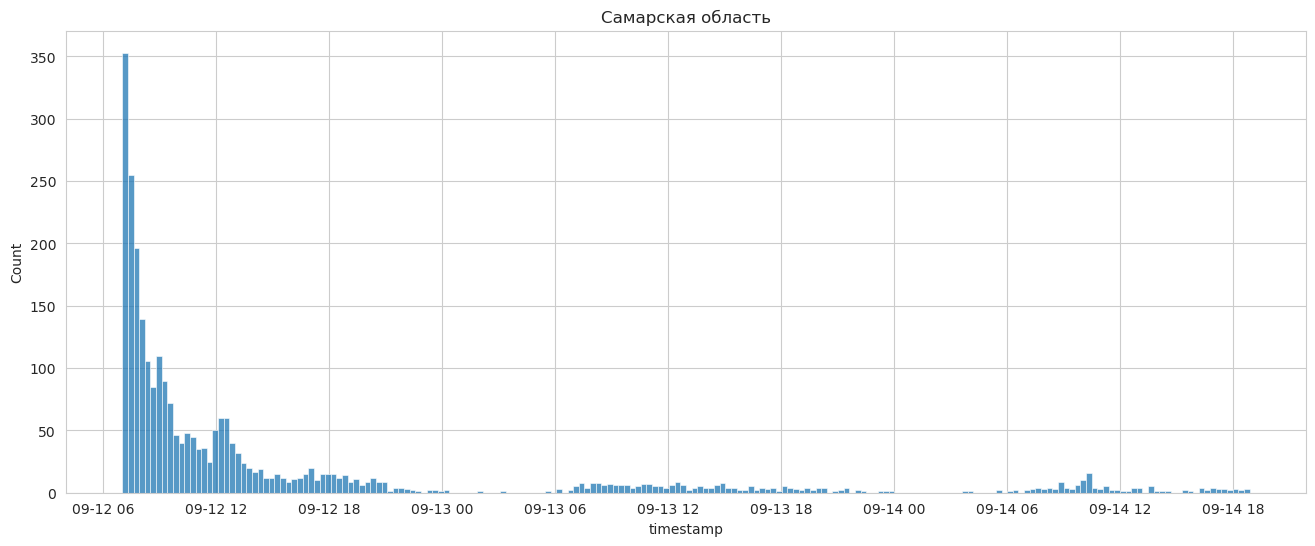

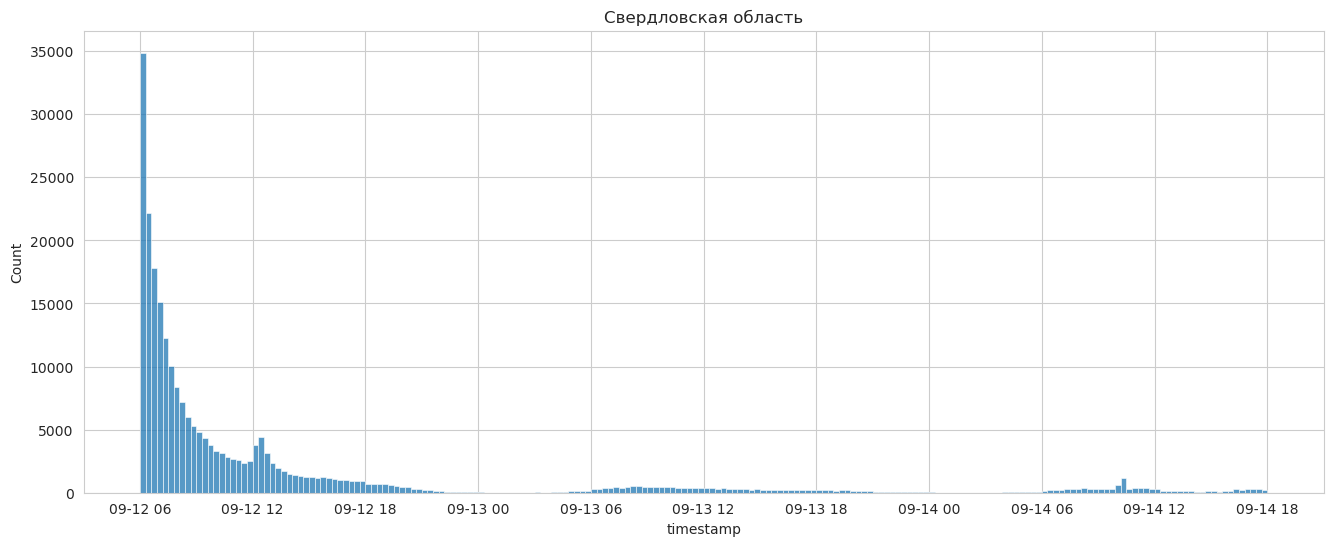

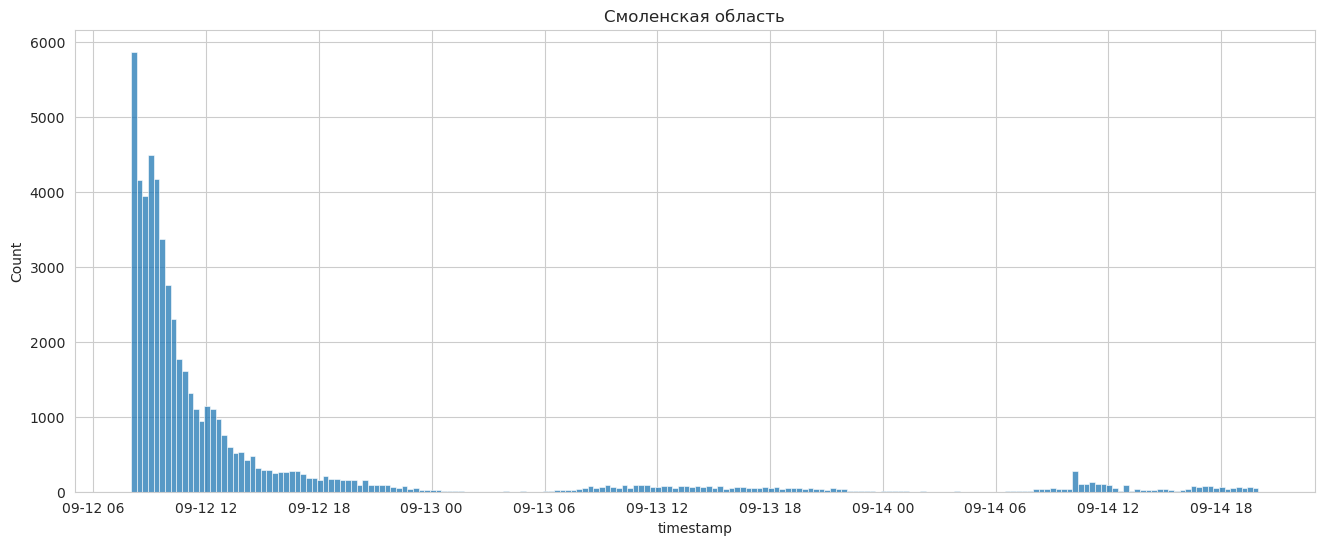

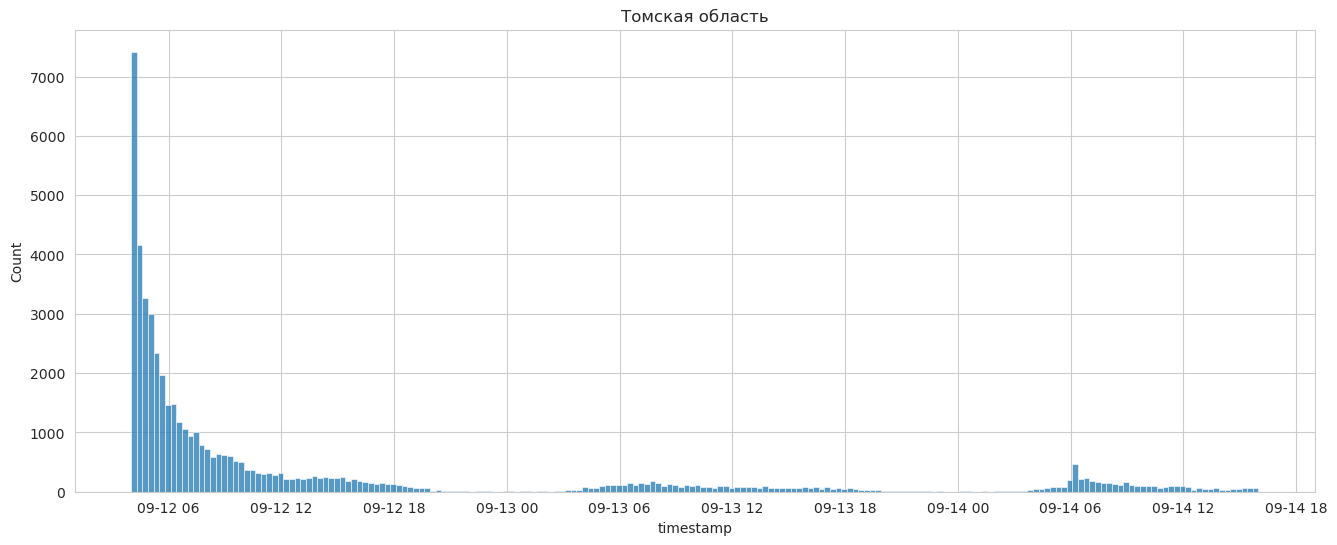

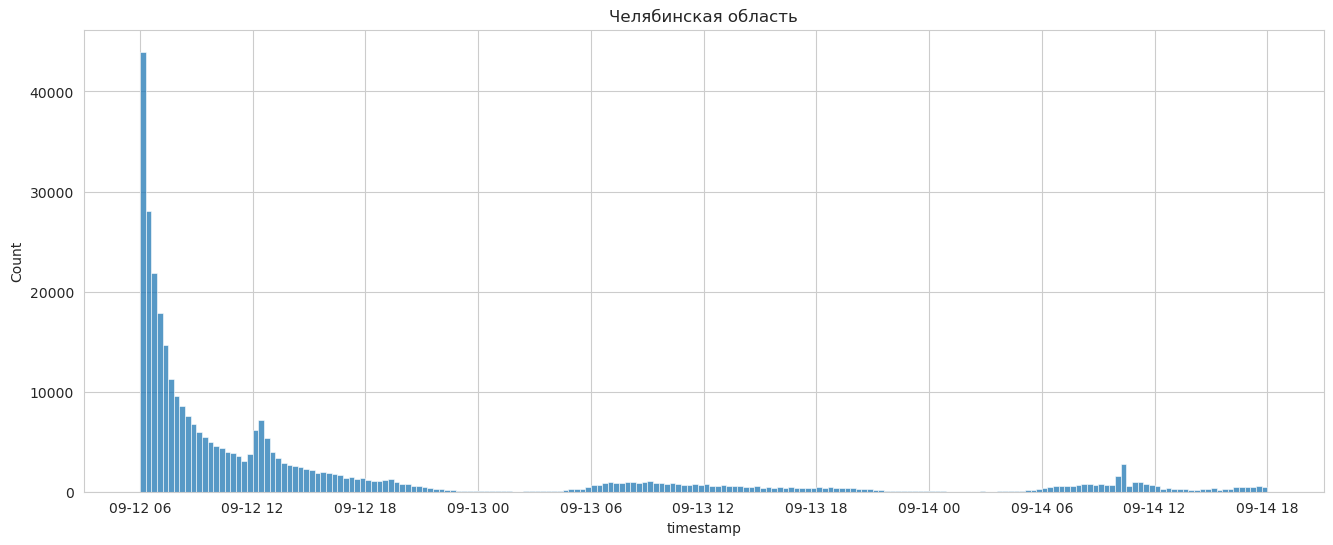

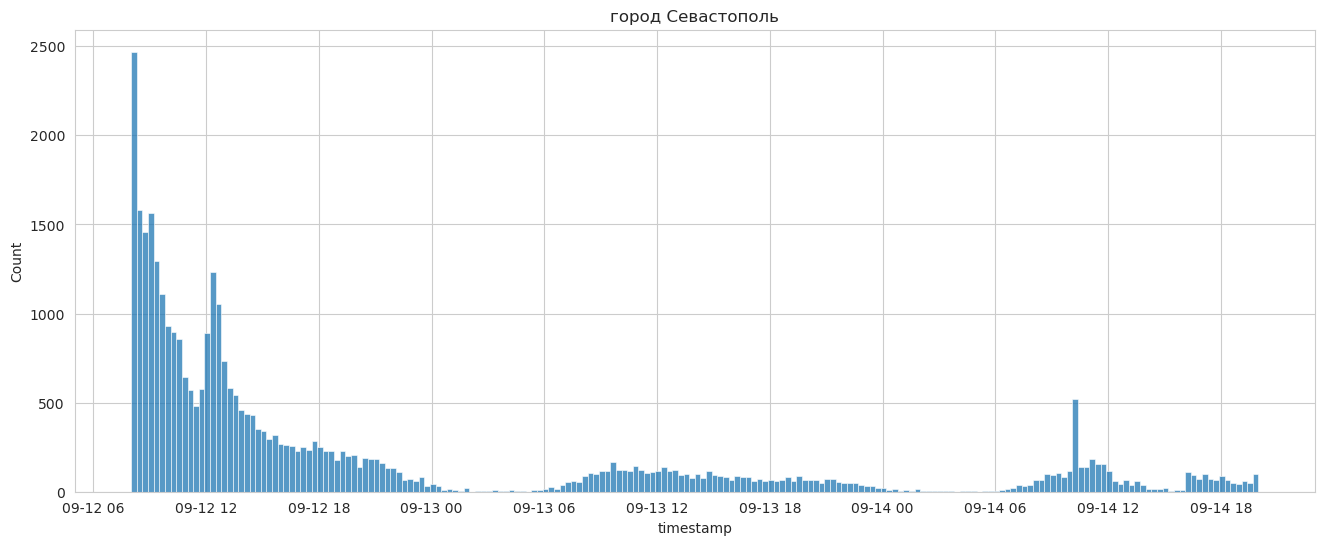

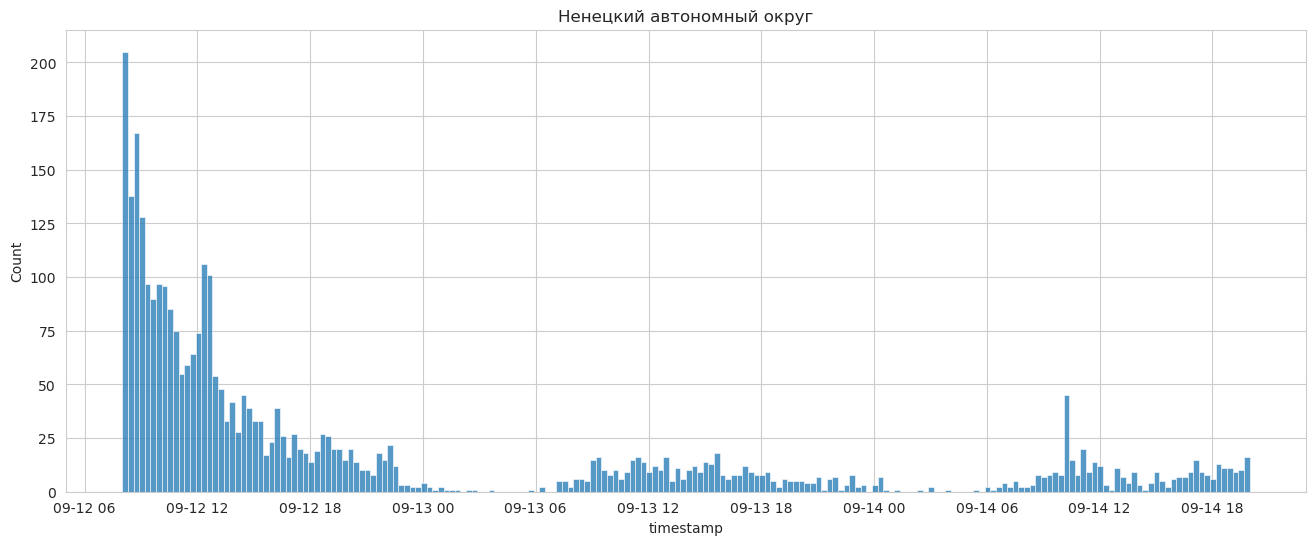

In [16]:
for region in map_regions:
    plt.figure(figsize=(16, 6))

    sns.histplot(df[df.region == region].timestamp, bins=200)
    plt.title(map_regions[region][1])
    plt.show()

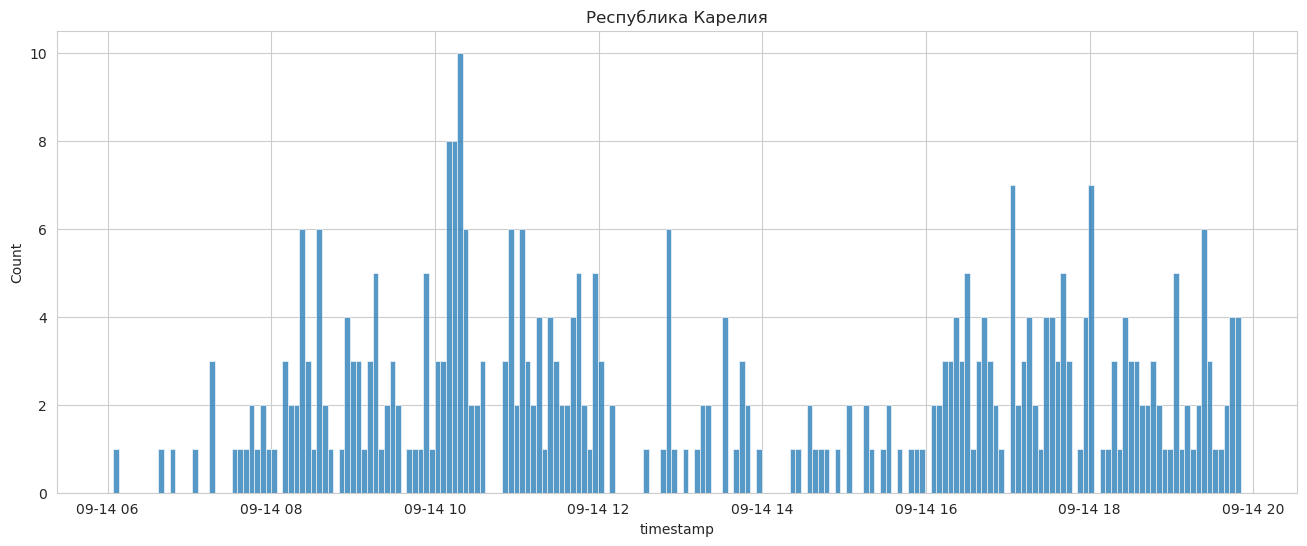

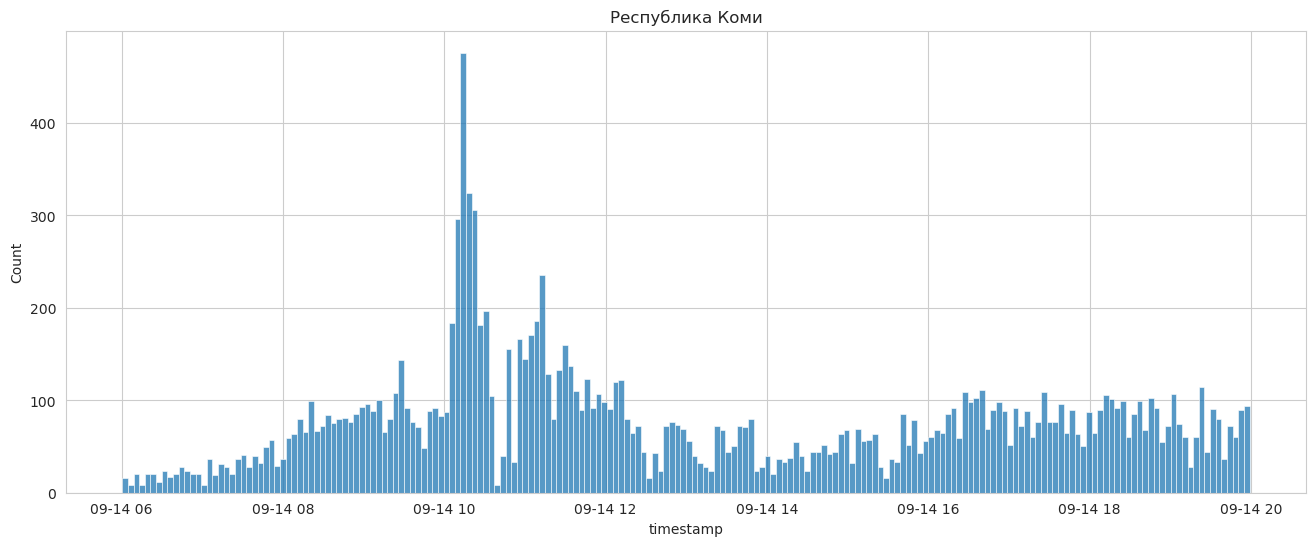

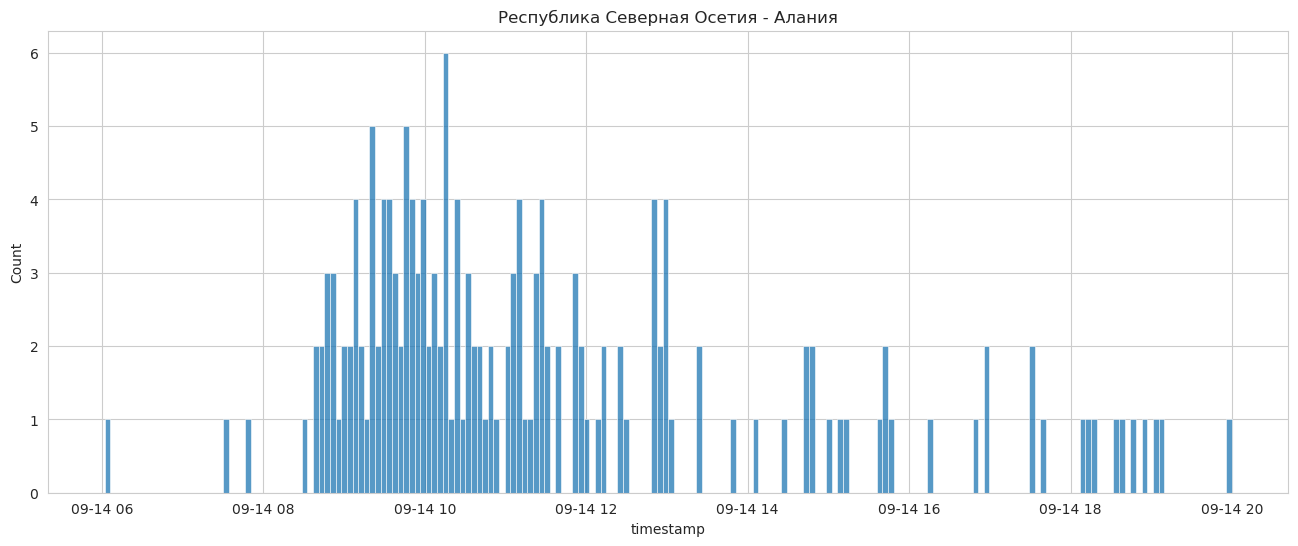

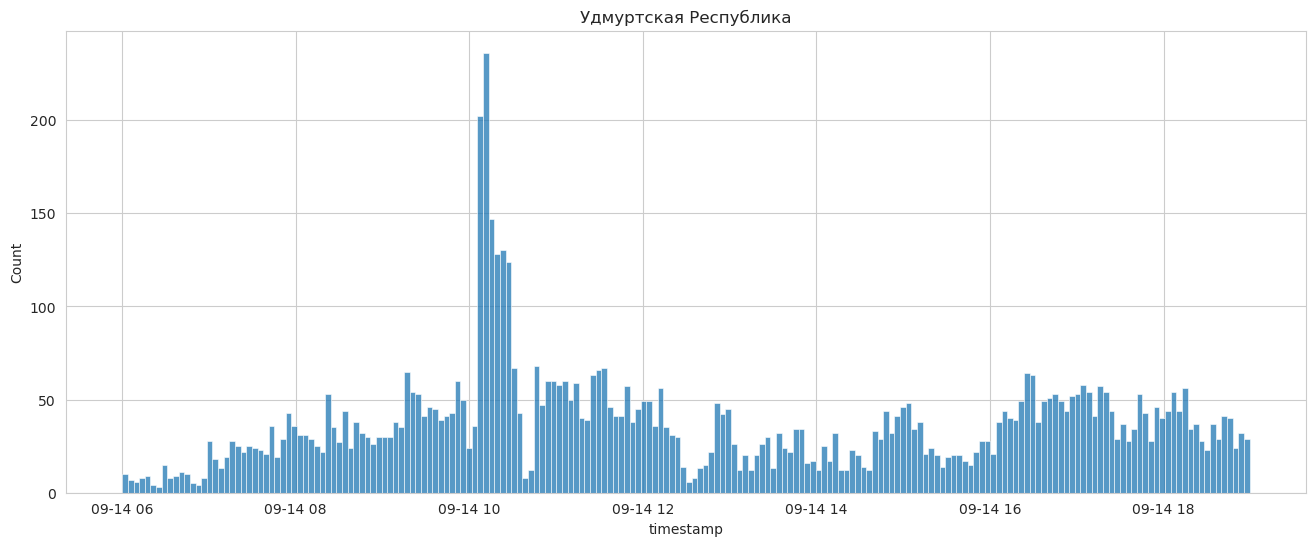

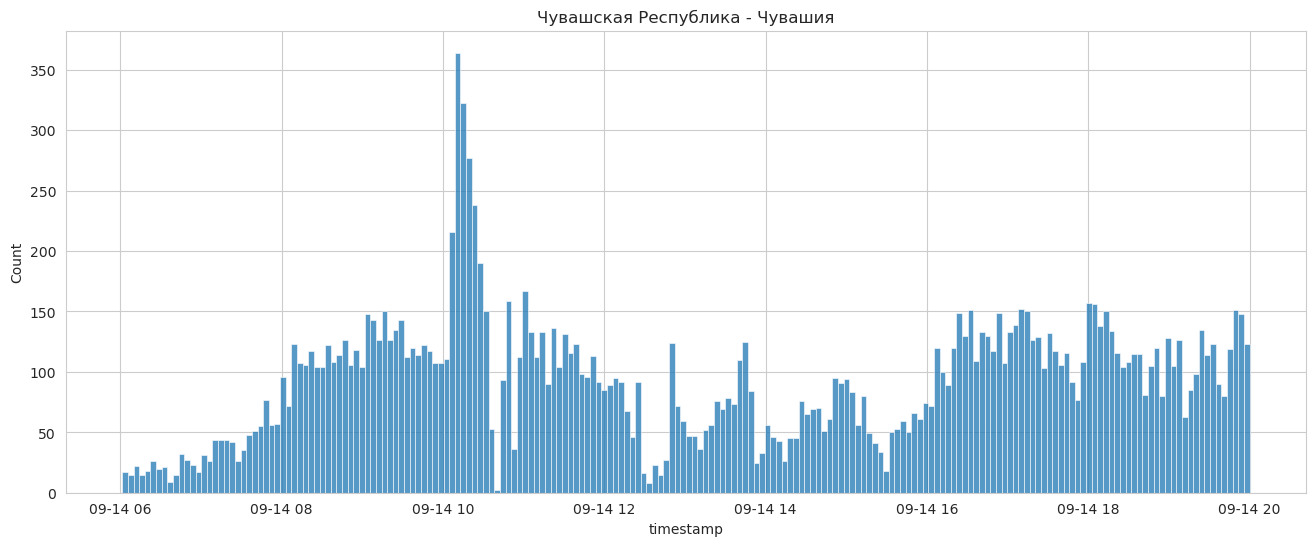

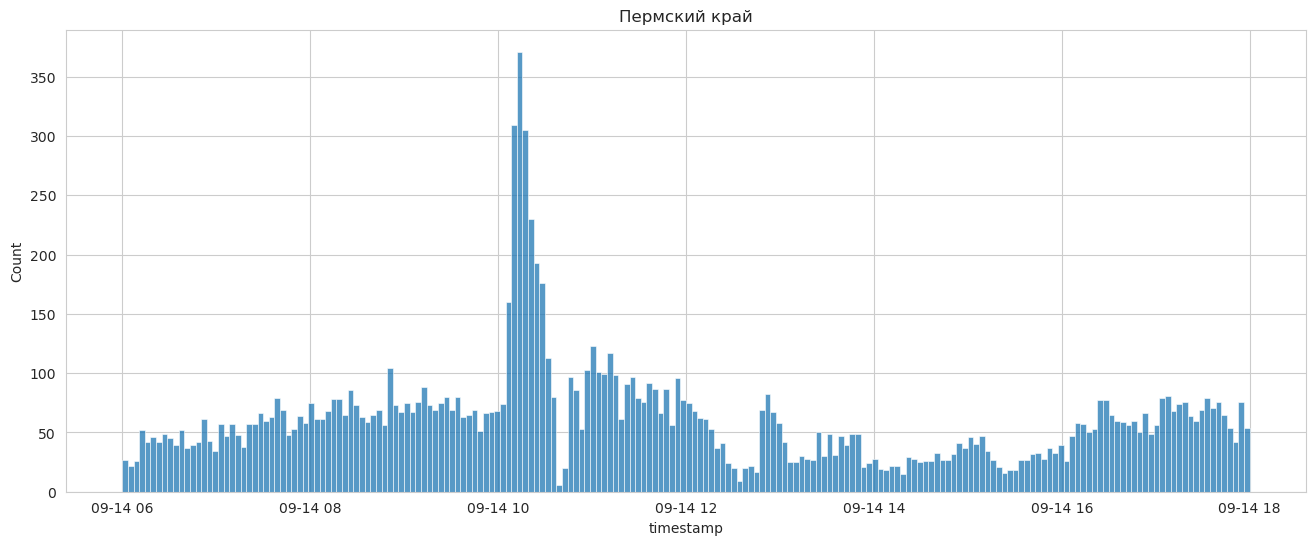

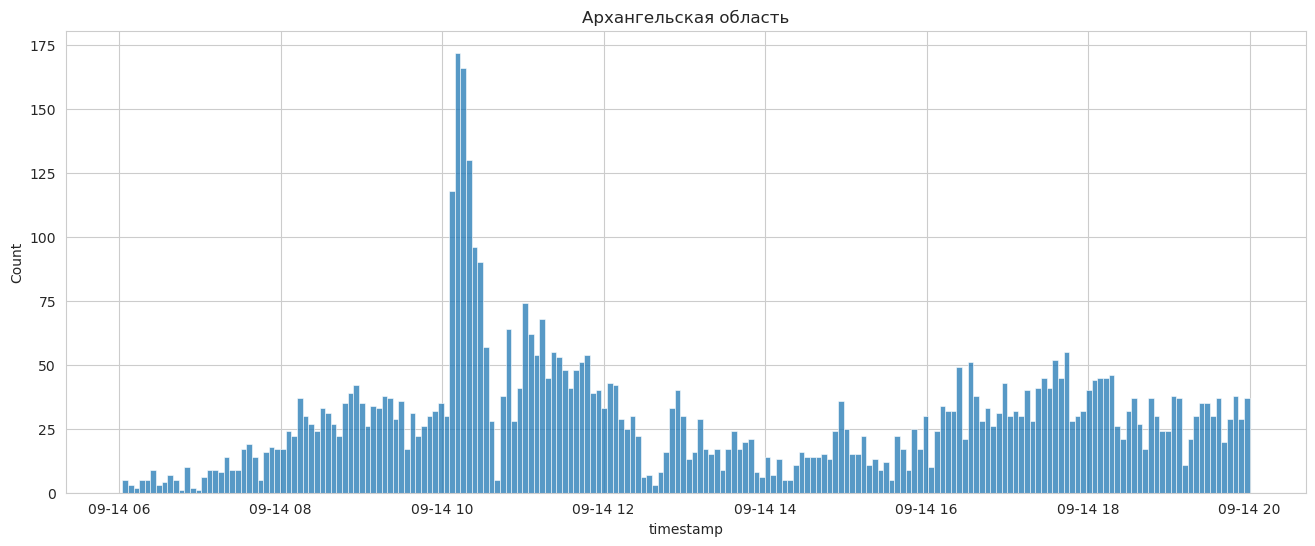

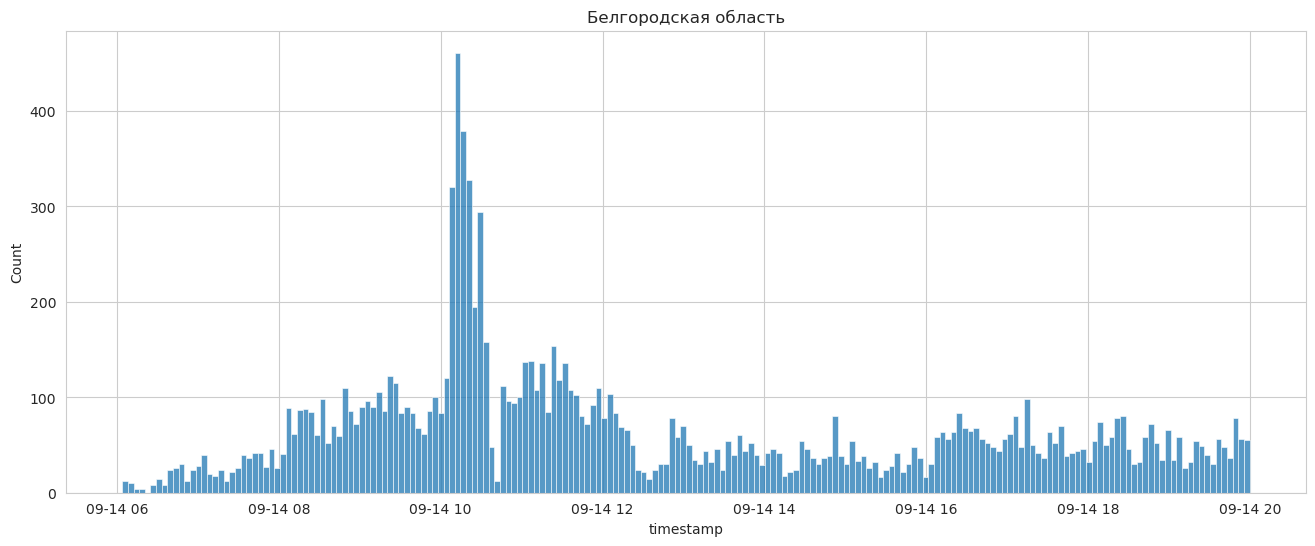

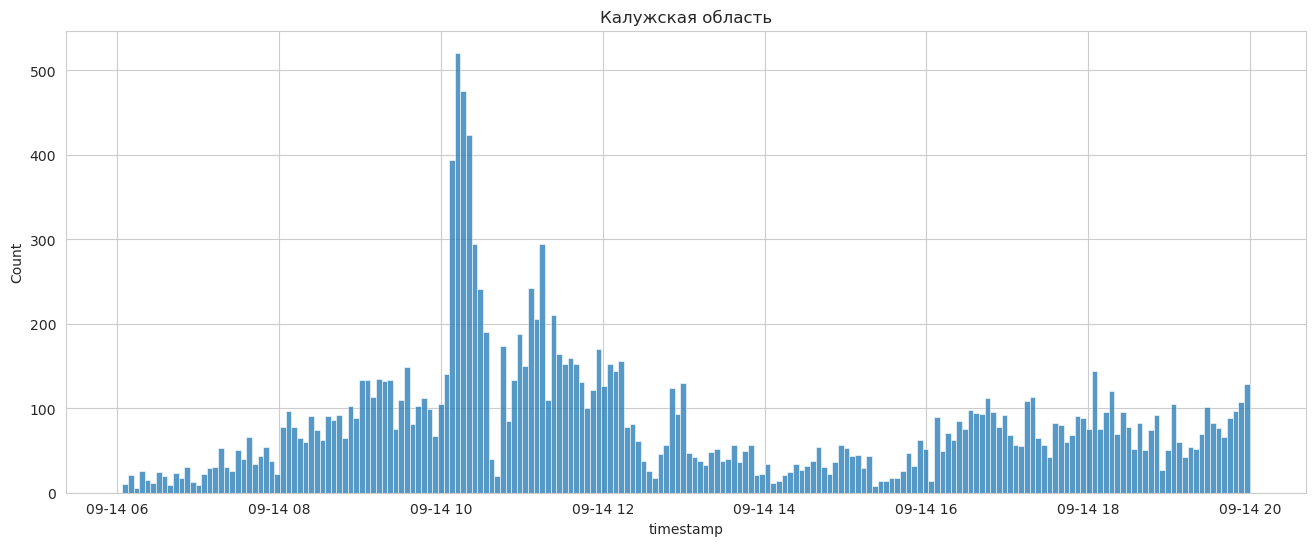

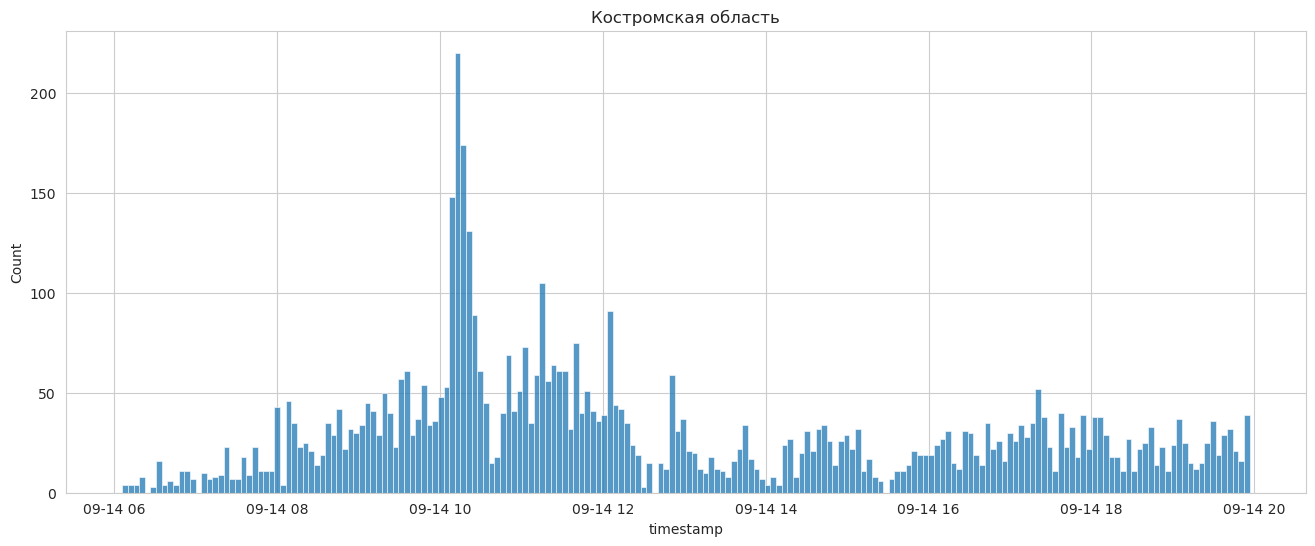

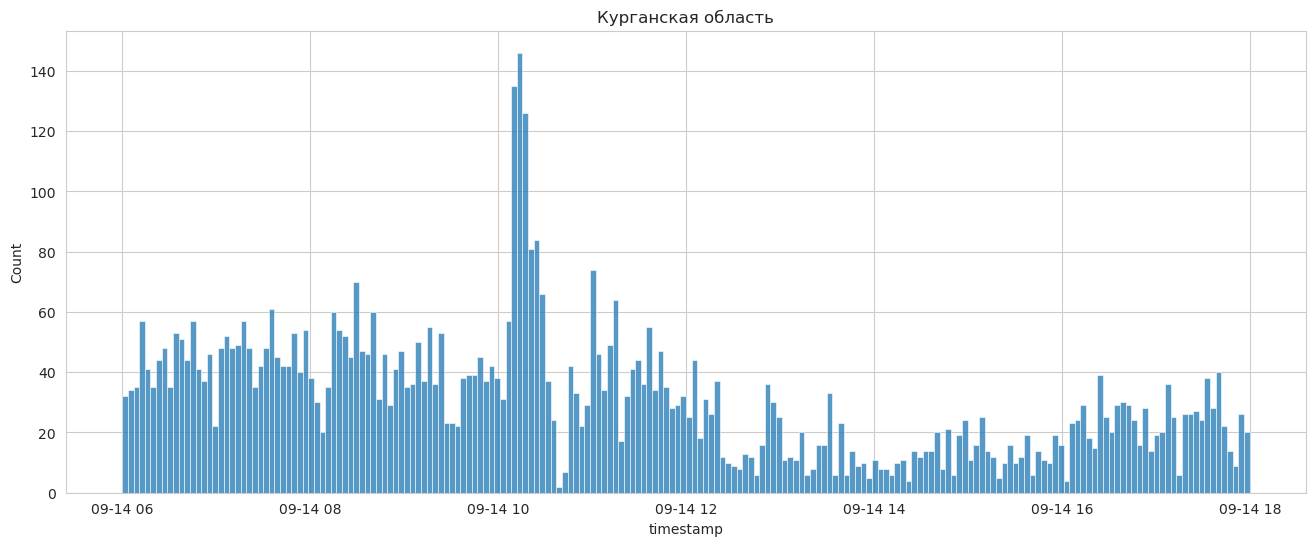

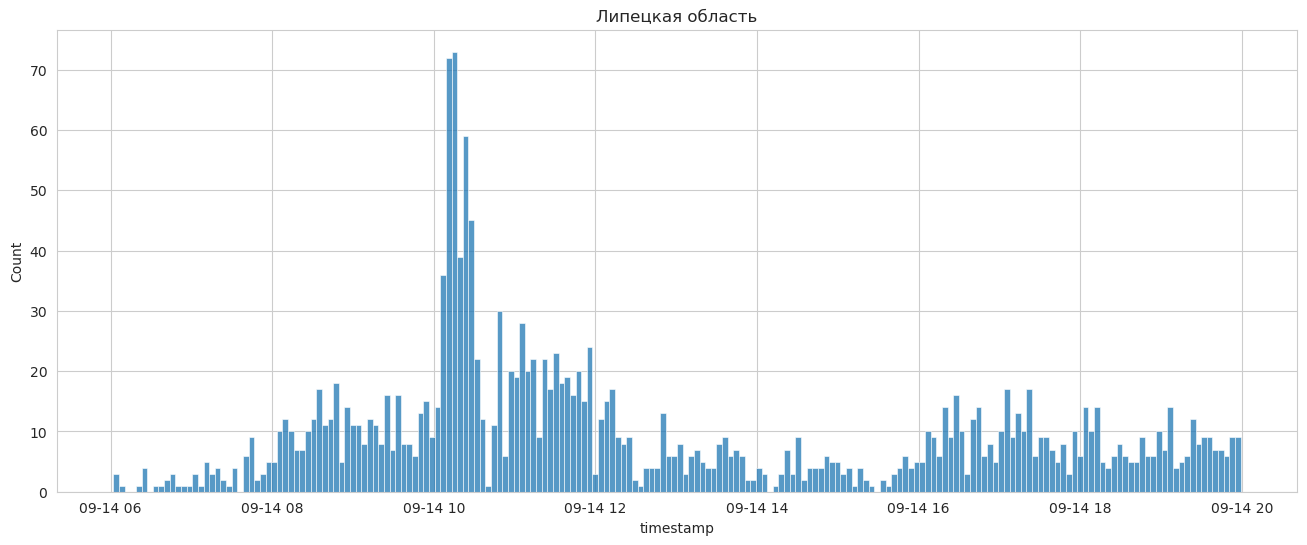

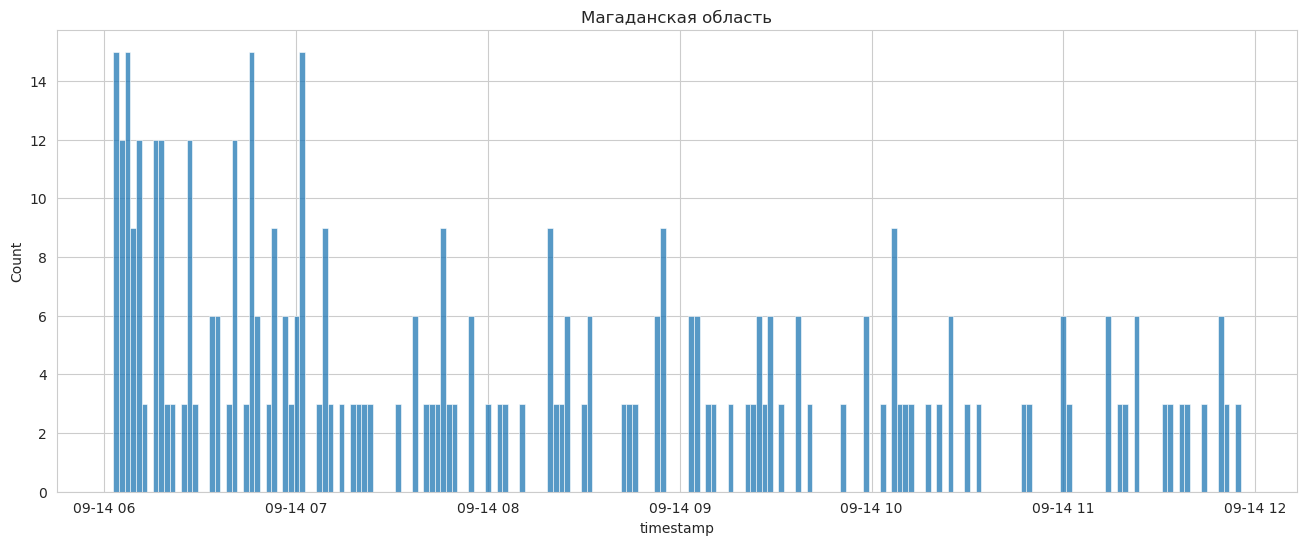

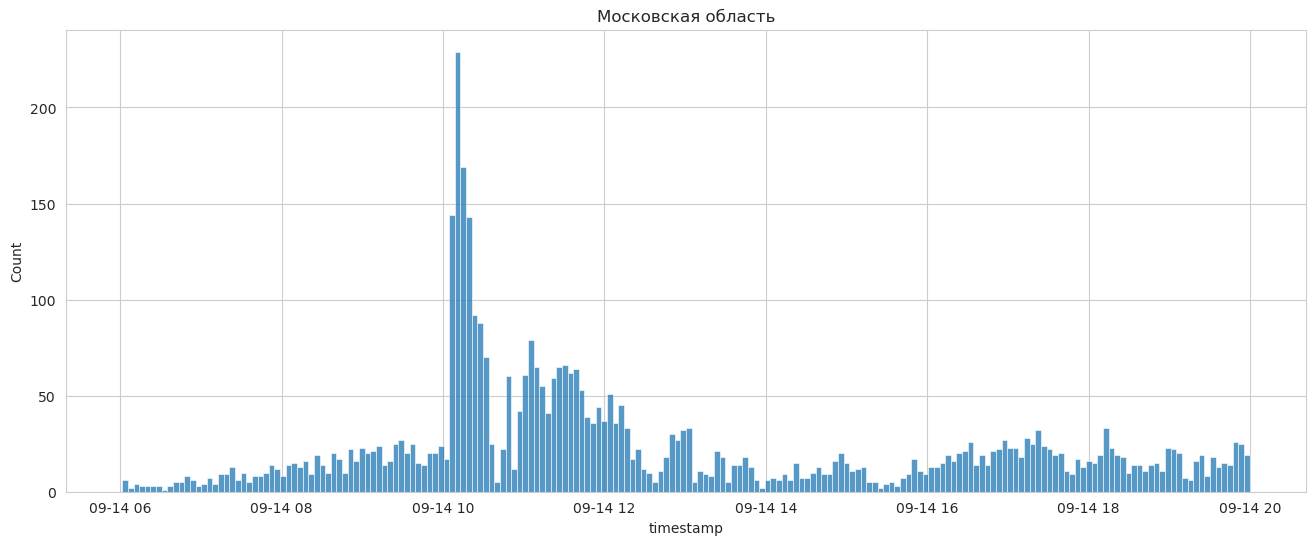

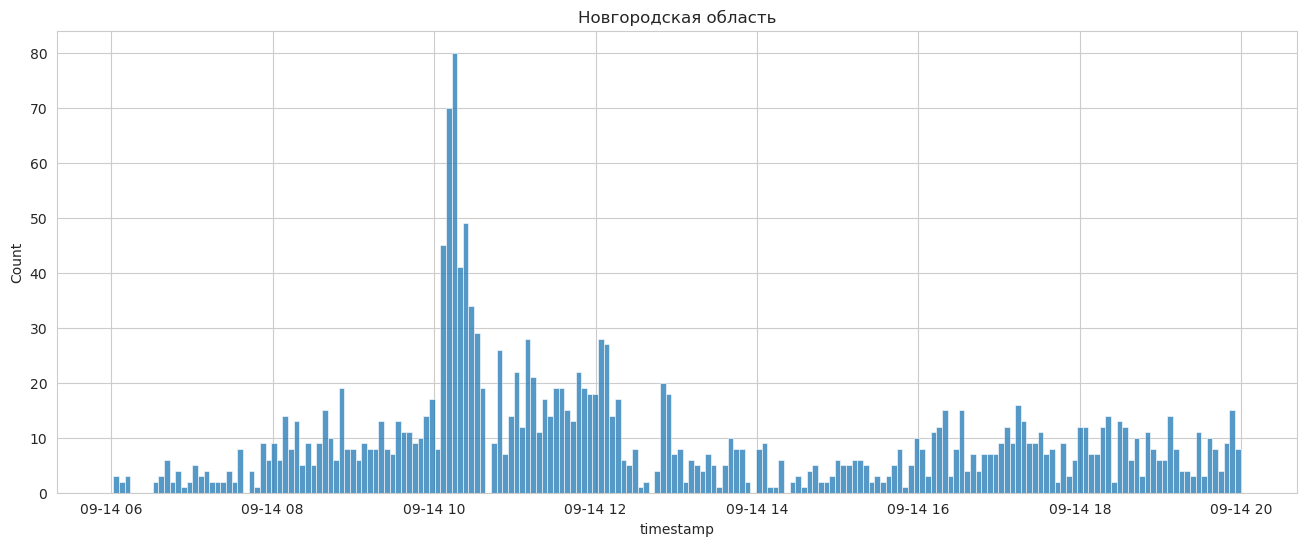

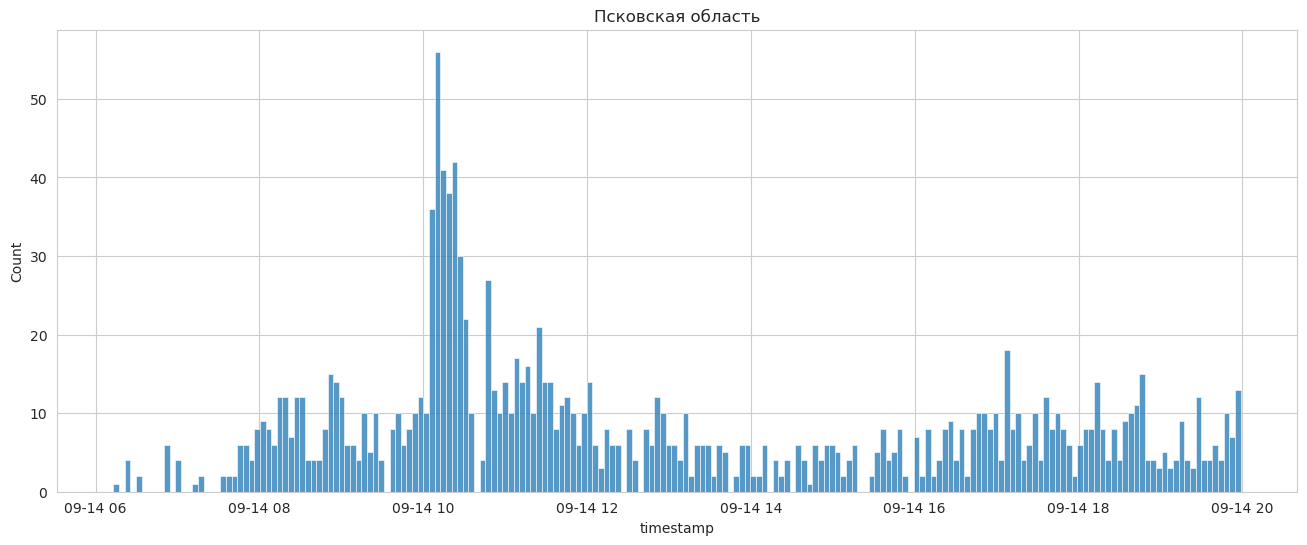

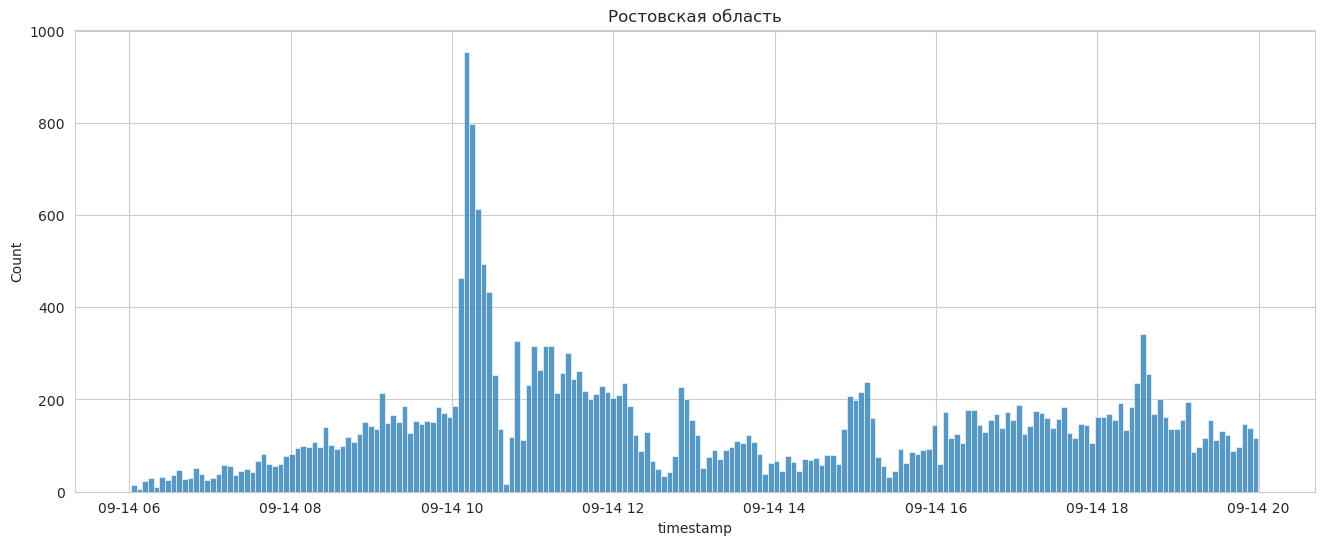

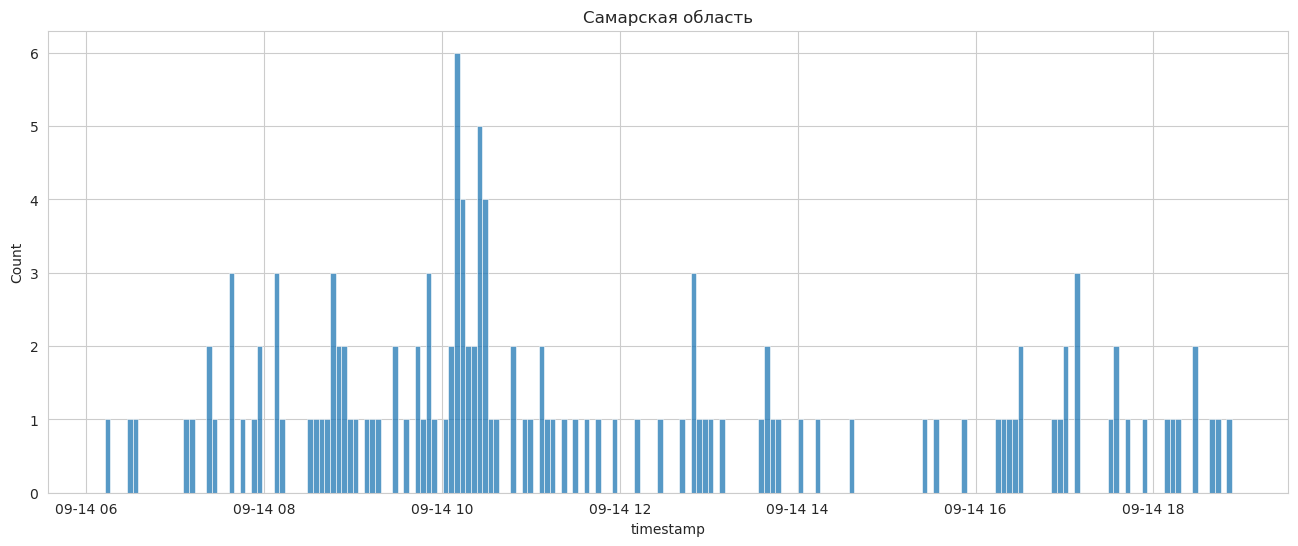

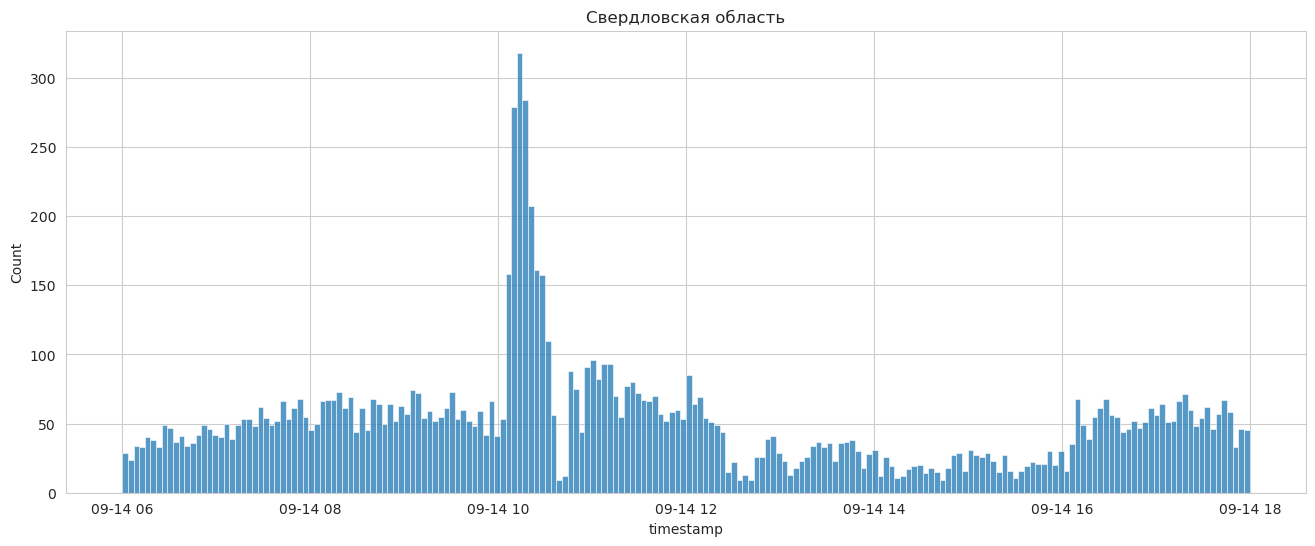

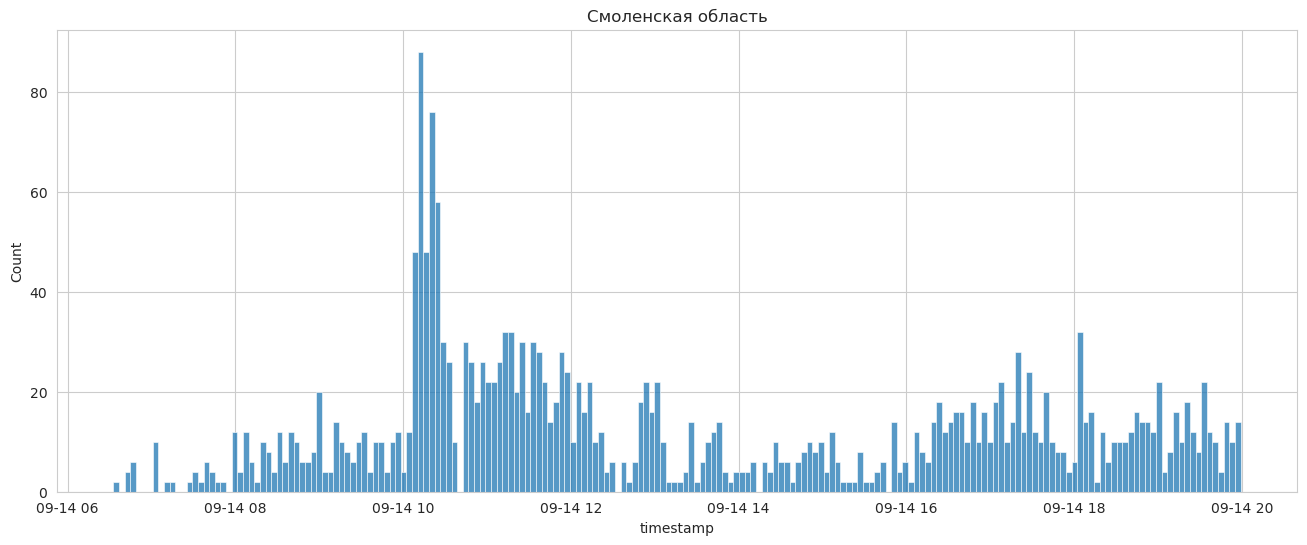

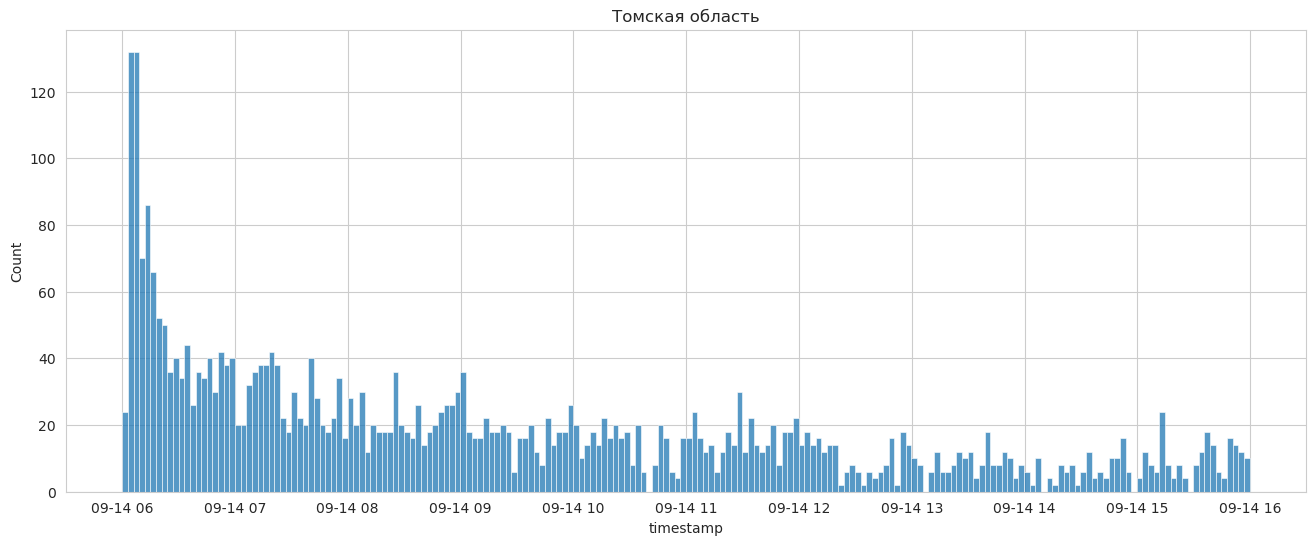

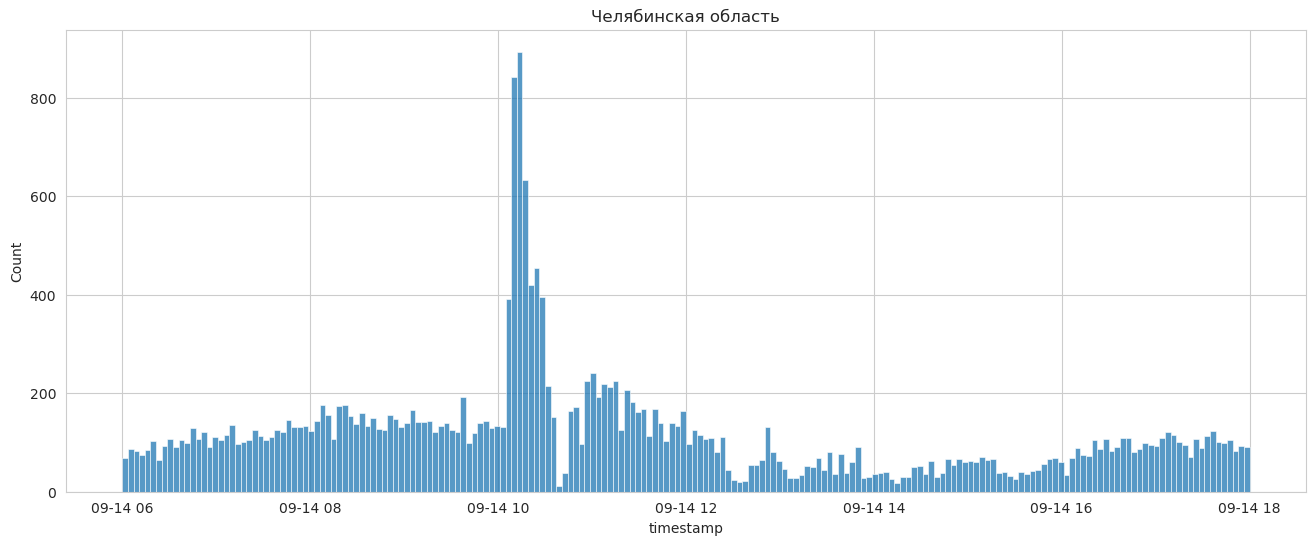

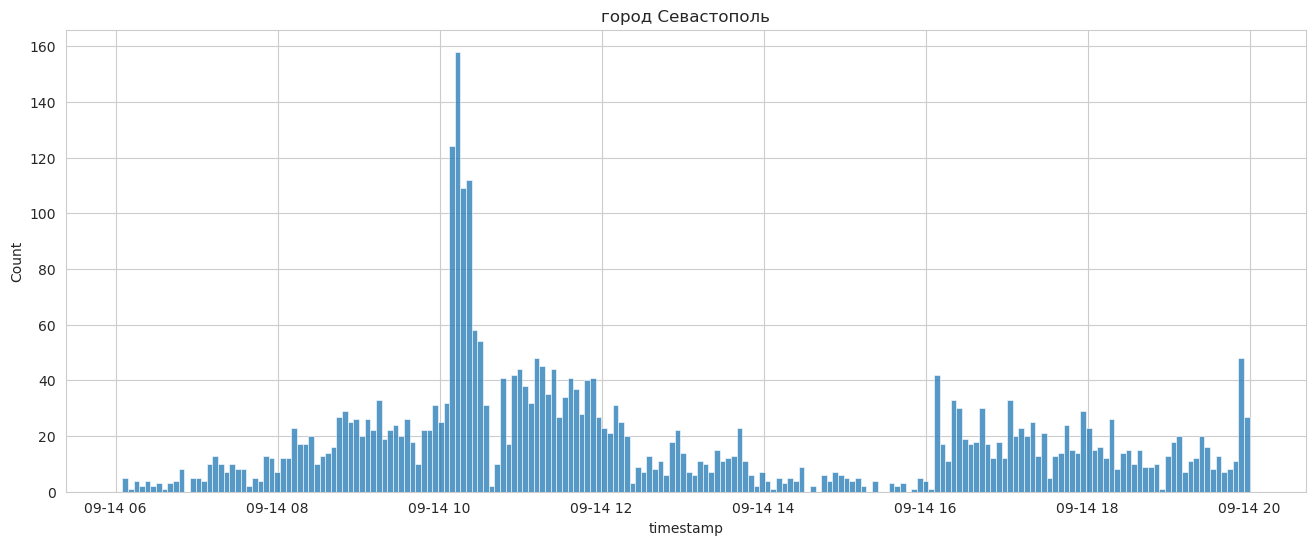

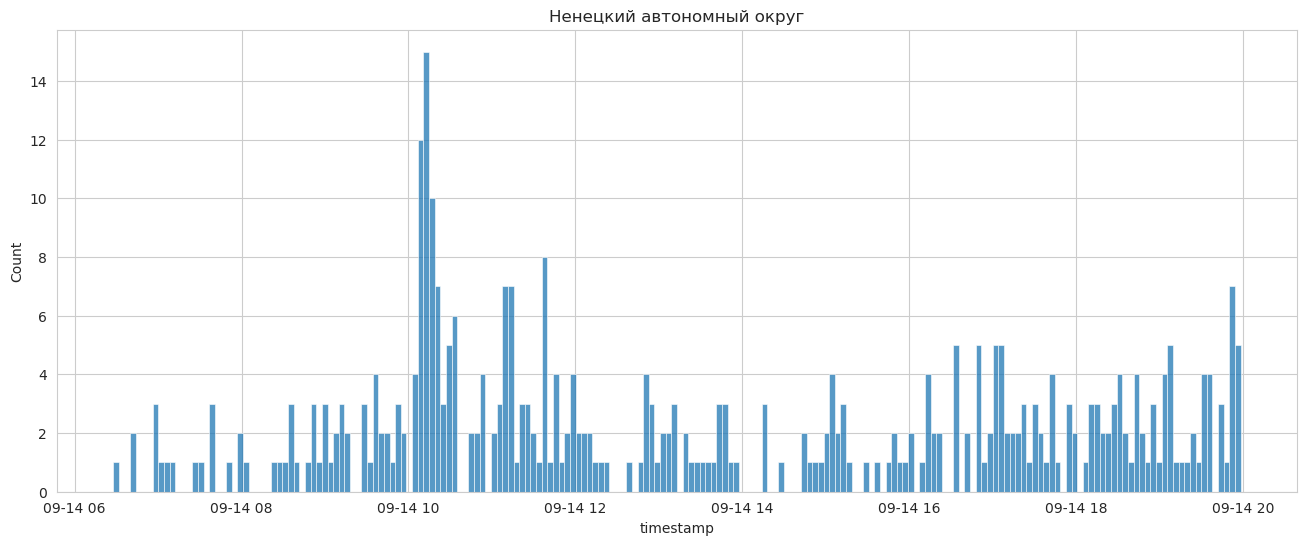

In [17]:
sunday = df[(df.timestamp > datetime(2025, 9, 14, 6)) & (df.timestamp < datetime(2025, 9, 14, 21))]

for region in map_regions:
    plt.figure(figsize=(16, 6))

    sns.histplot(sunday[sunday.region == region].timestamp, bins=200)
    plt.title(map_regions[region][1])
    plt.show()

## Converting into a DataFrame

In [31]:
data = []

for contract_id, tally in tqdm(results.items()):
    official = []
    candidates = []
    for candidate in load(f'results/voting/{contract_id}')['answers']:
        candidates.append(candidate['name'])
        official.append(candidate['value'])
    assert(official == tally)
    data.append((contract_id, candidates, tally))
    
results_df = pd.DataFrame(data, columns=['contract_id', 'candidates', 'results'])
results_df.to_csv('junk/data-expanded/2025/results.csv', index=False)
results_df

  0%|          | 0/3046 [00:00<?, ?it/s]

100%|██████████| 3046/3046 [02:51<00:00, 17.73it/s]


,contract_id,candidates,results
0,BDbQfDJBpCuXhBHqFV3FLxKAPbbpwC3Fua8zP3nChJMe,"[Политическая партия ""КОММУНИСТИЧЕСКАЯ ПАРТИЯ ...","[75, 61, 110, 435, 55]"
1,E42QNT86Xiea8miWKRvNtCeSZf2yQy4QTFjxAniZJPo6,"[КАСАПЧУК Александр Михайлович, СИМОНЕНКО Кири...","[53, 52, 153]"
2,9fPEgfxbqGwWund9QznJGaSGpccK7tvqasgLD6U8rFUm,"[БУРДУКОВСКАЯ Анжела Константиновна, ГОЛОВАНЬ ...","[202, 127, 308, 99]"
3,EATWQzijNs2iiA4RPtLJfh5ABmzroqNNzbBdEZ1ZEnJ6,"[ЕФИМЧУК Юрий Самсонович, КОНОНОВ Евгений Алек...","[121, 31, 245]"
4,8dzHSR5mF2DcUojdZsqhenNRTBCfVSmWKiwLrgS7SY1x,"[САЛТАНОВ Евгений Николаевич, СИМОНЕНКО Родион...","[308, 137, 106]"
...,...,...,...
3041,EfM7n7W8gVn41M4VDmr1zu13vyU9birasY3SUepZvAiA,"[ВАРЖАВИНОВ Алексей Афанасьевич, ВОЛОСЕНКО Оле...","[113, 24, 54]"
3042,FGmcyCZJpQYW8DZWZQUXRmsmsooen4vjJDT31LDy3fFQ,"[БЕССОНОВ Евгений Иванович, КЛИМЧЕНКО Юрий Але...","[884, 245, 214, 8578, 526]"
3043,FgskUK7oN1HwmF6rvR5B8PE4ThASQNbzNaDbYN5oCLh,"[БОЕВА Екатерина Евгеньевна, БУБЕНИНА Надежда ...","[59, 112, 244, 27, 25, 30]"
3044,5nChrr5KrELe5aiNUyopuiBqQFwZAnLh1hLb5ocn1rFs,"[АНДРУШКЕВИЧ Владимир Евгеньевич, ПЛОХИХ Алекс...","[37, 46, 201, 198]"


In [2]:
results_df = pd.read_csv('junk/data-expanded/2025/results.csv')
results_df

,contract_id,candidates,results
0,BDbQfDJBpCuXhBHqFV3FLxKAPbbpwC3Fua8zP3nChJMe,"['Политическая партия ""КОММУНИСТИЧЕСКАЯ ПАРТИЯ...","[75, 61, 110, 435, 55]"
1,E42QNT86Xiea8miWKRvNtCeSZf2yQy4QTFjxAniZJPo6,"['КАСАПЧУК Александр Михайлович', 'СИМОНЕНКО К...","[53, 52, 153]"
2,9fPEgfxbqGwWund9QznJGaSGpccK7tvqasgLD6U8rFUm,"['БУРДУКОВСКАЯ Анжела Константиновна', 'ГОЛОВА...","[202, 127, 308, 99]"
3,EATWQzijNs2iiA4RPtLJfh5ABmzroqNNzbBdEZ1ZEnJ6,"['ЕФИМЧУК Юрий Самсонович', 'КОНОНОВ Евгений А...","[121, 31, 245]"
4,8dzHSR5mF2DcUojdZsqhenNRTBCfVSmWKiwLrgS7SY1x,"['САЛТАНОВ Евгений Николаевич', 'СИМОНЕНКО Род...","[308, 137, 106]"
...,...,...,...
3041,EfM7n7W8gVn41M4VDmr1zu13vyU9birasY3SUepZvAiA,"['ВАРЖАВИНОВ Алексей Афанасьевич', 'ВОЛОСЕНКО ...","[113, 24, 54]"
3042,FGmcyCZJpQYW8DZWZQUXRmsmsooen4vjJDT31LDy3fFQ,"['БЕССОНОВ Евгений Иванович', 'КЛИМЧЕНКО Юрий ...","[884, 245, 214, 8578, 526]"
3043,FgskUK7oN1HwmF6rvR5B8PE4ThASQNbzNaDbYN5oCLh,"['БОЕВА Екатерина Евгеньевна', 'БУБЕНИНА Надеж...","[59, 112, 244, 27, 25, 30]"
3044,5nChrr5KrELe5aiNUyopuiBqQFwZAnLh1hLb5ocn1rFs,"['АНДРУШКЕВИЧ Владимир Евгеньевич', 'ПЛОХИХ Ал...","[37, 46, 201, 198]"


In [32]:
data = []

for contract_id, (region_code, _, election_name, district_name) in map_contracts.items():
    region_description = map_regions[region_code][1]
    data.append((contract_id, region_description, election_name, district_name))

elections_df = pd.DataFrame(data, columns=['contract_id', 'region', 'election', 'district'])
elections_df.to_csv('junk/data-expanded/2025/elections.csv', index=False)
elections_df

,contract_id,region,election,district
0,5srW2B6GTyye3rm3i9ppVTqLTMppugMbTbGNj4hAdjq7,Республика Карелия,Выборы депутатов Совета Кемского муниципальног...,Одномандатный избирательный округ №10
1,AbsNTjNA5GJRsEvZgdm7mjT61piBavs12h65AXh229mT,Республика Карелия,Выборы депутатов Совета Кемского муниципальног...,Одномандатный избирательный округ №5
2,USL6d55HjhufnA7ojaySQLNNeGN35366CEGQu7hUgFz,Республика Карелия,Выборы депутатов Совета Кемского муниципальног...,Одномандатный избирательный округ №15
3,Dn495bTnbQsUEL9TUXAfoBE2huYCtqximUYJjx3tcH2m,Республика Карелия,Выборы депутатов Совета Кемского муниципальног...,Одномандатный избирательный округ №14
4,5a7bkhKD6EUoMx7DnHGs7jQur8xXh7t6Pei3weZkbst1,Республика Карелия,Выборы депутатов Совета Кемского муниципальног...,Одномандатный избирательный округ №12
...,...,...,...,...
3041,4BbdvzVdbyQES6ARbt4YDB4htfUYgwUVGpQYNa6dLj3u,Ненецкий автономный округ,Выборы депутатов Совета депутатов Сельского по...,Вижас
3042,9j2MhYhXVvkCZnd96wYELacuoKGrqYWWPxjZb8eydsCa,Ненецкий автономный округ,Выборы депутатов Совета депутатов Сельского по...,Ома
3043,DWTkwJav7VH4SWreuLo6YC2NGiM5ndFjB3b59yd3dzwD,Ненецкий автономный округ,"Выборы главы Сельского поселения ""Коткинский с...",Участковая избирательная комиссия №16
3044,XBUUmPJbt3L7dmvyaTgfYmD1N9bHfbS1XvC6Zxt5ejT,Ненецкий автономный округ,Выборы Губернатора Архангельской области,Территориальная избирательная комиссия Нарьян-...


In [33]:
data = []
for (contract_id, uik), lists in voter_lists.items():
    initial_voters = 0
    added_voters = 0
    removed_voters = 0
    for optype, count in lists:
        if optype == 'addVotersList':
            initial_voters += count
        elif optype == 'addToVotersList':
            added_voters += count
        elif optype == 'removeFromVotersList':
            removed_voters += count

    data.append((contract_id, uik, initial_voters, added_voters, removed_voters))

uiks_df = pd.DataFrame(data, columns=['contract_id', 'uik', 'initial_voters', 'added_voters', 'removed_voters'])
uiks_df.to_csv('junk/data-expanded/2025/uiks.csv', index=False)
uiks_df

,contract_id,uik,initial_voters,added_voters,removed_voters
0,EEcua684qkRkAHEXvVn346FYiDBARKP4euWV12JYRZNq,63,2,0,0
1,DTnZo94RaqaTHqKKfJaPLq3g7iMHGaipW3naPhgipuAZ,2,103,0,0
2,EEcua684qkRkAHEXvVn346FYiDBARKP4euWV12JYRZNq,62,23,0,0
3,DTnZo94RaqaTHqKKfJaPLq3g7iMHGaipW3naPhgipuAZ,3,140,0,0
4,EEcua684qkRkAHEXvVn346FYiDBARKP4euWV12JYRZNq,61,30,0,0
...,...,...,...,...,...
32668,n42yMQ1D6S1aYMXgJwKM612CrSExNuJzqCCmGc2p6yy,2009,209,0,0
32669,8ozipAMVW5nzdgWWwCFKLqLTf63DPRWBFH2R3rs84pWF,763,33,0,0
32670,3oaBjGkfNpsL2Ctz8Tz43mtRgQSxwkto3JLVqMMofJoc,133,200,0,0
32671,C2vEgRXfCfh9bHaLoNF84GfkiybccSoP5ff874ZkfEhY,333,314,0,0


In [34]:
data = []

for contract_id, l in votes.items():
    for ts in l:
        data.append((contract_id, ts))

votes_df = pd.DataFrame(data, columns=['contract_id', 'timestamp'])
votes_df.to_csv('junk/data-expanded/2025/votes.csv', index=False)
votes_df

,contract_id,timestamp
0,6xPDCx6LmNZ6nWQaVc6BdT6eMTUQ1S1XsRxHCeBQPzK9,2025-09-12 00:00:48
1,6xPDCx6LmNZ6nWQaVc6BdT6eMTUQ1S1XsRxHCeBQPzK9,2025-09-12 00:01:39
2,6xPDCx6LmNZ6nWQaVc6BdT6eMTUQ1S1XsRxHCeBQPzK9,2025-09-12 00:02:33
3,6xPDCx6LmNZ6nWQaVc6BdT6eMTUQ1S1XsRxHCeBQPzK9,2025-09-12 00:02:34
4,6xPDCx6LmNZ6nWQaVc6BdT6eMTUQ1S1XsRxHCeBQPzK9,2025-09-12 00:03:07
...,...,...
2881285,FYoV7oD7xGg48fMQvGcMzcxKrqk9Ya1NyHdmGTRLPv47,2025-09-14 11:26:24
2881286,FYoV7oD7xGg48fMQvGcMzcxKrqk9Ya1NyHdmGTRLPv47,2025-09-14 11:39:11
2881287,FYoV7oD7xGg48fMQvGcMzcxKrqk9Ya1NyHdmGTRLPv47,2025-09-14 11:54:59
2881288,FYoV7oD7xGg48fMQvGcMzcxKrqk9Ya1NyHdmGTRLPv47,2025-09-14 12:56:29


In [35]:
data = []

for contract_id, l in signatures.items():
    for _, uik, ts in l:
        data.append((contract_id, uik, ts))

ballots_df = pd.DataFrame(data, columns=['contract_id', 'uik', 'timestamp'])
ballots_df.to_csv('junk/data-expanded/2025/ballots.csv', index=False)
ballots_df

,contract_id,uik,timestamp
0,9PADaCaanERuTFRCyS6JhwHEGjqmS1TB1rQw6RJ8AP4V,28,2025-09-12 00:00:23
1,9PADaCaanERuTFRCyS6JhwHEGjqmS1TB1rQw6RJ8AP4V,43,2025-09-12 00:00:34
2,9PADaCaanERuTFRCyS6JhwHEGjqmS1TB1rQw6RJ8AP4V,42,2025-09-12 00:01:15
3,9PADaCaanERuTFRCyS6JhwHEGjqmS1TB1rQw6RJ8AP4V,42,2025-09-12 00:01:24
4,9PADaCaanERuTFRCyS6JhwHEGjqmS1TB1rQw6RJ8AP4V,30,2025-09-12 00:01:27
...,...,...,...
2901959,FYoV7oD7xGg48fMQvGcMzcxKrqk9Ya1NyHdmGTRLPv47,20,2025-09-14 11:25:54
2901960,FYoV7oD7xGg48fMQvGcMzcxKrqk9Ya1NyHdmGTRLPv47,20,2025-09-14 11:38:24
2901961,FYoV7oD7xGg48fMQvGcMzcxKrqk9Ya1NyHdmGTRLPv47,20,2025-09-14 11:52:53
2901962,FYoV7oD7xGg48fMQvGcMzcxKrqk9Ya1NyHdmGTRLPv47,20,2025-09-14 12:54:59


## Analysis

In [97]:
ballots_df.timestamp.max()

Timestamp('2025-09-13 16:12:26')

In [ ]:
voters = len(all_hashes) - len(removed_hashes)
voters

1710180

In [106]:
len(signature_hashes) / voters

0.8248701518179915

In [101]:
uiks_df.initial_voters.sum() / voters

1.876259224175233

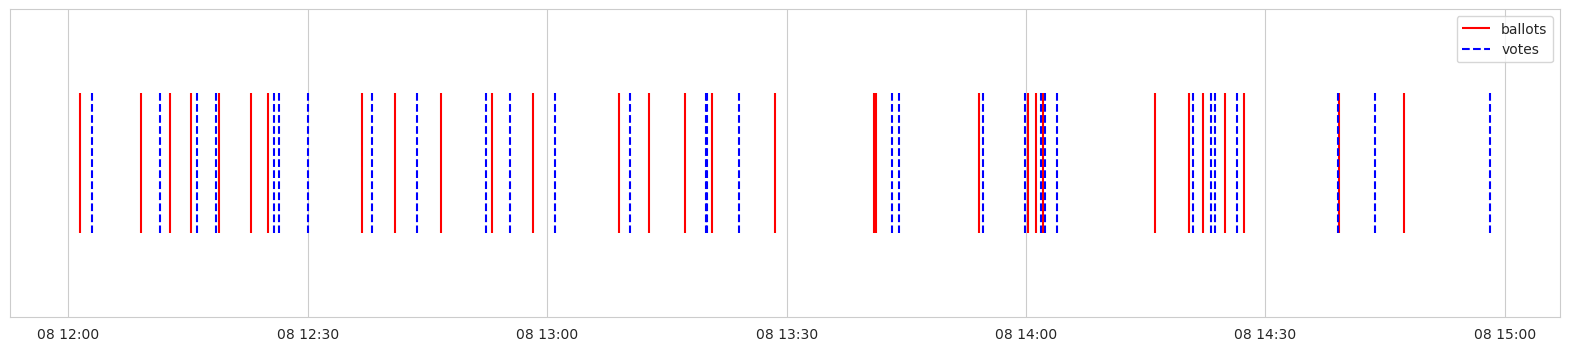

: 

In [119]:
start = "2024-09-08 12:00:00"
end = "2024-09-08 15:00:00"

votes = votes_df.query(f'contract_id == "{dolgoprudny}" and "{start}" < timestamp < "{end}"').timestamp
votes = pd.to_datetime(votes)

ballots = ballots_df.query(f'contract_id == "{dolgoprudny}" and "{start}" < timestamp < "{end}"').timestamp
ballots = pd.to_datetime(ballots)

plt.figure(figsize=(20, 4))

plt.eventplot(ballots, orientation='horizontal', color='red', label='ballots')
plt.eventplot(votes, orientation='horizontal', color='blue', linestyles='--', label='votes')

plt.legend()

ax = plt.gca()
ax.get_yaxis().set_visible(False)

plt.savefig('dolgoprudny.png', bbox_inches='tight')

In [14]:
elections_df.query(f'contract_id == "{dolgoprudny}"').iloc[0].election

'Выборы депутатов в Совет депутатов городского округа Долгопрудный Московской области'

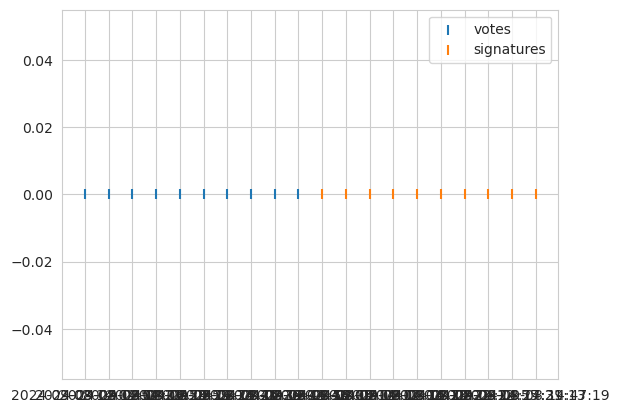

In [5]:
dolgoprudny = '75LLf68JQG5Vokznn9nN9DdVoU1tBokcovXZKcYNppca'


votes = votes_df.query(f'contract_id == "{dolgoprudny}" and "2024-09-08 14:00:00" < timestamp < "2024-09-08 15:00:00"').timestamp
ballots = ballots_df.query(f'contract_id == "{dolgoprudny}" and "2024-09-08 14:00:00" < timestamp < "2024-09-08 15:00:00"').timestamp

plt.scatter(votes, [0] * len(votes), s=50, marker='|', label='votes')
plt.scatter(ballots, [0] * len(ballots), s=50, marker='|', label='signatures')

plt.legend()

plt.show()

In [143]:
votes_df.query(f'contract_id == "{dolgoprudny}" and "2024-09-08 14:00:00" < timestamp < "2024-09-08 15:00:00"')

,contract_id,timestamp
1078033,75LLf68JQG5Vokznn9nN9DdVoU1tBokcovXZKcYNppca,2024-09-08 14:01:54
1078034,75LLf68JQG5Vokznn9nN9DdVoU1tBokcovXZKcYNppca,2024-09-08 14:02:21
1078035,75LLf68JQG5Vokznn9nN9DdVoU1tBokcovXZKcYNppca,2024-09-08 14:03:53
1078036,75LLf68JQG5Vokznn9nN9DdVoU1tBokcovXZKcYNppca,2024-09-08 14:20:59
1078037,75LLf68JQG5Vokznn9nN9DdVoU1tBokcovXZKcYNppca,2024-09-08 14:23:14
1078038,75LLf68JQG5Vokznn9nN9DdVoU1tBokcovXZKcYNppca,2024-09-08 14:23:41
1078039,75LLf68JQG5Vokznn9nN9DdVoU1tBokcovXZKcYNppca,2024-09-08 14:26:26
1078040,75LLf68JQG5Vokznn9nN9DdVoU1tBokcovXZKcYNppca,2024-09-08 14:39:04
1078041,75LLf68JQG5Vokznn9nN9DdVoU1tBokcovXZKcYNppca,2024-09-08 14:43:46
1078042,75LLf68JQG5Vokznn9nN9DdVoU1tBokcovXZKcYNppca,2024-09-08 14:58:05


In [142]:
ballots_df.query(f'contract_id == "{dolgoprudny}" and "2024-09-08 14:00:00" < timestamp < "2024-09-08 15:00:00"')

,contract_id,uik,timestamp
1060263,75LLf68JQG5Vokznn9nN9DdVoU1tBokcovXZKcYNppca,347,2024-09-08 14:00:14
1060264,75LLf68JQG5Vokznn9nN9DdVoU1tBokcovXZKcYNppca,347,2024-09-08 14:01:17
1060265,75LLf68JQG5Vokznn9nN9DdVoU1tBokcovXZKcYNppca,345,2024-09-08 14:02:04
1060266,75LLf68JQG5Vokznn9nN9DdVoU1tBokcovXZKcYNppca,346,2024-09-08 14:16:13
1060267,75LLf68JQG5Vokznn9nN9DdVoU1tBokcovXZKcYNppca,346,2024-09-08 14:20:23
1060268,75LLf68JQG5Vokznn9nN9DdVoU1tBokcovXZKcYNppca,342,2024-09-08 14:22:12
1060269,75LLf68JQG5Vokznn9nN9DdVoU1tBokcovXZKcYNppca,346,2024-09-08 14:24:55
1060270,75LLf68JQG5Vokznn9nN9DdVoU1tBokcovXZKcYNppca,346,2024-09-08 14:27:21
1060271,75LLf68JQG5Vokznn9nN9DdVoU1tBokcovXZKcYNppca,346,2024-09-08 14:39:13
1060272,75LLf68JQG5Vokznn9nN9DdVoU1tBokcovXZKcYNppca,341,2024-09-08 14:47:19


In [45]:
removed = uiks_df.query('removed_voters > 0').merge(elections_df, on='contract_id')
#removed = removed.reset_
#removed.columns = ['region', 'election', 'district', 'uik', 'initial_voters', 'removed_voters']
removed.sort_values('removed_voters', ascending=False).groupby('region').sum(numeric_only=True)

,uik,initial_voters,added_voters,removed_voters
region,,,,
Архангельская область,1324,437,0,4
Белгородская область,81666,14100,0,236
город Севастополь,3269,5538,0,50


In [51]:
votes_df

,contract_id,timestamp
0,3ssXG6oQxwacuv8t8ejVu2in5UEEY2ekKpM6hsR64Fkb,2025-09-12 00:01:54
1,3ssXG6oQxwacuv8t8ejVu2in5UEEY2ekKpM6hsR64Fkb,2025-09-12 00:01:55
2,3ssXG6oQxwacuv8t8ejVu2in5UEEY2ekKpM6hsR64Fkb,2025-09-12 00:02:33
3,3ssXG6oQxwacuv8t8ejVu2in5UEEY2ekKpM6hsR64Fkb,2025-09-12 00:02:34
4,3ssXG6oQxwacuv8t8ejVu2in5UEEY2ekKpM6hsR64Fkb,2025-09-12 00:04:22
...,...,...
2559896,Adh8nN4ZmrSfRBe8tQRLkWgjQz92FZz721fEkugH35xi,2025-09-13 12:08:30
2559897,Adh8nN4ZmrSfRBe8tQRLkWgjQz92FZz721fEkugH35xi,2025-09-13 12:16:32
2559898,Adh8nN4ZmrSfRBe8tQRLkWgjQz92FZz721fEkugH35xi,2025-09-13 12:18:23
2559899,Adh8nN4ZmrSfRBe8tQRLkWgjQz92FZz721fEkugH35xi,2025-09-13 12:35:49


In [100]:
turnout = ballots_df.groupby(['contract_id']).size()
turnout = turnout.reset_index()
turnout.columns = ['contract_id', 'ballots']
turnout

,contract_id,ballots
0,121WUnLPiNKtBjQZpkRt2HrNbA4q65QzRKJ1mvxxAXmD,549
1,12XyLZ5SP2HH2mmdMRRtu7JU9qWXG6EFsQusSccTB3fT,775
2,12YspJsekjLNH3Ldb3jM9ch9XBY7GP8TQScEsQ5XUb2u,132
3,14N4xYMRTGvVrZisz2oMW9aZAXE65E2uGbTWq4M29zEg,429
4,14XfyD6wAtFW1UDYC7g4rLxi6ACCPa5zcg9GeZVHJRJJ,25
...,...,...
2090,vsqHZ7Buc8Tm7e65yNV1bEY6KaJstLG2UPvbUq9qSGH,85
2091,xUbuj7dk8EyoXpfdDrNN7JHXcabdttcHCE7nZnBedRa,14
2092,yD3uFyXAMPD2FVf46EnDdM2SR5VfxodoBVJEStSnv45,3220
2093,zMuz5SZWj7o96tVEooFxHxauQGeeUhsSJ4fpUpYMeNC,81


In [101]:
total = uiks_df.groupby('contract_id').sum(numeric_only=True).drop('uik', axis=1)
total = total.merge(elections_df, on='contract_id')
total

,contract_id,initial_voters,added_voters,removed_voters,region,election,district
0,121WUnLPiNKtBjQZpkRt2HrNbA4q65QzRKJ1mvxxAXmD,624,0,0,Московская область,Выборы депутатов Совета депутатов Сергиево-Пос...,Сергиево-Посадский
1,12XyLZ5SP2HH2mmdMRRtu7JU9qWXG6EFsQusSccTB3fT,828,0,0,Вологодская область,Выборы Губернатора Вологодской области,территориальная избирательная комиссия Чагодощ...
2,12YspJsekjLNH3Ldb3jM9ch9XBY7GP8TQScEsQ5XUb2u,141,0,0,Республика Марий Эл,Выборы депутатов Собрания депутатов Большепара...,Большепаратский одиннадцатимандатный
3,14N4xYMRTGvVrZisz2oMW9aZAXE65E2uGbTWq4M29zEg,484,0,0,Челябинская область,Выборы Губернатора Челябинской области,Территориальная избирательная комиссия города ...
4,14XfyD6wAtFW1UDYC7g4rLxi6ACCPa5zcg9GeZVHJRJJ,28,0,0,Липецкая область,Выборы депутатов Совета депутатов сельского по...,Первый
...,...,...,...,...,...,...,...
2098,vsqHZ7Buc8Tm7e65yNV1bEY6KaJstLG2UPvbUq9qSGH,110,0,0,Архангельская область,Дополнительные выборы депутатов Собрания депут...,Округ №15
2099,xUbuj7dk8EyoXpfdDrNN7JHXcabdttcHCE7nZnBedRa,20,0,0,Камчатский край,Выборы депутатов Собрания депутатов Тигильског...,Второй
2100,yD3uFyXAMPD2FVf46EnDdM2SR5VfxodoBVJEStSnv45,3529,0,0,Московская область,Выборы депутатов Совета депутатов городского о...,Первый
2101,zMuz5SZWj7o96tVEooFxHxauQGeeUhsSJ4fpUpYMeNC,88,0,0,Челябинская область,Выборы депутатов Совета депутатов Кременкульск...,Второй


In [102]:
df = total.merge(turnout, on='contract_id')
df['turnout'] = df.ballots / df.initial_voters
df.query('election == "Выборы депутатов Республики Алтай"').sort_values('district')

,contract_id,initial_voters,added_voters,removed_voters,region,election,district,ballots,turnout
19,28BRyp5nTcHHs5gsrd5YqYuG9NCFwoSPsrKdSC3SPiRg,954,0,0,Республика Алтай,Выборы депутатов Республики Алтай,Округ №1,904,0.947589
570,6KVHVamsLz53rvsq7KcrsVtYPZRjiVUNzop9tSRSRUAf,954,0,0,Республика Алтай,Выборы депутатов Республики Алтай,Округ №1,904,0.947589
276,4EcF6KoTx84fY1pXaGWaiePTpD7Lj7soJks7yXZwkpr2,1123,0,0,Республика Алтай,Выборы депутатов Республики Алтай,Округ №10,1050,0.934996
747,7gik6NoSUgTe5J1YYjBA1xxFDuuMXqTxp3AYQqEGBiHs,1123,0,0,Республика Алтай,Выборы депутатов Республики Алтай,Округ №10,1050,0.934996
83,2brRV8YqdGJNTuyGV2NoB2CqqK8oYXrg2gknXP6eG2KB,586,0,0,Республика Алтай,Выборы депутатов Республики Алтай,Округ №11,545,0.930034
933,96wHBGi5T2m473fKwub542wFhEfpbWb4bytrXJvSEcJg,586,0,0,Республика Алтай,Выборы депутатов Республики Алтай,Округ №11,545,0.930034
1815,GdAKMSyDdTgPEw4P6i8LycvkHjuYwNz9h4CRmttUsMi7,999,0,0,Республика Алтай,Выборы депутатов Республики Алтай,Округ №12,937,0.937938
1068,AD715kuBThyvUp9vVWReQknqYrU1n9gryMnfsRqeM8ED,999,0,0,Республика Алтай,Выборы депутатов Республики Алтай,Округ №12,937,0.937938
1725,FsVyKTBkyfvgfA7tsGzhM7ToboYrLsWhgihsHwK5ahde,674,0,0,Республика Алтай,Выборы депутатов Республики Алтай,Округ №13,637,0.945104
1651,FDo5ChpEivtiEEgbNvmacMe5HgeYuMdNtxKVu7THSZKL,674,0,0,Республика Алтай,Выборы депутатов Республики Алтай,Округ №13,637,0.945104


## Cross-check with CEC protocols

In [3]:
elections_df = pd.read_csv('junk/data-expanded/2025/elections.csv')
results_df = pd.read_csv('junk/data-expanded/2025/results.csv')
uiks_df = pd.read_csv('junk/data-expanded/2025/uiks.csv')
votes_df = pd.read_csv('junk/data-expanded/2025/votes.csv')
ballots_df = pd.read_csv('junk/data-expanded/2025/ballots.csv')

In [160]:
from pathlib import Path

protocols = []

for path in tqdm(list(Path('junk/data-expanded/cik/campaigns').rglob('*.json'))):
    with open(str(path), 'r') as f:
        data = json.load(f)

        if data['dates']['election_date'] != '08.09.2024':
            pprint(data)
            break

        election_name = data['campaign_name']
        region_name = data['group_name']

        #if election_name == 'Выборы депутатов Думы Уинского муниципального округа Пермского края второго созыва':
        #    pprint(data)

        if isinstance(data['reports'], list):
            print(election_name)
            # todo: investigate later
        elif data['reports']['electronic']:
            for report in data['tree']:
                if 'reports' not in report:
                    print(election_name)
                    # todo: investigate later
                else:
                    for tik in report['reports']['electronic']:
                        if 'protocol' not in tik:
                            print(election_name)
                            # todo: investigate later
                        else:
                            protocol = tik['protocol']['data']
                            if protocol:
                                tik_name = ' '.join(tik['crumbs'])
                                protocol_fields = [(line['line_name'], line['line_val']) for line in protocol]
                                protocols.append((election_name, region_name, tik_name, protocol_fields))

 75%|███████▌  | 3133/4170 [00:04<00:01, 778.80it/s] 

Отложенное голосование на досрочных выборах Главы Амбарнского сельского поселения
Отложенное голосование на досрочных выборах Главы Амбарнского сельского поселения
Отложенное голосование на досрочных выборах Главы Амбарнского сельского поселения


100%|██████████| 4170/4170 [00:05<00:00, 751.57it/s] 

Выборы депутатов Льговского Городского Совета депутатов седьмого созыва
Выборы Главы Беловского района Курской области
Выборы депутатов Представительного Собрания Беловского района Курской области пятого созыва
Выборы депутатов Представительного Собрания Большесолдатского района Курской области пятого созыва
Выборы Главы поселка Коренево Кореневского района Курской области
Дополнительные выборы депутата Представительного Собрания Глушковского района Курской области пятого созыва по одномандатному избирательному округу №7
Дополнительные выборы депутата Собрания депутатов поселка Теткино Глушковского района седьмого созыва по одномандатному избирательному округу №9
Выборы депутатов Представительного Собрания Суджанского района Курской области  пятого созыва
Выборы депутатов Собрания депутатов города Суджи Суджанского района Курской области  восьмого созыва
Выборы депутатов Представительного Собрания  Хомутовского района Курской области пятого созыва
Выборы депутатов Совета депутатов Рощи

In [157]:
errors = 0
def try_keys(d, keys):
    global errors
    for key in keys:
        if key in d:
            return d[key]
    errors += 1
    return 0
    #print(keys)
    #pprint(d)
    #raise KeyError('no key found in dict')

In [208]:
elections = defaultdict(list)
for election, region, tik, protocol in protocols:
    if region != 'город Москва':
        elections[(region, election)].append(protocol)

total_deg_sum = 0
total_cik_sum = 0

for (region, election), lists in elections.items():
    deg_campaign = elections_df[elections_df.election == election].merge(uiks_df, on='contract_id')
    deg_sum = deg_campaign.initial_voters.sum() - deg_campaign.removed_voters.sum() + deg_campaign.added_voters.sum()
    cik_sum = 0
    for protocol in lists:
        d = {name.lower(): value for name, value in protocol}

        cik_sum += try_keys(d, [
            'число избирателей, внесенных в список избирателей на момент окончания голосования',
            'число избирателей, внесенных в список на момент окончания голосования',
            'число избирателей, включённых в список избирателей',
            'число избирателей, внесенных в список',
            'число избирателей, включенных в список избирателей',
            'число избирателей, внесенных в список избирателей',
            'число избирателей, внесенных в списки избирателей на момент окончания голосования',
            'число избирателей, включенных в список избирателей на момент окончания голосования',
            'число избирателей, участников референдума, внесенных в список на момент окончания голосования',
            'число избирателей,внесенных в списки избирателей на момент окончания голосования',
            'число избирателей внесенных в список',
            'число избирателей, внесенных в списки',
            'число избирателей, внесенных в списки на момент окончания голосования',
            'число избирателей, внесенных в список на момент окончания голосования',
            'число избирателей, внесенных список избирателей на момент окончания голосования',
            'число избирателей на момент окончания голосования',
            'число избирателей, включенных в список',
            'число избирателей, включённых в список избирателей'
        ])
    
    total_deg_sum += deg_sum
    total_cik_sum += cik_sum

    if deg_sum != cik_sum:
        print(region, election, deg_sum, cik_sum)
        #pprint(lists)

total_deg_sum, total_cik_sum, total_cik_sum / total_deg_sum

(1366924, 1366924, 1.0)

In [170]:
uiks_df.initial_voters.sum()

1368062

In [155]:
for election, region, tik, protocol in protocols:
    if election == 'Выборы депутатов Думы Уинского муниципального округа Пермского края второго созыва':
        print(region, tik, protocol)

Пермский край Территориальная избирательная комиссия Уинского муниципального округа ОИК №1 [('Число избирателей, внесенных в список избирателей на момент окончания голосования', 128), ('Число бюллетеней, полученных участковой избирательной комиссией', 114), ('Число бюллетеней, выданных избирателям, проголосовавшим досрочно, в том числе', 0), ('в помещении избирательной комиссии, организующей подготовку и проведение выборов', 0), ('Число бюллетеней, выданных избирателям в помещении для голосования', 114), ('Число бюллетеней, выданных избирателям, проголосовавшим вне помещения для голосования', 0), ('Число погашенных бюллетеней', 0), ('Число бюллетеней, содержащихся в переносных ящиках для голосования', 0), ('Число бюллетеней, содержащихся в стационарных ящиках для голосования', 114), ('Число недействительных бюллетеней', 0), ('Число действительных бюллетеней', 114), ('Число утраченных бюллетеней', 0), ('Число не учтенных при получении бюллетеней', 0), ('Зомарева Алла Александровна', 23)

In [156]:
elections_df.query('election == "Выборы депутатов Думы Уинского муниципального округа Пермского края второго созыва"').merge(uiks_df, on='contract_id').initial_voters.sum()

424

In [70]:
uiks_df.query('contract_id == "4fWwv7S1tCx8janYWJMbeJW5cRfCUVeSTt7sTrK2BYST"')

,contract_id,uik,initial_voters,added_voters,removed_voters
5432,4fWwv7S1tCx8janYWJMbeJW5cRfCUVeSTt7sTrK2BYST,3805,88,0,0
5438,4fWwv7S1tCx8janYWJMbeJW5cRfCUVeSTt7sTrK2BYST,3802,32,0,0
5439,4fWwv7S1tCx8janYWJMbeJW5cRfCUVeSTt7sTrK2BYST,3806,8,0,0


In [73]:
uiks_df.sum(numeric_only=True)

uik               15336590
initial_voters     1368062
added_voters            75
removed_voters         859
dtype: int64

In [142]:
len(votes_df) / len(ballots_df)

0.9929814160596474

In [133]:
total_voters = 0
total_ballots = 0
total_votes = 0


for election, region, tik, protocol in protocols:
    d = {name.lower(): value for name, value in protocol}

    total_voters += try_keys(d, [
        'число избирателей, внесенных в список избирателей на момент окончания голосования',
        'число избирателей, внесенных в список на момент окончания голосования',
        'число избирателей, включённых в список избирателей',
        'число избирателей, внесенных в список',
        'число избирателей, внесенных в списки избирателей на момент окончания голосования',
        'число избирателей, включенных в список избирателей на момент окончания голосования'
    ])

    total_ballots += try_keys(d, [
        'число бюллетеней, полученных участковой избирательной комиссией',
        'число бюллетеней, полученных участковой комиссией',
        'число избирательных бюллетеней, полученных участковой избирательной комиссией',
        'число бюллетеней, выданных избирателям, в помещении для голосования в день голосования',
        'число бюллетеней, выданных на участке в день голосования',
        'число бюллетеней, выданных в уик',
        'число бюллетеней, выданных в помещении для голосования',
        'число избирательных бюллетеней, выданных избирателям в помещении для голосования в день голосования',
        'число бюллетеней, полученных участковыми избирательными комиссиями',
        'число бюллетеней, выданных избирателям в помещении для голосования в день голосования',
        'число бюллетеней, полученных комиссией'
    ])

    total_votes += try_keys(d, [
        'число действительных избирательных бюллетеней',
        'число действительных бюллетеней',
    ])

total_voters, total_ballots, total_votes, errors

(4184079, 4215294, 4251467, 175)

In [131]:
total_votes/total_voters

1.0173635465955697

# Vote matching

In [2]:
elections_df = pd.read_csv('junk/data-expanded/2025/elections.csv')
votes_df = pd.read_csv('junk/data-expanded/2025/votes.csv')
ballots_df = pd.read_csv('junk/data-expanded/2025/ballots.csv')

In [14]:
import numpy as np

def extract_timestamps(df):
    return pd.to_datetime(df.timestamp).values.astype('int') // 10**9

In [25]:
for contract_id in tqdm(votes_df.contract_id.unique()):
    ballot_timestamps = extract_timestamps(ballots_df.query(f'contract_id == "{contract_id}"'))
    vote_timestamps = extract_timestamps(votes_df.query(f'contract_id == "{contract_id}"'))
    
    for prev_votes, last_vote_timestamp in enumerate(sorted(vote_timestamps)):
        prev_ballots = (ballot_timestamps < last_vote_timestamp).sum()
        if prev_ballots < prev_votes + 1:
            print(contract_id, prev_ballots, prev_votes + 1, to_dt(last_vote_timestamp * 1000))

100%|██████████| 2095/2095 [01:18<00:00, 26.53it/s]


In [23]:
elections_df.query('contract_id == "52GuEx2kpk4p9c2dPF66gDVVKzQbxN9fEWR2NwjkzsSR"')

,contract_id,region,election,district
1003,52GuEx2kpk4p9c2dPF66gDVVKzQbxN9fEWR2NwjkzsSR,Калининградская область,Досрочные выборы Губернатора Калининградской о...,Гвардейская территориальная избирательная коми...


In [15]:
votes_df.contract_id.value_counts().median()

136.0

In [31]:
elections_df.query('contract_id == "121WUnLPiNKtBjQZpkRt2HrNbA4q65QzRKJ1mvxxAXmD"')

,contract_id,region,election,district
1334,121WUnLPiNKtBjQZpkRt2HrNbA4q65QzRKJ1mvxxAXmD,Московская область,Выборы депутатов Совета депутатов Сергиево-Пос...,Сергиево-Посадский


In [56]:
datetime.strptime('2024-09-06 12:00:00', '%Y-%m-%d %H:%M:%S').timestamp()


1725613200.0

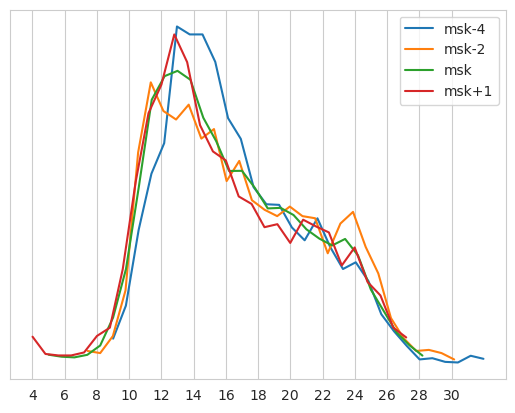

In [ ]:
zones = [
    ('msk-4', '04', '05', -4),
    ('msk-2', '06', '07', -2),
    ('msk', '08', '09', 0),
    ('msk+1', '09', '10', 1),
]

threeday = votes_df.query(f'timestamp < "2024-09-06 12:00:00"')
saturday = votes_df.query('"2024-09-07 02:00:00" < timestamp < "2024-09-08 02:00:00"')

for zone, l, r, offset in zones:
    select = votes_df.groupby('contract_id').min().query(f'"2024-09-06 {l}:00:00" < timestamp < "2024-09-06 {r}:00:00"')
    ts = pd.to_datetime(select.merge(saturday, on='contract_id').timestamp_y.values)
    counts, bins = np.histogram(ts.astype('int') // 10**9 - offset * 3600, bins=30, density=True)
    #k = 1 / counts.max()
    #print(counts)
    #print(k)
    plt.plot(bins[:-1], counts, label=zone)
    #sns.histplot(ts, label=zone, bins=50, stat='probability', alpha=0.4)
    #sns.barplot(ts, label=zone)

start = datetime.strptime('2024-09-07 00:00:00', '%Y-%m-%d %H:%M:%S').timestamp()

#print(start - bins[0])

steps = range(4, 32, 2)

plt.xticks([start + 3600 * h for h in steps], labels=steps)
plt.yticks([])
plt.legend()
plt.savefig('timezones_saturday.png')

In [ ]:
select = threeday.query(f'"2024-09-06 12:00:00" < timestamp < "2024-09-06 12:00:00"')
xs = extract_timestamps(select.sample(100))
xs

array([1725612839, 1725603046, 1725622323, 1725619406, 1725617832,
       1725607718, 1725612180, 1725613049, 1725614047, 1725609931,
       1725614021, 1725613190, 1725613811, 1725612836, 1725610730,
       1725613958, 1725615205, 1725619407, 1725621267, 1725620795,
       1725616075, 1725615760, 1725611689, 1725611026, 1725615315,
       1725621512, 1725610231, 1725610653, 1725620739, 1725613220,
       1725610235, 1725610177, 1725619168, 1725612974, 1725622935,
       1725618416, 1725617691, 1725599467, 1725597722, 1725618760,
       1725614035, 1725611741, 1725603537, 1725612630, 1725601026,
       1725611940, 1725614295, 1725616544, 1725612550, 1725610698,
       1725611251, 1725610719, 1725595919, 1725609739, 1725623589,
       1725612653, 1725595304, 1725616803, 1725615820, 1725615430,
       1725616949, 1725611750, 1725610185, 1725622977, 1725610548,
       1725613613, 1725599244, 1725612134, 1725617724, 1725619437,
       1725609892, 1725616450, 1725613883, 1725595464, 1725610

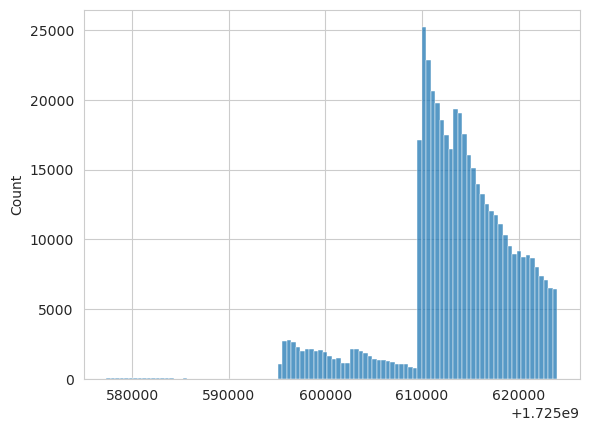

In [18]:
xs = extract_timestamps(threeday)
sns.histplot(xs, bins=100)
plt.show()

In [45]:
counts = [0] * 20
window = 120

for contract_id in tqdm(votes_df.contract_id.unique()):
    ballot_timestamps = extract_timestamps(ballots_df.query(f'contract_id == "{contract_id}"'))
    vote_timestamps = extract_timestamps(votes_df.query(f'contract_id == "{contract_id}"'))
    
    for ballot in ballot_timestamps:
        close_votes = ((vote_timestamps > ballot) & (vote_timestamps < ballot + window)).sum()
        if close_votes < 20:
            counts[close_votes] += 1

counts

100%|██████████| 2095/2095 [01:22<00:00, 25.50it/s]


[109682,
 192205,
 117674,
 87153,
 69497,
 57327,
 48650,
 41987,
 35886,
 32061,
 27943,
 24424,
 21177,
 18838,
 16570,
 14324,
 12882,
 11214,
 10346,
 9472]

In [48]:
import scipy

s = 0

for n, c in enumerate(counts):
    if n > 0:
        p = scipy.stats.binom(n - 1, 0.3).pmf(0)
        print(n, c, p)
        s += c * p

1 192205 1.0
2 117674 0.7000000000000002
3 87153 0.49000000000000005
4 69497 0.3429999999999999
5 57327 0.24010000000000006
6 48650 0.16807000000000002
7 41987 0.11764899999999992
8 35886 0.08235430000000003
9 32061 0.05764800999999996
10 27943 0.04035360699999994
11 24424 0.0282475249
12 21177 0.019773267429999988
13 18838 0.013841287200999995
14 16570 0.009688901040699997
15 14324 0.006782230728489992
16 12882 0.004747561509942972
17 11214 0.003323293056960071
18 10346 0.0023263051398721584
19 9472 0.0016284135979105097


In [49]:
s / len(ballots_df)

0.30427579455789555

In [7]:
sum(counts)

744889

In [132]:
small = votes_df.groupby('contract_id').filter(lambda x: len(x) < 100).contract_id.unique()
len(small)

865

In [ ]:
relative_timestamps = []
window = 1800

for contract_id in tqdm(small):
    ballot_timestamps = extract_timestamps(ballots_df.query(f'contract_id == "{contract_id}"'))
    vote_timestamps = extract_timestamps(votes_df.query(f'contract_id == "{contract_id}"'))

    #print(ballot_timestamps)
    #print(vote_timestamps)
    
    for ballot in ballot_timestamps:
        close_ballots = ballot_timestamps[np.absolute(ballot_timestamps - ballot) < window]

        diffs = vote_timestamps - ballot
        close_votes = diffs[(diffs > 0) & (diffs < window)]

        if len(close_ballots) == 1 and len(close_votes) == 1:
            relative_timestamps.append(close_votes[0] / 60)

relative_timestamps = np.array(relative_timestamps)

100%|██████████| 865/865 [00:30<00:00, 28.44it/s]


In [140]:
len(relative_timestamps)

6272

In [161]:
np.median(relative_timestamps) * 60 - 60

43.0

In [158]:
sum(relative_timestamps < 2) / len(relative_timestamps)

0.5819515306122449

In [192]:
relative_timestamps[relative_timestamps < 0.3] * 60

array([16., 13., 13., 14., 17., 16., 17., 16., 14., 15., 15., 17., 17.,
       15., 17., 12.])

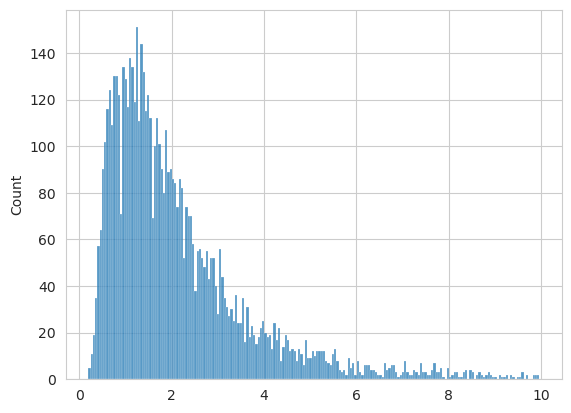

In [164]:
sns.histplot(relative_timestamps[relative_timestamps < 10], bins=200)
plt.savefig('delay.png')

In [223]:
np.random.choice([1, 2, 3])

3

In [225]:
difftimes = []

for contract_id in tqdm(votes_df.contract_id.unique()):
    ballot_timestamps = extract_timestamps(ballots_df.query(f'contract_id == "{contract_id}"'))

    for a in ballot_timestamps:
        b = np.random.choice(ballot_timestamps)
        difftimes.append(abs(a - b))

100%|██████████| 2095/2095 [00:44<00:00, 47.54it/s]


In [235]:
sum(np.array(difftimes) < 300) / len(difftimes)

0.020211837158485877

In [234]:
0.99**200

0.13397967485796172

In [236]:
closest = []

for contract_id in tqdm(votes_df.contract_id.unique()):
    ballot_timestamps = extract_timestamps(ballots_df.query(f'contract_id == "{contract_id}"'))
    #vote_timestamps = extract_timestamps(votes_df.query(f'contract_id == "{contract_id}"'))
    
    K = 1

    if len(ballot_timestamps) > K:
        for ballot in ballot_timestamps:
            diffs = np.absolute(ballot_timestamps - ballot)
            closest.append(np.partition(diffs, K)[K])

closest = np.array(closest)

100%|██████████| 2095/2095 [00:53<00:00, 39.04it/s]


In [237]:
sum(closest > 150) / len(closest)

0.10948688148181145

<AxesSubplot: ylabel='Proportion'>

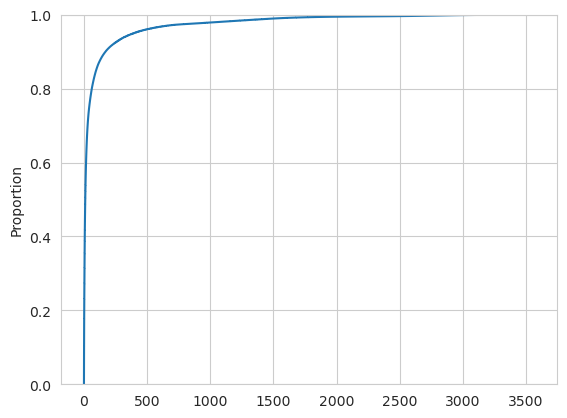

In [203]:
sns.ecdfplot(closest[closest < 313600] / 60)

<AxesSubplot: ylabel='Count'>

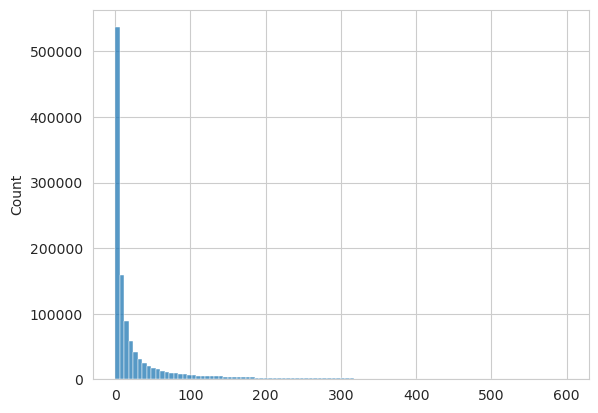

In [177]:
sns.histplot(closest[closest < 600], bins=100)

<AxesSubplot: ylabel='Count'>

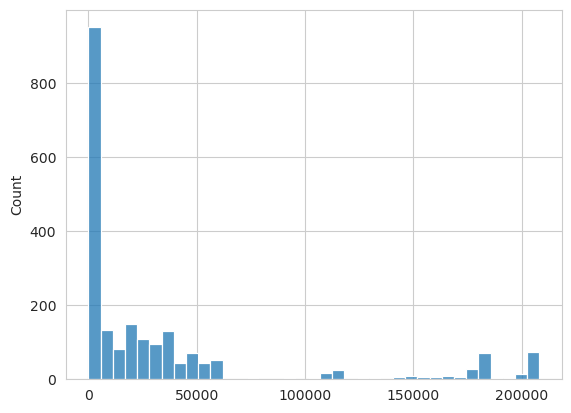

In [47]:
sns.histplot(relative_timestamps)

<AxesSubplot: xlabel='count', ylabel='Count'>

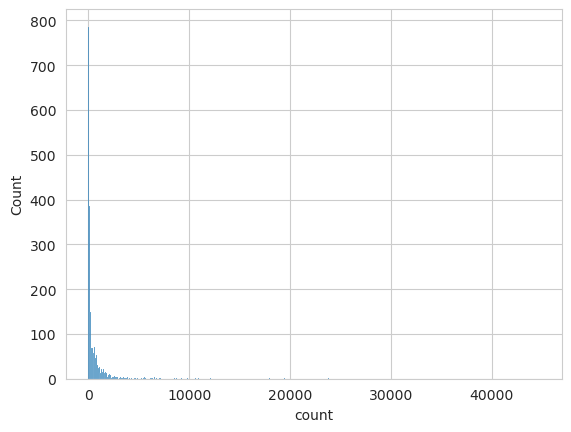

In [13]:
sns.histplot(votes_df.contract_id.value_counts())

# Restoring votes

In [336]:
import scipy.stats

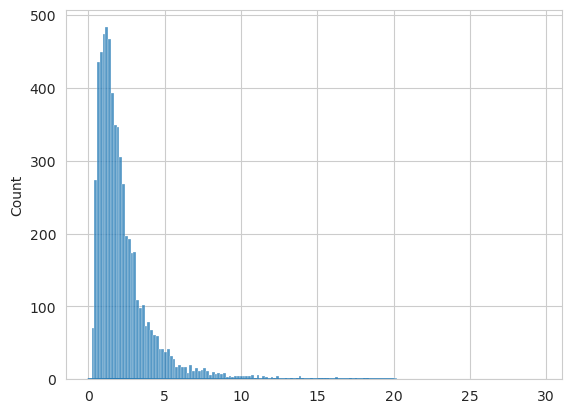

In [ ]:
kernel = scipy.stats.gaussian_kde(relative_timestamps)

xs = np.linspace(0, 20, 1000)
ys = [kernel(x) for x in xs]

#sns.histplot(relative_timestamps)
#sns.histplot(kernel.resample(10000).reshape(-1))
plt.plot(xs, ys)

In [ ]:
# generate 3 ballots front and back
# sample votes for all 7
# calculate how often the next vote is the right ballot

average_delays = np.linspace(0.1, 20, 100)  # minutes between votes on average
results = []

samples = 31  # better pick odd
half = samples // 2
190289
for average_delay in tqdm(average_delays):
    successes = 0

    for _ in range(1000):
        ballots = np.random.exponential(average_delay, samples).cumsum()
        votes = ballots + kernel.resample(samples).reshape(-1)

        successes += (votes[half] == np.partition(votes, half)[half])

    results.append(successes / 1000)

100%|██████████| 100/100 [00:12<00:00,  7.83it/s]


In [466]:
s = 0

for x in (closest / 60 * 2):
    s += results[np.abs(x - average_delays).argmin()]

s / len(closest)

0.22109253303777626

In [389]:
sorted(votes)

[1.6094415410705796,
 2.4055606572973622,
 2.604047291370456,
 7.591604228817012,
 8.562442134184753,
 10.996501499565426,
 11.013733416886218,
 21.68780630247069,
 27.659840045763048,
 27.797623469940874,
 39.780248227301]

In [387]:
np.partition(votes, half)[half]

10.996501499565426

In [378]:
samples // 2

5

In [374]:
np.random.exponential(1, 5).cumsum()

array([1.75469414, 1.85613782, 3.17892041, 3.89781123, 5.57739932])

## Voting time averages

In [296]:
data = []

for _, election in tqdm(elections_df.iterrows(), total=len(elections_df)):
    ballots = extract_timestamps(ballots_df.query(f'contract_id == "{election.contract_id}"'))
    votes = extract_timestamps(votes_df.query(f'contract_id == "{election.contract_id}"'))
    if len(votes) > 50 and len(votes) == len(ballots):
        data.append((votes.mean() - ballots.mean(), len(votes), election))

100%|██████████| 2103/2103 [01:13<00:00, 28.54it/s]


In [297]:
len(data)

301

In [298]:
sorted(data, key=lambda x: x[0])

[(50.60000014305115,
  55,
  contract_id         6Jx7AsHnLHNXN86RoANzfYsch93d6MmjzdtG4mUxXBes
  region                                             Пермский край
  election       Выборы депутатов Думы Ильинского городского ок...
  district                                                Округ №3
  Name: 838, dtype: object),
 (52.07228922843933,
  83,
  contract_id         5AeBXuHDnkPVe2Wc1bFyR67pA6CU1vnBB8gErzvhLuba
  region                                             Пермский край
  election       Выборы депутатов Думы Александровского муницип...
  district                                               Округ №15
  Name: 796, dtype: object),
 (53.05596113204956,
  411,
  contract_id         ExizmsQwESNiJ5dhma8wYd7D9EWcHBVXmHCf5sXUFMoX
  region                            Чувашская Республика - Чувашия
  election       Выборы депутатов Собрания депутатов Алатырског...
  district                                                      №1
  Name: 525, dtype: object),
 (53.984848499298096,
  66,

## Ports

In [251]:
from bs4 import BeautifulSoup

In [ ]:
ports = []

for _ in range(200):
    page = requests.get('https://myip.com').content
    soup = BeautifulSoup(page, 'html5lib')
    port = int(soup.find_all('li', attrs={'class': 'list-group-item'})[2].findChildren('div')[1].text)
    print(port)
    if port in ports:
        print('!!!')  # if the port was recent, it's ok; maybe a guarantee of using a different one is needed
    ports.append(port)

61436
56414
29734
48370
14708
64232
17358
64456
35634
35634
!!!
13764
17848
47636
13764
!!!
17588
42522
16660
22232
27870
46572
40722
22232
!!!
9898
38002
52608
10510
11066
58568
26026
64668
56346
24066
49602
64516
56634
40246
36932
56172
64850
43680
12968
50278
20090
10126
28672
54194
20484
20484
!!!
36594
47696
17116
46814
47512
16836
47700
47700
!!!
15398
44328
26364
17416
28458
39822
12654
39822
!!!
26478
54232
39358
55144
16864
53806
36088
39764
24058
44124
31908
26224
23340
31908
!!!
18948
61788
26058
14634
37370
28984
28518
27240
50874
18808
11802
52226
65362
25842
16680
11858
34128
26122
11982
59698
17114
32664
34128
!!!
56048
13566
17170
59868
29600
9682
44398
50528
42588
46920
50528
!!!
29446
57844
14386
61740
51954
38944
18390
60802
26724
38876
28976
64434
41040
47362
45720
58722
30224
24124
59566
43824
20654
13912
48112
48288
63028
63028
!!!
23558
25626
20638
13896
63726
36368
20638
!!!
18262
25780
63726
!!!
20638
!!!
53278
29112
58366
30828
26536
18550
61952
13534
16272
46

In [301]:
for port in ports:
    print(bin(port))

0b1010111000101000
0b1100011000010100
0b110110001000100
0b1101110011101000
0b100100100001100
0b10011100111100
0b100100100001100
0b111000101001000
0b100110011100000
0b1010000101110010
0b10101100001100
0b1111010110011110
0b1000100001000100
0b1010110001001100
0b1011110110010000
0b1011110110010000
0b1101001001000010
0b1100100111101000
0b100000100011010
0b101001111110100


## Turnout anomalies

In [5]:
len(votes_df) / len(ballots_df)

0.9928758592456695

In [32]:
key = 'region'#, 'election', 'district']

ballot_counts = ballots_df.merge(elections_df, on='contract_id').value_counts(key)
initial_voters = uiks_df.merge(elections_df, on='contract_id').groupby(key).sum(numeric_only=True).initial_voters.sort_values(ascending=False)
(ballot_counts / initial_voters).sort_values(ascending=False)

region
Республика Северная Осетия - Алания    0.972936
Смоленская область                     0.935882
Чувашская Республика - Чувашия         0.934066
Костромская область                    0.925871
Архангельская область                  0.920837
Свердловская область                   0.916858
Удмуртская Республика                  0.915198
Белгородская область                   0.914265
Липецкая область                       0.911094
Магаданская область                    0.910434
Калужская область                      0.908809
Новгородская область                   0.903596
Самарская область                      0.901423
Ростовская область                     0.895475
Челябинская область                    0.890967
Республика Коми                        0.890067
Республика Карелия                     0.887716
Пермский край                          0.883110
Ненецкий автономный округ              0.882212
Московская область                     0.880591
Псковская область                

In [ ]:
key = ['region', 'election']

vote_counts = votes_df.merge(elections_df, on='contract_id').value_counts(key)
ballot_counts = ballots_df.merge(elections_df, on='contract_id').value_counts(key)
(vote_counts / ballot_counts).sort_values(ascending=False)

region                               election                                                                                                                  
Республика Коми                      Выборы депутатов Совета сельского поселения "Грива" муниципального района "Койгородский" Республики Коми шестого созыва       0.040000
Калужская область                    Выборы депутатов Думы сельского поселения деревни Высокое Калужской области                                                   0.036982
                                     Выборы депутатов Думы сельского поселения села Мокрое Калужской области                                                       0.032258
Магаданская область                  Выборы депутатов Собрания представителей Северо-Эвенского муниципального округа Магаданской области третьего созыва           0.030273
Республика Северная Осетия - Алания  Досрочные выборы главы Толдзгунского сельского поселения Ирафского муниципального района Республики Северная Осетия

In [40]:
votes_df.sort_values('timestamp')

,contract_id,timestamp
0,6xPDCx6LmNZ6nWQaVc6BdT6eMTUQ1S1XsRxHCeBQPzK9,2025-09-12 00:00:48
580,9PADaCaanERuTFRCyS6JhwHEGjqmS1TB1rQw6RJ8AP4V,2025-09-12 00:01:08
581,9PADaCaanERuTFRCyS6JhwHEGjqmS1TB1rQw6RJ8AP4V,2025-09-12 00:01:17
1162,9fPEgfxbqGwWund9QznJGaSGpccK7tvqasgLD6U8rFUm,2025-09-12 00:01:28
1898,EATWQzijNs2iiA4RPtLJfh5ABmzroqNNzbBdEZ1ZEnJ6,2025-09-12 00:01:29
...,...,...
855487,2T3SorCiWB81nN1wij4ja4RkvxPFPadHYVw5nPkLdcY2,2025-09-14 20:13:48
613944,8Cjz9prHnayxFejEsLSsnNmyFkRhv8kf5kWSshbR68oN,2025-09-14 20:13:53
922867,4oCRWzG6kvMatWzmYeVFfcYkvx1JgHX6pmizDJ7Cac3s,2025-09-14 20:14:03
2650884,AkRz6bZQdpMxojehMkR3mQcN3qgJxKf5FaYki34N5CEo,2025-09-14 20:14:14


In [46]:
votes_df.query('timestamp > "2025-09-14 20:10:00"')

,contract_id,timestamp
552334,UtgAXfryxayt5FMxh7WJbJhjdJCHH95AjDPZ9TTXzYK,2025-09-14 20:13:01
613944,8Cjz9prHnayxFejEsLSsnNmyFkRhv8kf5kWSshbR68oN,2025-09-14 20:13:53
855487,2T3SorCiWB81nN1wij4ja4RkvxPFPadHYVw5nPkLdcY2,2025-09-14 20:13:48
922867,4oCRWzG6kvMatWzmYeVFfcYkvx1JgHX6pmizDJ7Cac3s,2025-09-14 20:14:03
1523654,Ad6Y5eTaCazcsnn7x6wgTad6aGdRffBfiXJwfRnQzG4L,2025-09-14 20:13:02
2618377,7CfYTFkGNj26ypPqihttgwU1EJrGZS8BFJwSb7rVkg27,2025-09-14 20:13:45
2650884,AkRz6bZQdpMxojehMkR3mQcN3qgJxKf5FaYki34N5CEo,2025-09-14 20:14:14
2767543,6qPJfSQZYzGCRsp8yxF3SrQNFMBT8Mry2XHhyt1KerdN,2025-09-14 20:14:30


In [ ]:
#sns.histplot(df[(df.timestamp > datetime(2025, 9, 13, 5)) & (df.timestamp < datetime(2025, 9, 13, 21))].timestamp, bins=200)

In [ ]:
# take a region
# for each hour, calculate share of total votes
# for each campaign and each hour, calculate the difference between real and expected votes
# divide by expected variance



In [52]:
39+75+46+89+128+143+102+62

684

In [53]:
684/310

2.206451612903226

In [ ]:
for region in elections_df.region.unique():
    for 

Республика Карелия
Республика Коми
Республика Северная Осетия - Алания
Удмуртская Республика
Чувашская Республика - Чувашия
Пермский край
Архангельская область
Белгородская область
Калужская область
Костромская область
Курганская область
Липецкая область
Магаданская область
Московская область
Новгородская область
Псковская область
Ростовская область
Самарская область
Свердловская область
Смоленская область
Томская область
Челябинская область
город Севастополь
Ненецкий автономный округ


In [ ]:
start = "2024-09-08 12:00:00"
end = "2024-09-08 15:00:00"

votes = votes_df.query(f'contract_id == "{dolgoprudny}" and "{start}" < timestamp < "{end}"').timestamp
votes = pd.to_datetime(votes)

In [65]:
ballots_df

,contract_id,uik,timestamp
0,9PADaCaanERuTFRCyS6JhwHEGjqmS1TB1rQw6RJ8AP4V,28,2025-09-12 00:00:23
1,9PADaCaanERuTFRCyS6JhwHEGjqmS1TB1rQw6RJ8AP4V,43,2025-09-12 00:00:34
2,9PADaCaanERuTFRCyS6JhwHEGjqmS1TB1rQw6RJ8AP4V,42,2025-09-12 00:01:15
3,9PADaCaanERuTFRCyS6JhwHEGjqmS1TB1rQw6RJ8AP4V,42,2025-09-12 00:01:24
4,9PADaCaanERuTFRCyS6JhwHEGjqmS1TB1rQw6RJ8AP4V,30,2025-09-12 00:01:27
...,...,...,...
2901959,FYoV7oD7xGg48fMQvGcMzcxKrqk9Ya1NyHdmGTRLPv47,20,2025-09-14 11:25:54
2901960,FYoV7oD7xGg48fMQvGcMzcxKrqk9Ya1NyHdmGTRLPv47,20,2025-09-14 11:38:24
2901961,FYoV7oD7xGg48fMQvGcMzcxKrqk9Ya1NyHdmGTRLPv47,20,2025-09-14 11:52:53
2901962,FYoV7oD7xGg48fMQvGcMzcxKrqk9Ya1NyHdmGTRLPv47,20,2025-09-14 12:54:59


In [62]:
voters_2025 = 1713522
d3_2025 = 1551448
d2_2025 = 1451470
d1_2025 = 1283273

print(d1_2025 / d3_2025)
print((d2_2025-d1_2025) / d3_2025)
print((d3_2025-d2_2025) / d3_2025)

voters_2024 = 925871
d3_2024 = 833021
d2_2024 = 740117
d1_2024 = 496862

print()
print(d1_2024 / d3_2024)
print((d2_2024-d1_2024) / d3_2024)
print((d3_2024-d2_2024) / d3_2024)

0.8271453506659585
0.10841291490272313
0.06444173443131836

0.5964579524405748
0.29201544738968166
0.11152660016974363


In [29]:
ballots_2024 = pd.read_csv('junk/data-expanded/2024/ballots.csv')
elections_2024 = pd.read_csv('junk/data-expanded/2024/elections.csv')

In [54]:
threeday_region_names = ballots_2024.query('timestamp < "2024-09-07 00:00:00"').merge(elections_2024, on='contract_id').region.unique()
threeday_2024 = ballots_2024.merge(elections_2024)
threeday_2024 = threeday_2024[threeday_2024.region.isin(threeday_region_names)]

len(threeday_2024), len(ballots_2024)

(874910, 1234722)

In [56]:
threeday_region_names = ballots_df.query('timestamp < "2025-09-13 00:00:00"').merge(elections_df, on='contract_id').region.unique()
threeday = ballots_df.merge(elections_df)

threeday = threeday[threeday.region.isin(threeday_region_names)]
len(threeday), len(ballots_df)

(2836154, 2901964)

In [57]:
d1_2025 = threeday.query('timestamp < "2025-09-13 00:00:00"')
d2_2025 = threeday.query('"2025-09-13 00:00:00" < timestamp < "2025-09-14 00:00:00"')
d3_2025 = threeday.query('"2025-09-14 00:00:00" < timestamp')

print(len(d1_2025) / len(threeday))
print(len(d2_2025) / len(threeday))
print(len(d3_2025) / len(threeday))

0.8427204587621123
0.09262931420508196
0.0646502270328057


In [58]:
d1_2024 = threeday_2024.query('timestamp < "2024-09-07 00:00:00"')
d2_2024 = threeday_2024.query('"2024-09-07 00:00:00" < timestamp < "2024-09-08 00:00:00"')
d3_2024 = threeday_2024.query('"2024-09-08 00:00:00" < timestamp')

print(len(d1_2024) / len(threeday_2024))
print(len(d2_2024) / len(threeday_2024))
print(len(d3_2024) / len(threeday_2024))

0.8312775028288624
0.0966705146815101
0.0720519824896275


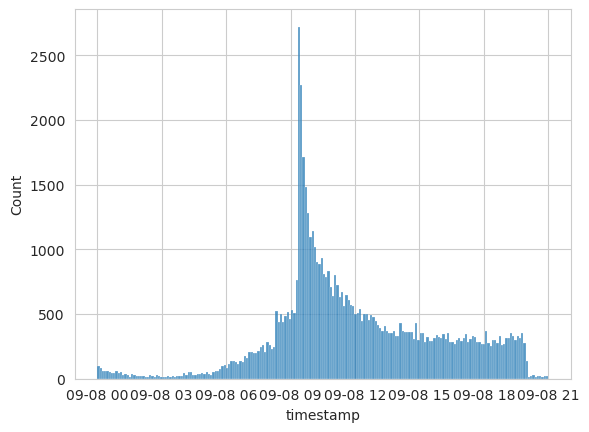

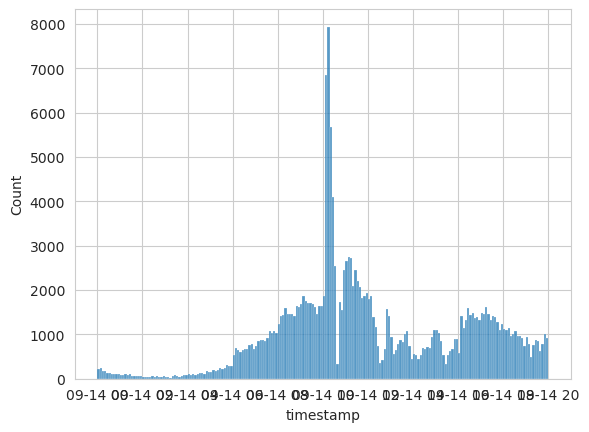

In [63]:
sns.histplot(pd.to_datetime(threeday_2024.query('"2024-09-08 00:00:00" < timestamp').timestamp), bins=200)
plt.show()

sns.histplot(pd.to_datetime(ballots_df.query('"2025-09-14 00:00:00" < timestamp').timestamp), bins=200)
plt.show()

## Voter coercion

In [4]:
threeday_region_names = ballots_df.query('timestamp < "2025-09-13 00:00:00"').merge(elections_df, on='contract_id').region.unique()
east_of_moscow = ballots_df.query('timestamp < "2025-09-12 08:00:00"').merge(elections_df, on='contract_id').region.unique()
threeday = ballots_df.merge(elections_df)

threeday = threeday[threeday.region.isin(threeday_region_names) & ~threeday.region.isin(east_of_moscow)]
len(threeday), len(ballots_df)

(1909390, 2901964)

In [ ]:
start = datetime(2025, 9, 12, 8)
end = datetime(2025, 9, 12, 20)
increment = timedelta(minutes=30)

reference = {}
total = len(threeday)

for current in pd.date_range(start, end, freq=increment):
    count = len(threeday.query(
        f'"{current}" <= timestamp < "{current+increment}"'
    ))
    reference[current] = count / total

reference

{Timestamp('2025-09-12 08:00:00'): 0.15627975426706958,
 Timestamp('2025-09-12 08:30:00'): 0.10419086724032282,
 Timestamp('2025-09-12 09:00:00'): 0.0885392717045758,
 Timestamp('2025-09-12 09:30:00'): 0.06511660792190176,
 Timestamp('2025-09-12 10:00:00'): 0.049487008940027964,
 Timestamp('2025-09-12 10:30:00'): 0.04347775991285175,
 Timestamp('2025-09-12 11:00:00'): 0.03705633736428912,
 Timestamp('2025-09-12 11:30:00'): 0.03134980281660635,
 Timestamp('2025-09-12 12:00:00'): 0.04083503108322553,
 Timestamp('2025-09-12 12:30:00'): 0.03413550924640854,
 Timestamp('2025-09-12 13:00:00'): 0.023941153981114387,
 Timestamp('2025-09-12 13:30:00'): 0.0192715998303123,
 Timestamp('2025-09-12 14:00:00'): 0.016331393795924354,
 Timestamp('2025-09-12 14:30:00'): 0.01437055813636816,
 Timestamp('2025-09-12 15:00:00'): 0.01234739890750449,
 Timestamp('2025-09-12 15:30:00'): 0.010852156971598258,
 Timestamp('2025-09-12 16:00:00'): 0.010433174993060611,
 Timestamp('2025-09-12 16:30:00'): 0.00957059

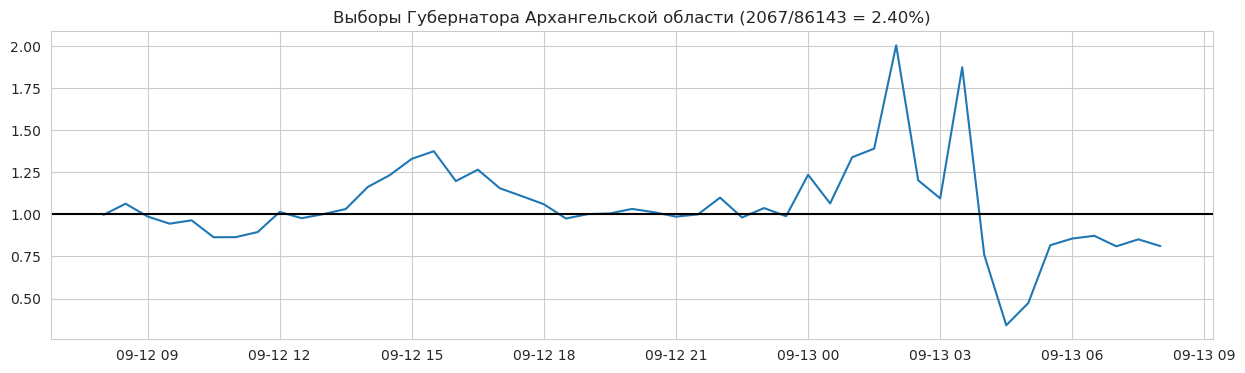

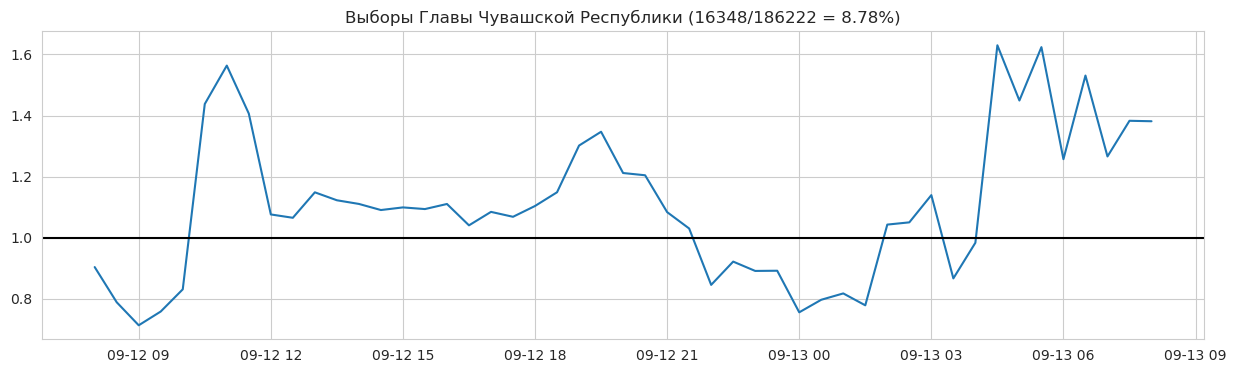

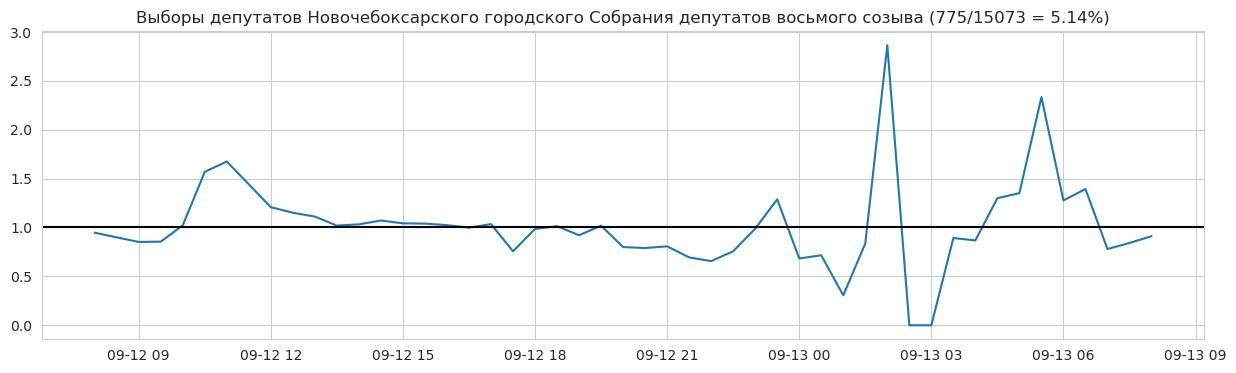

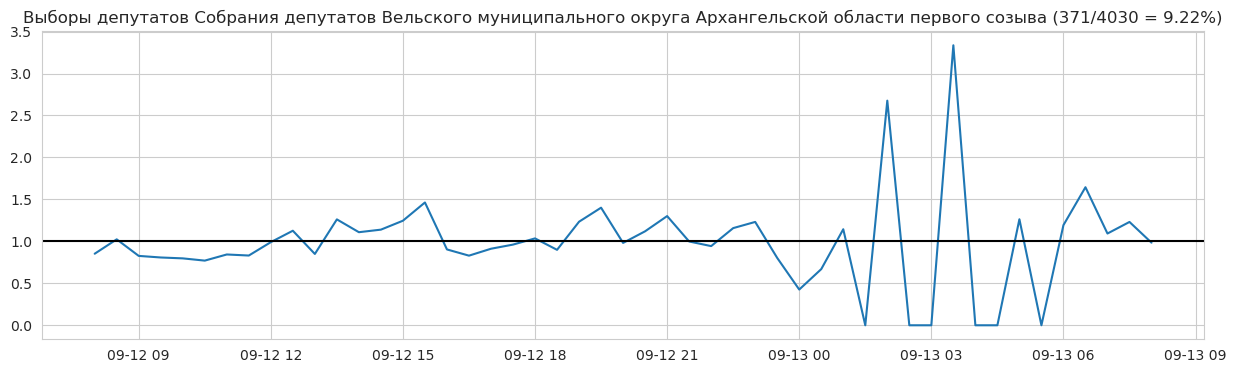

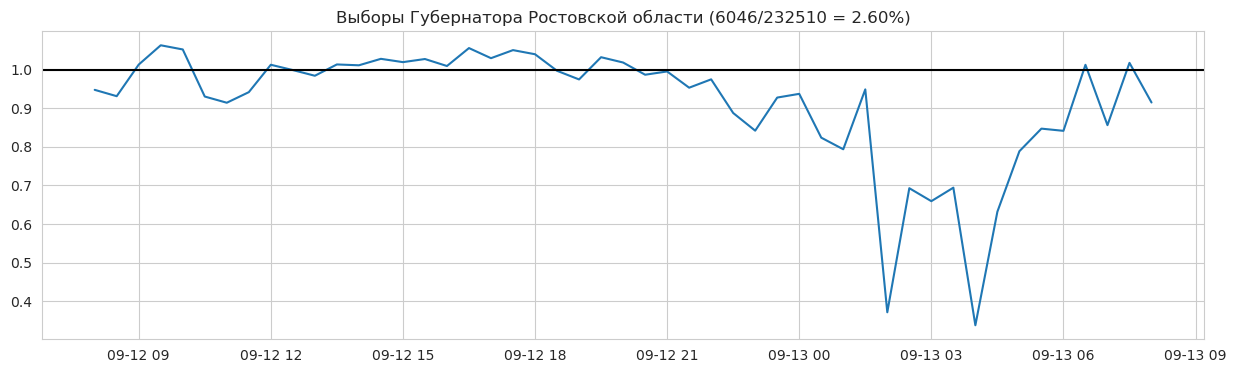

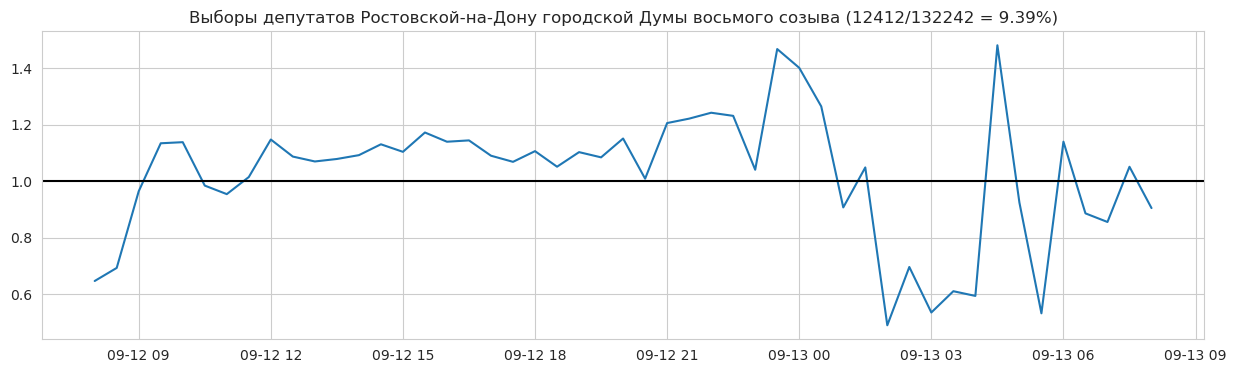

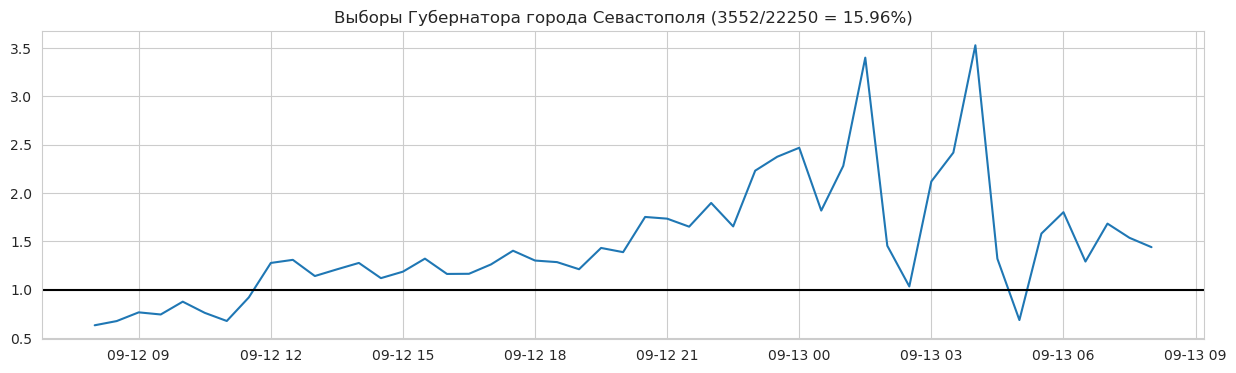

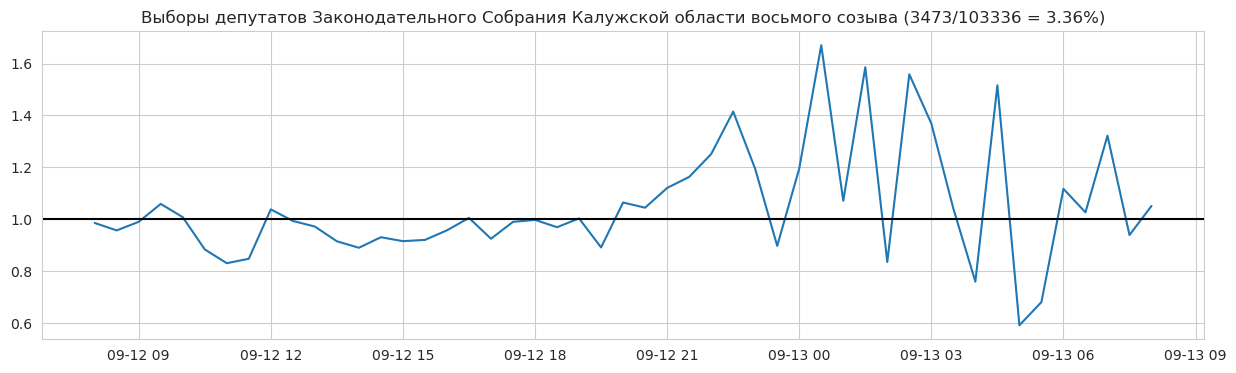

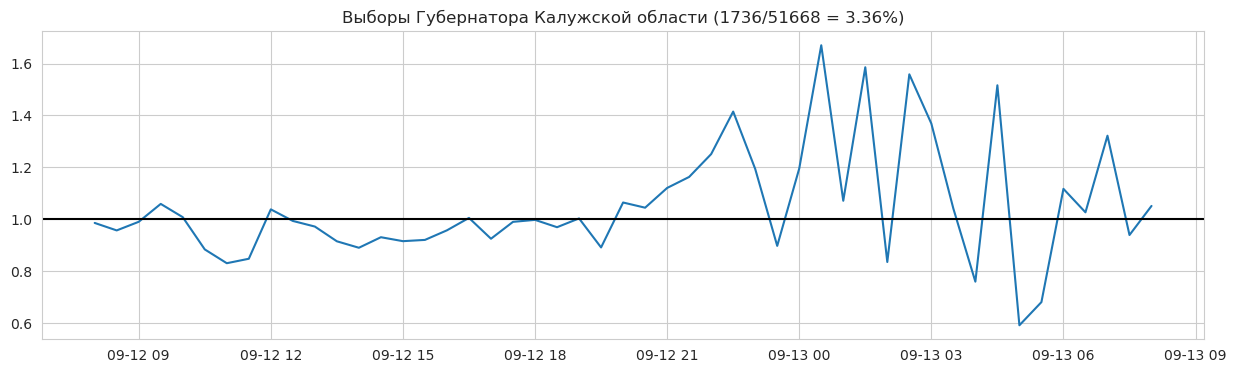

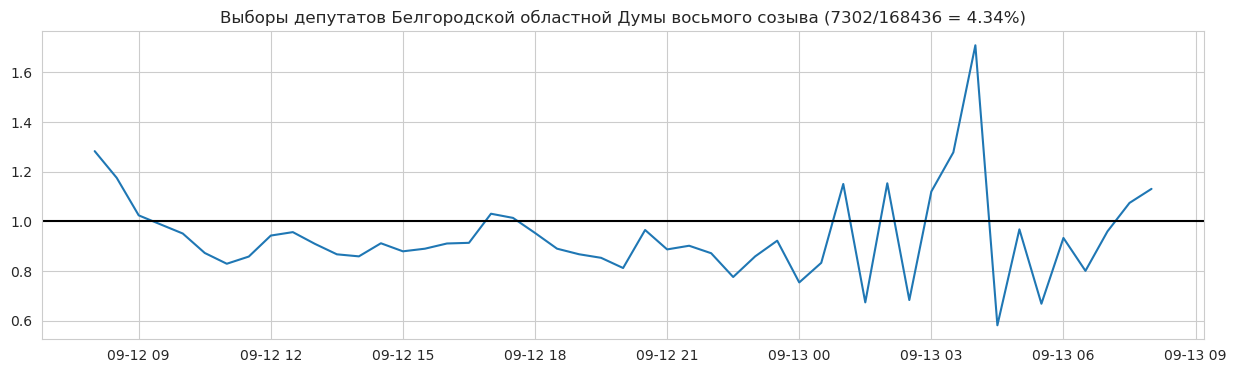

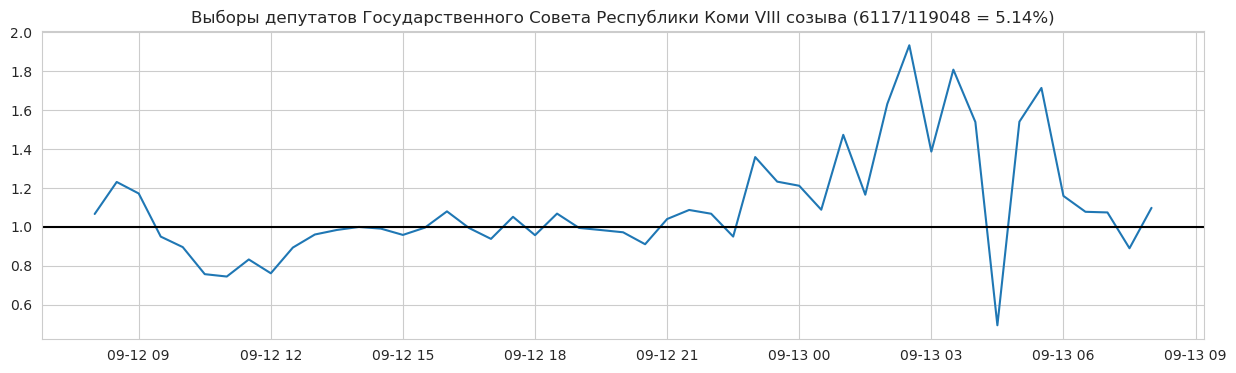

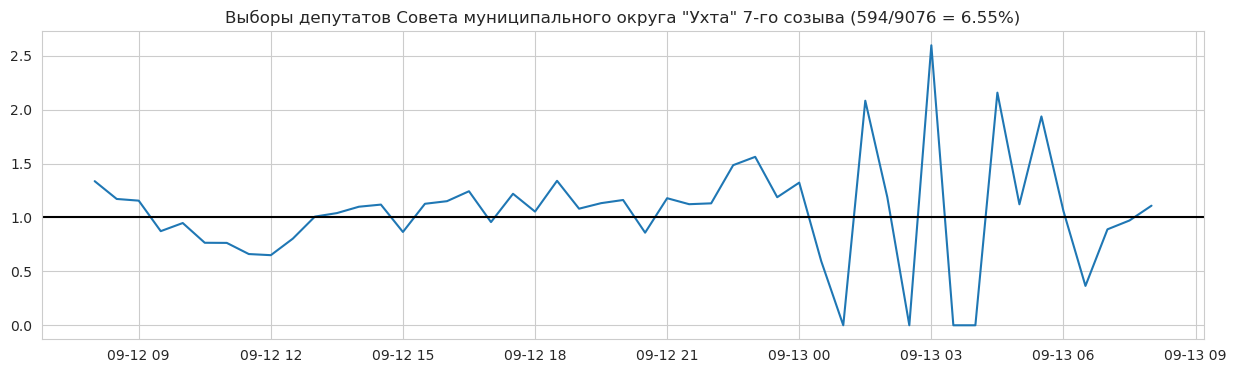

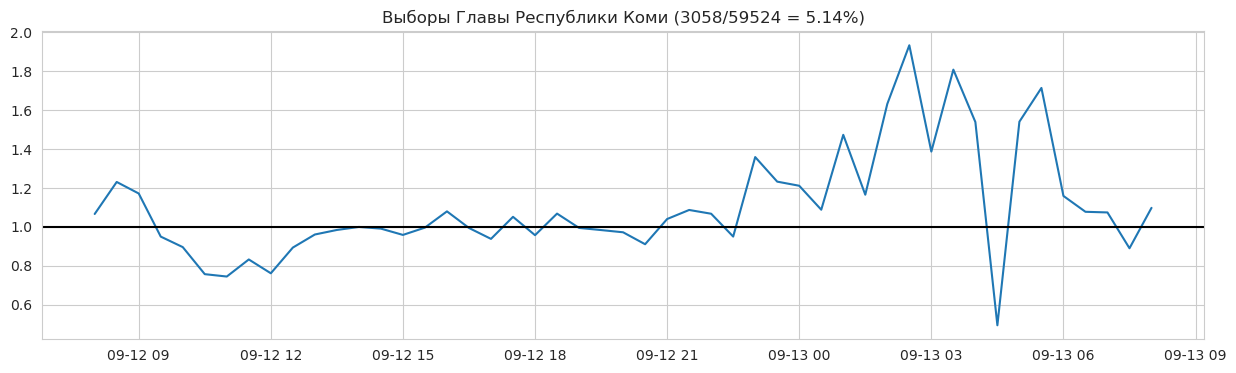

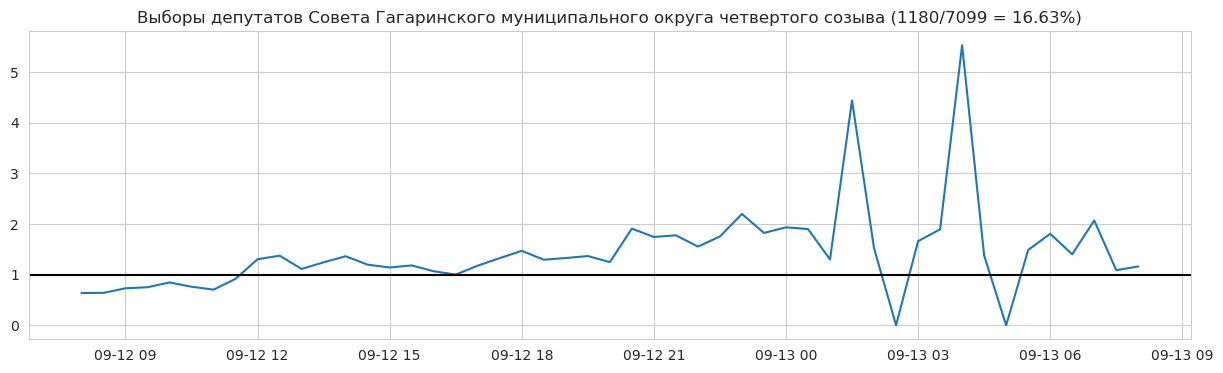

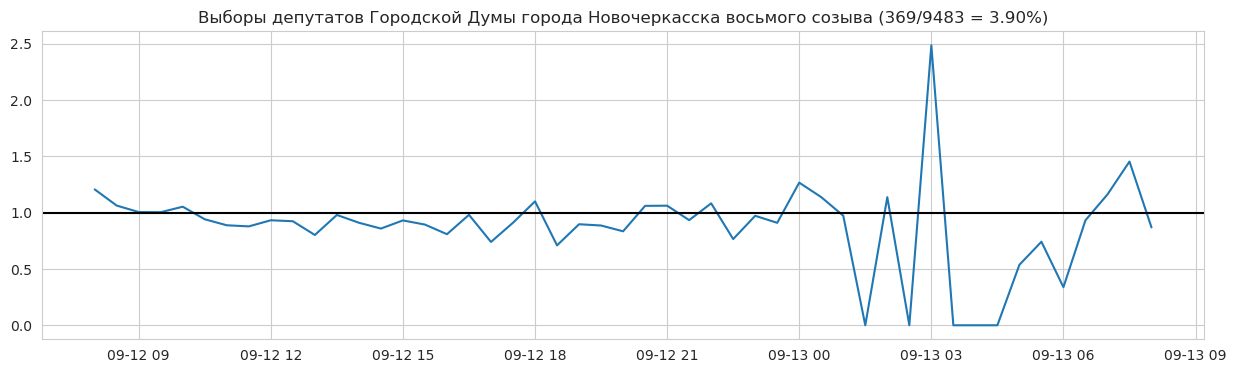

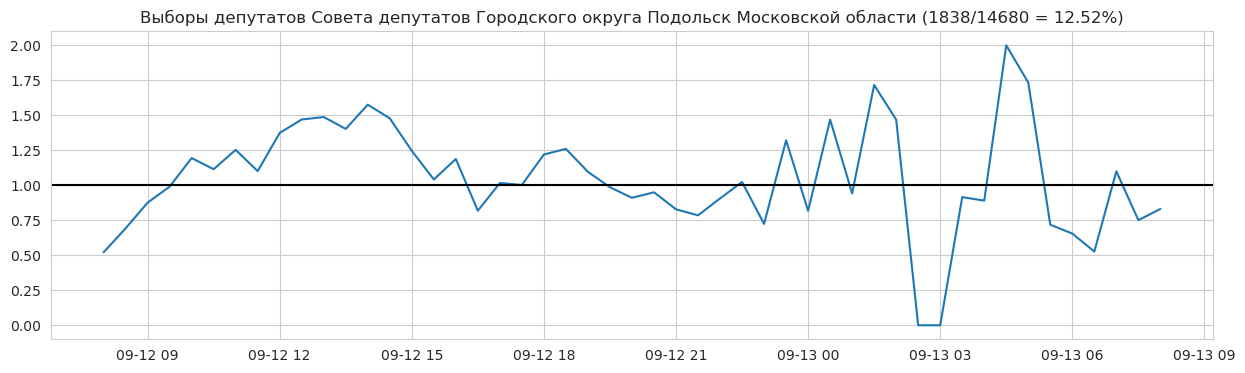

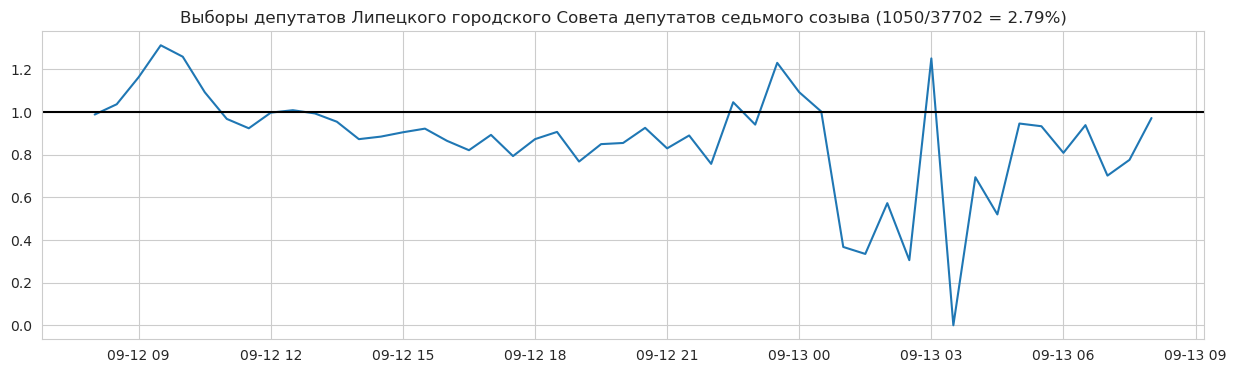

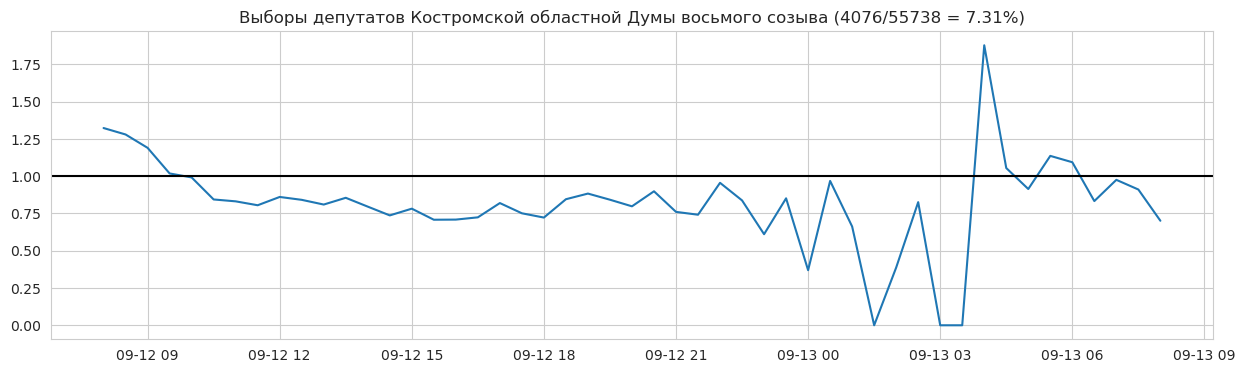

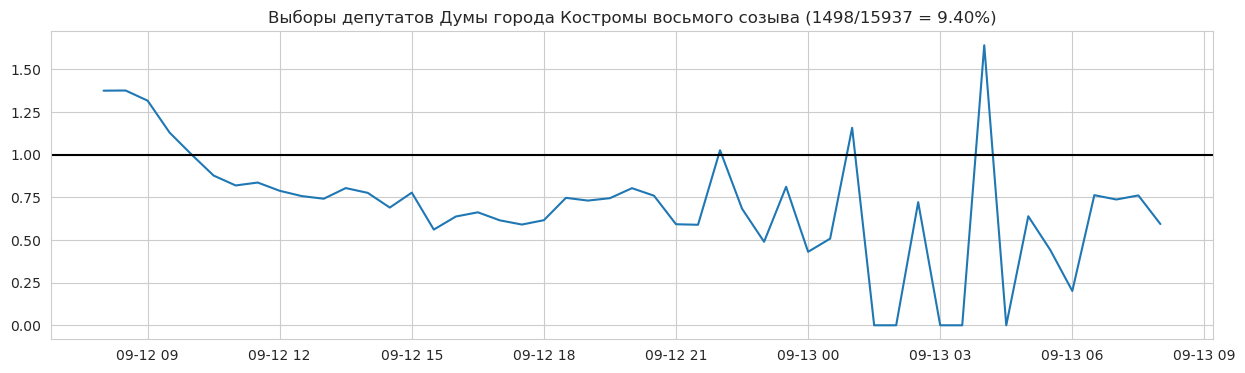

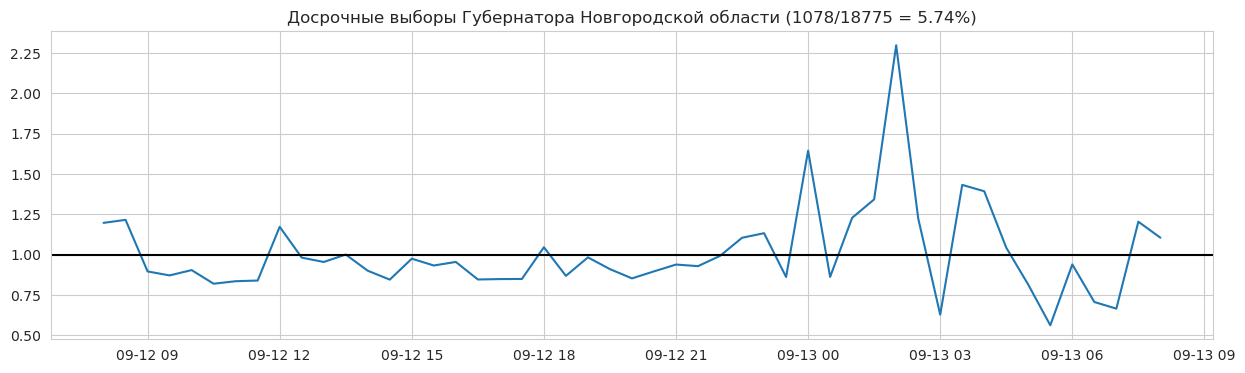

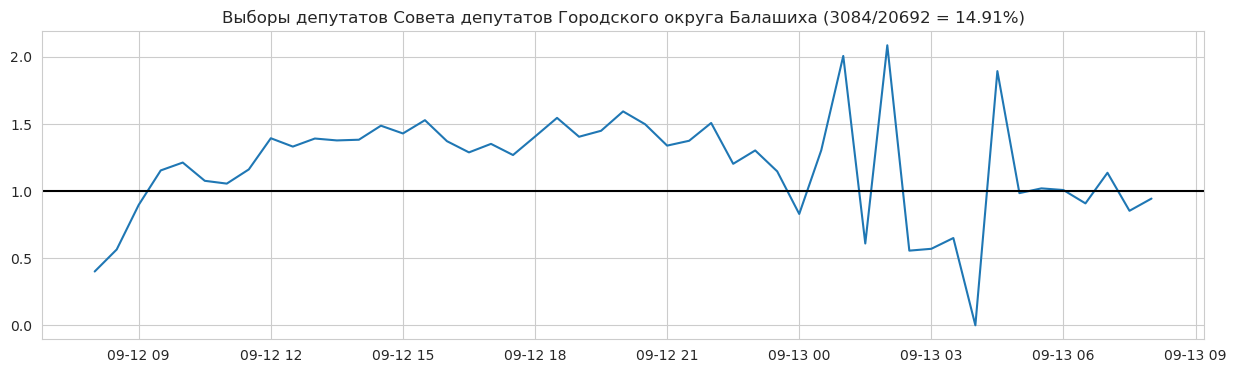

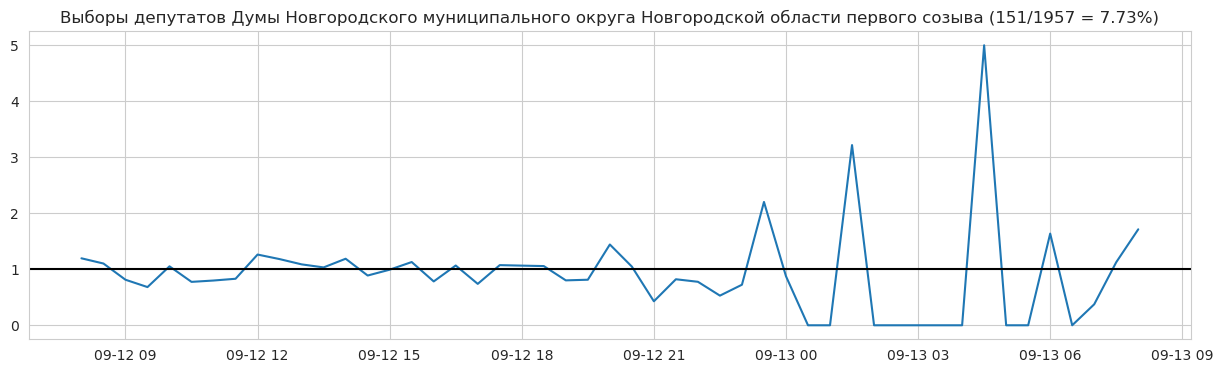

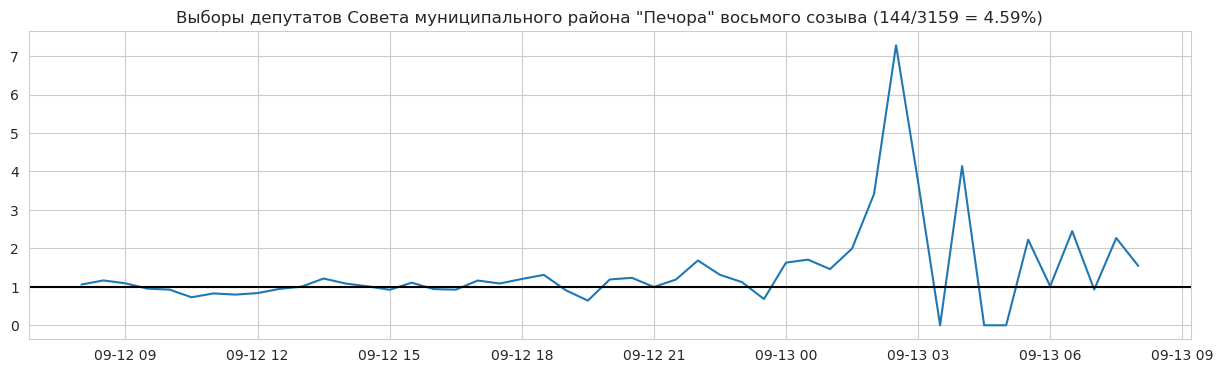

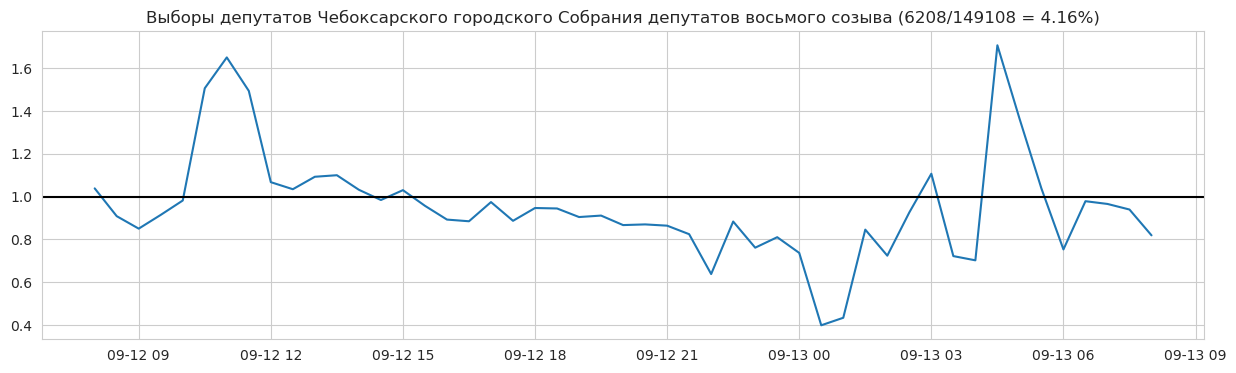

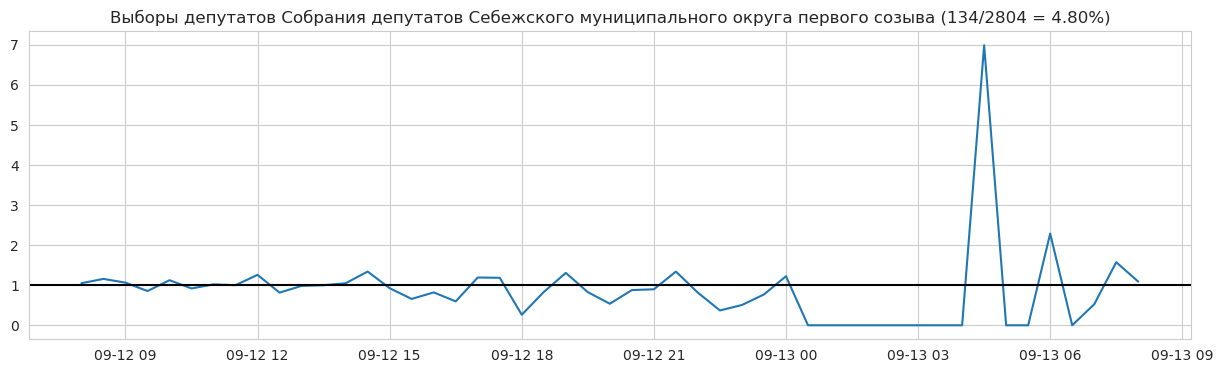

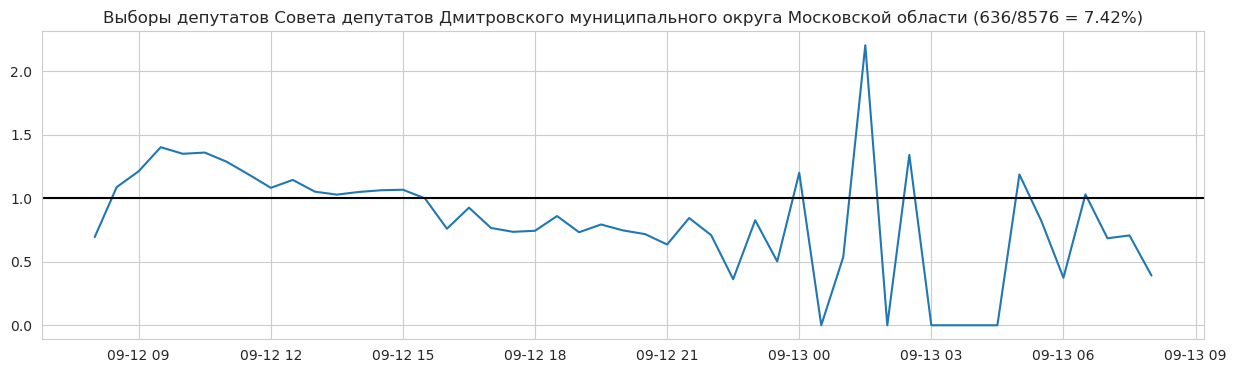

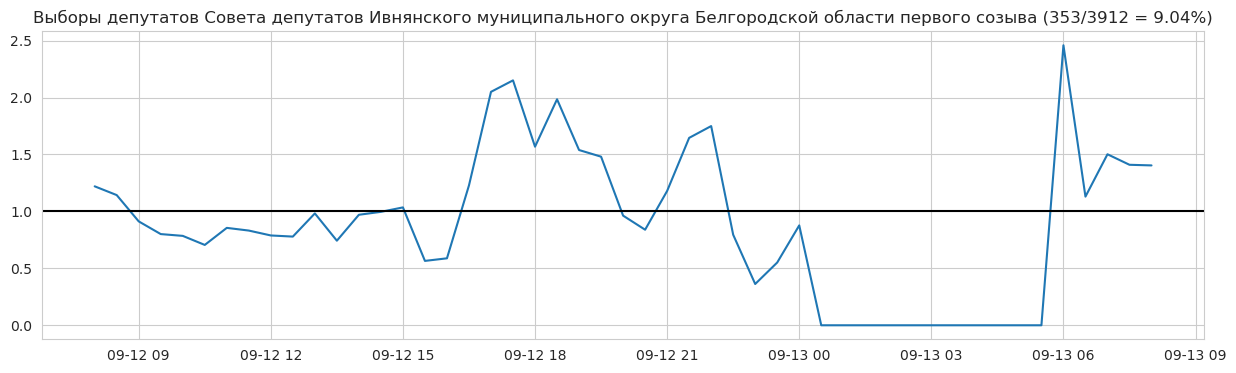

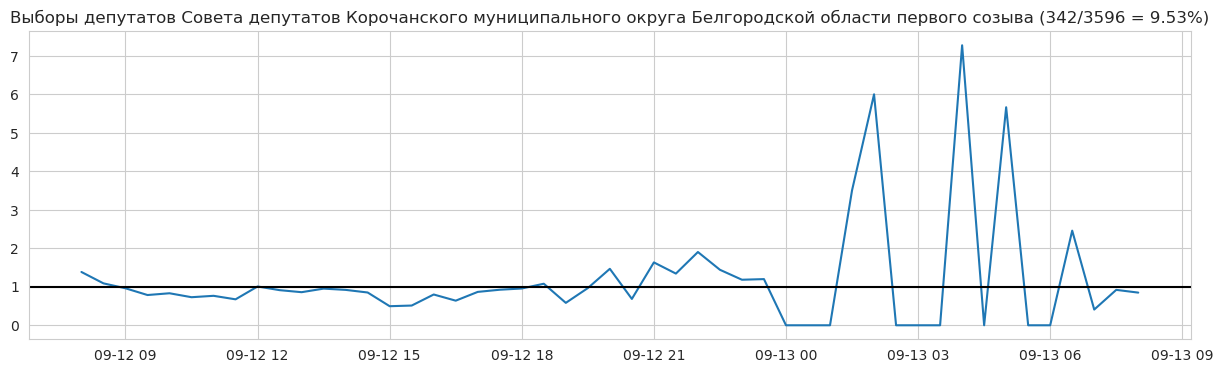

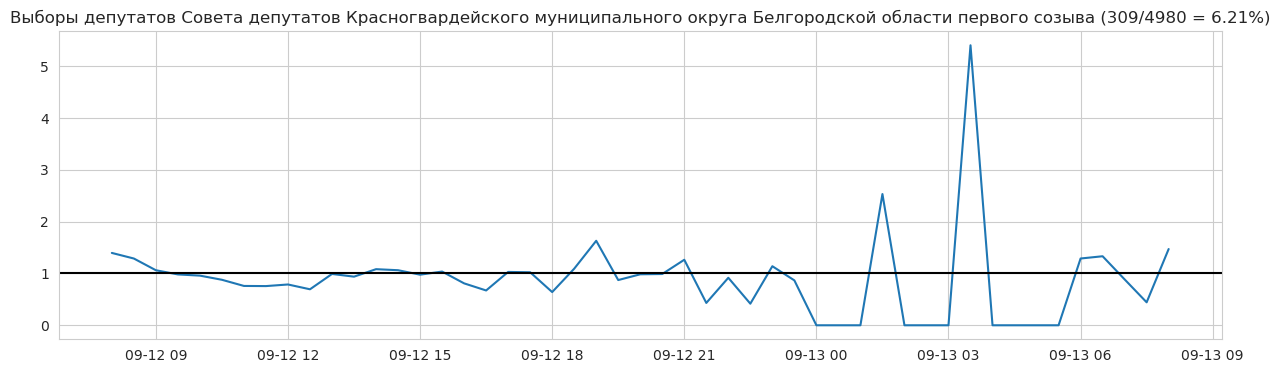

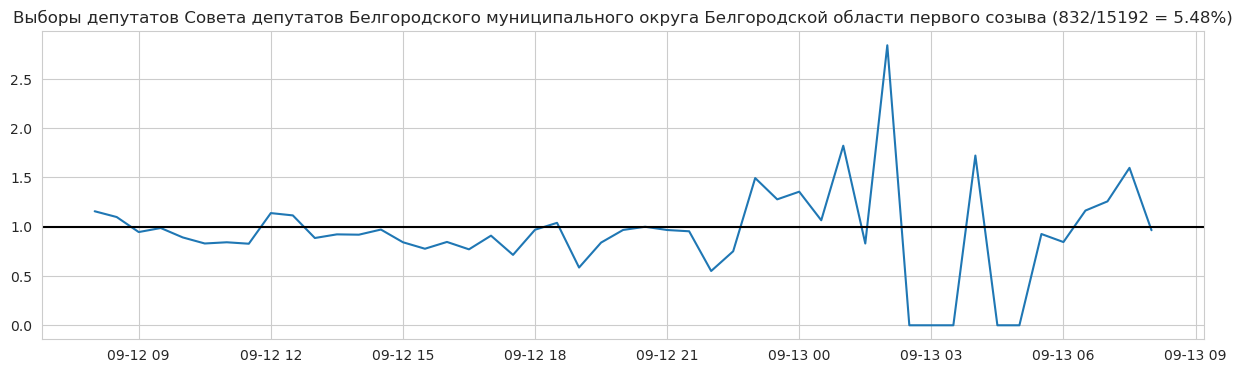

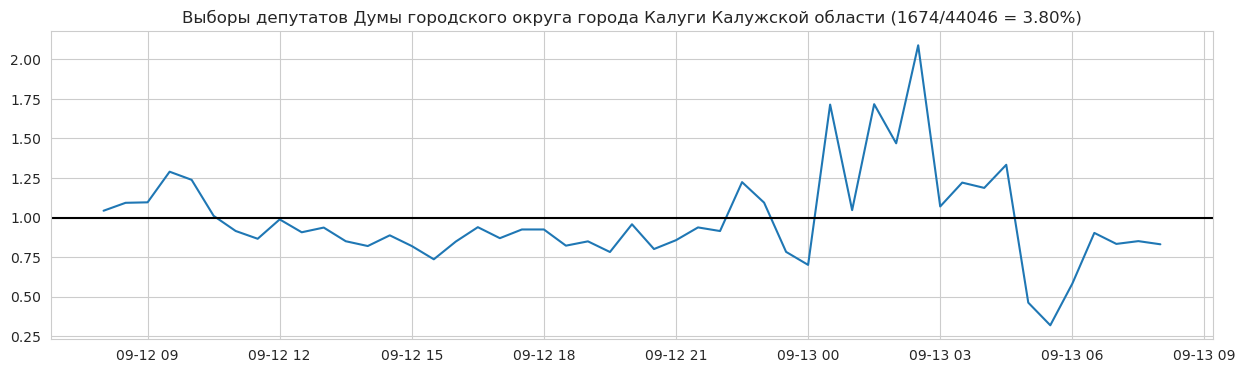

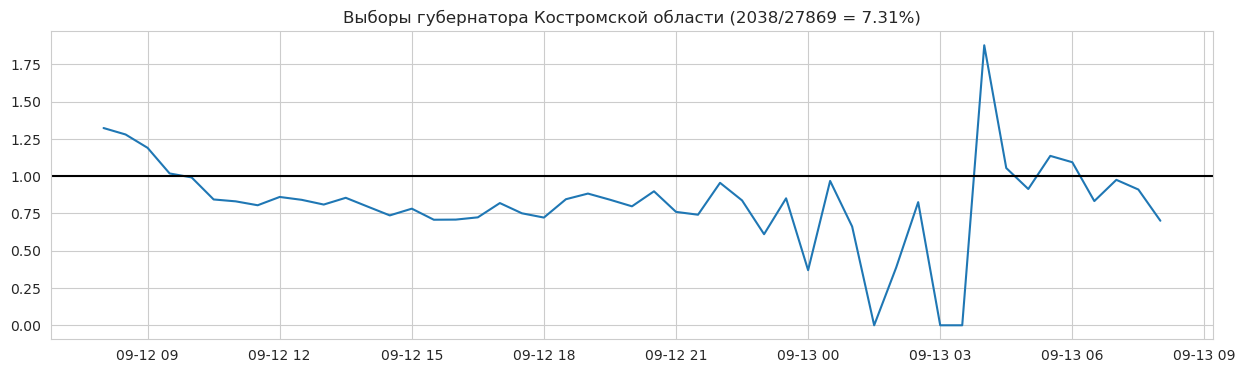

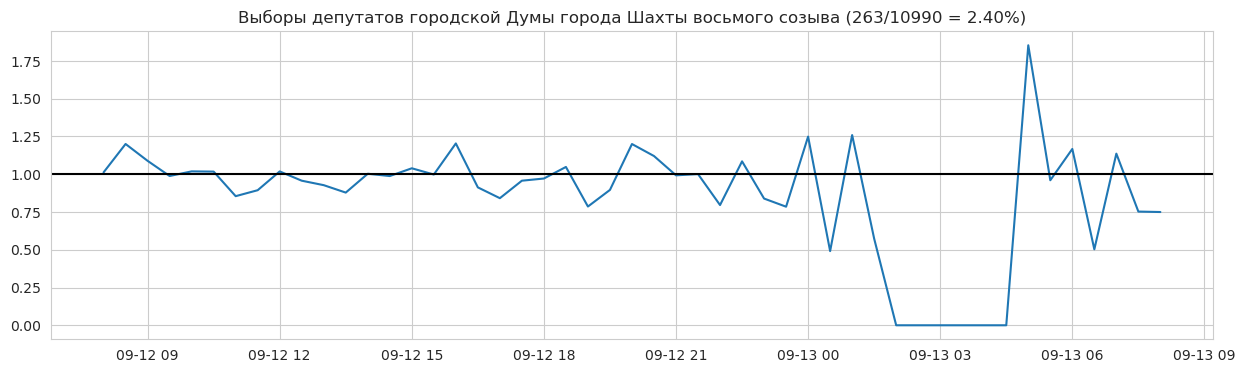

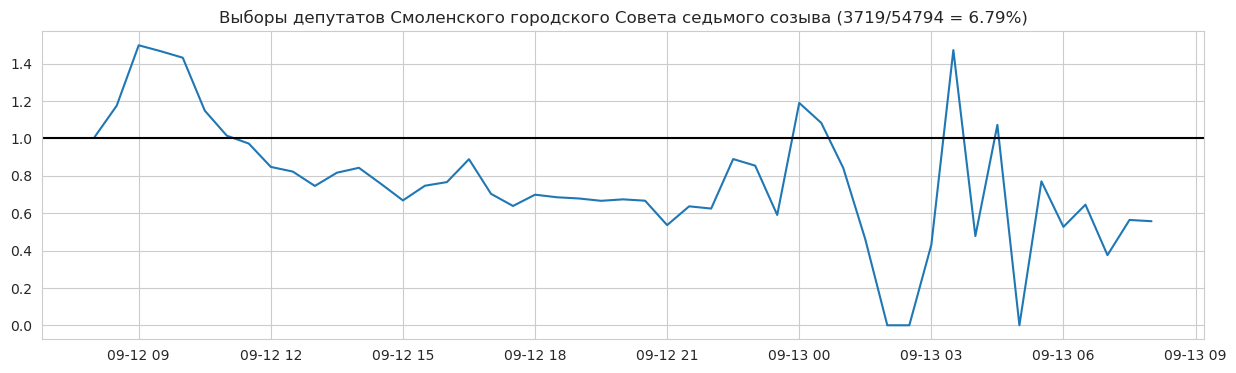

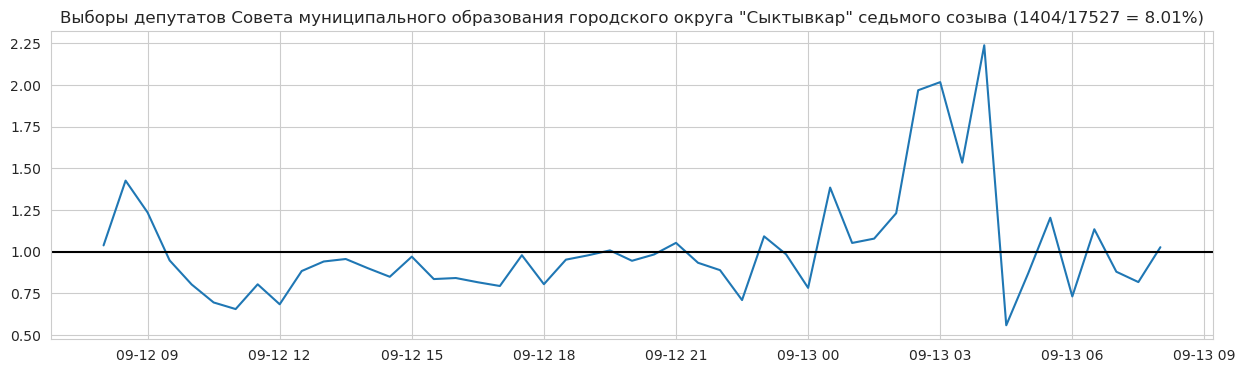

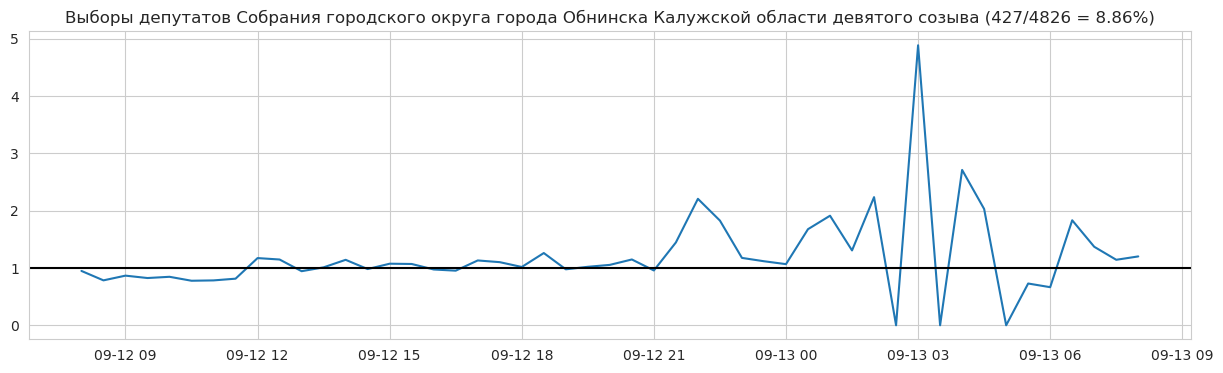

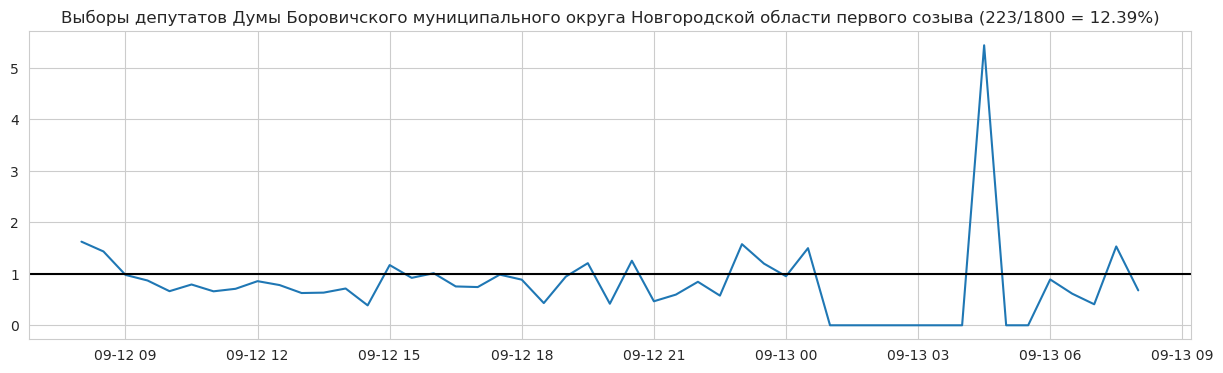

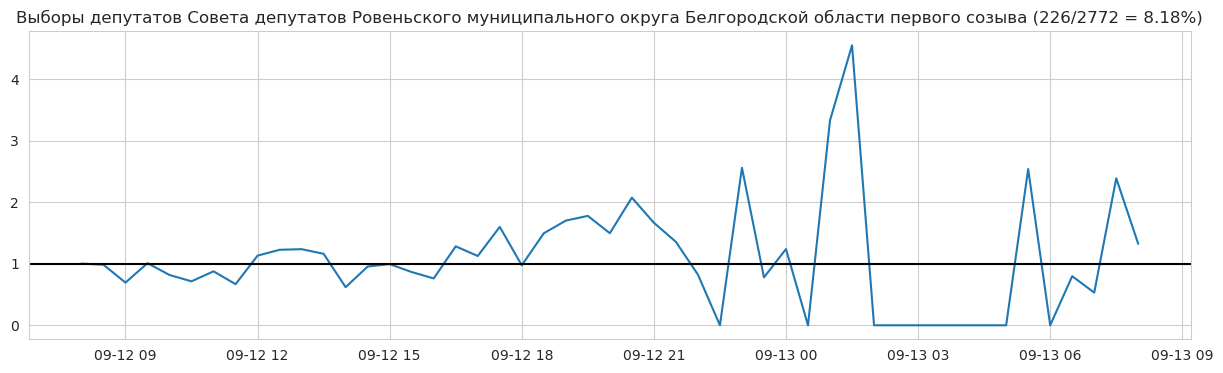

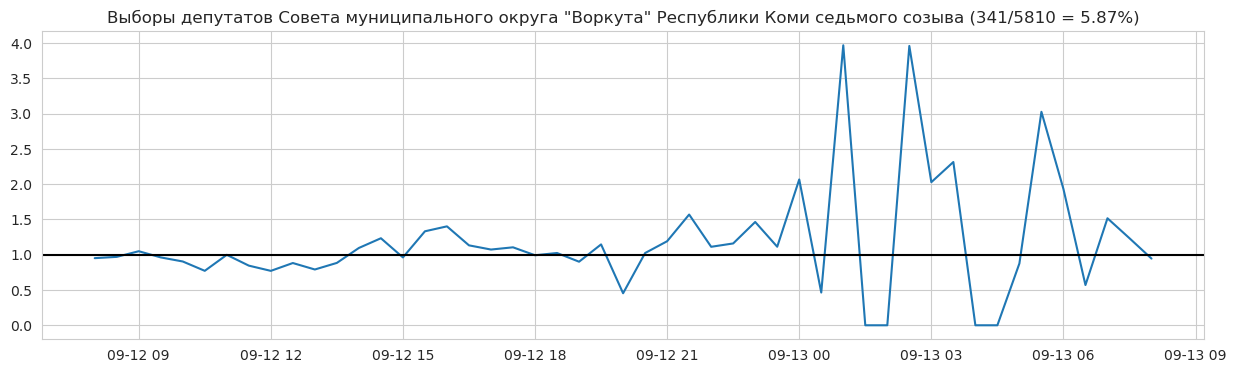

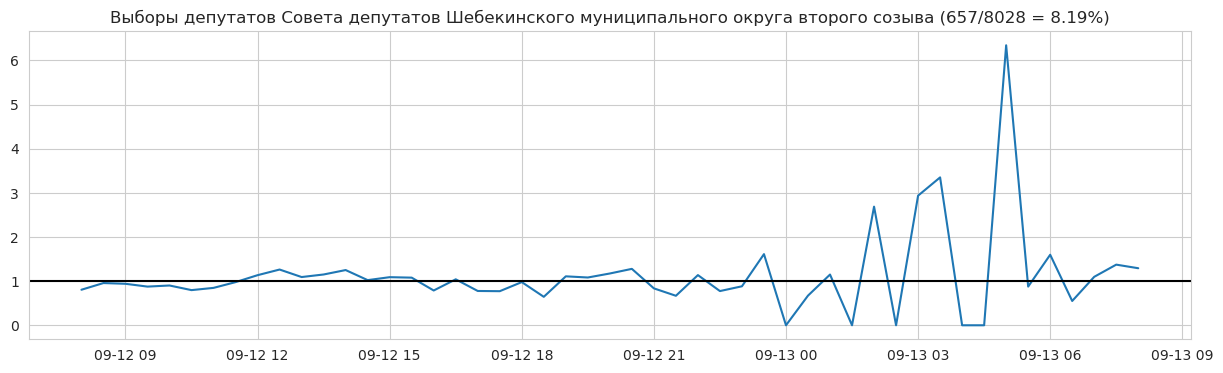

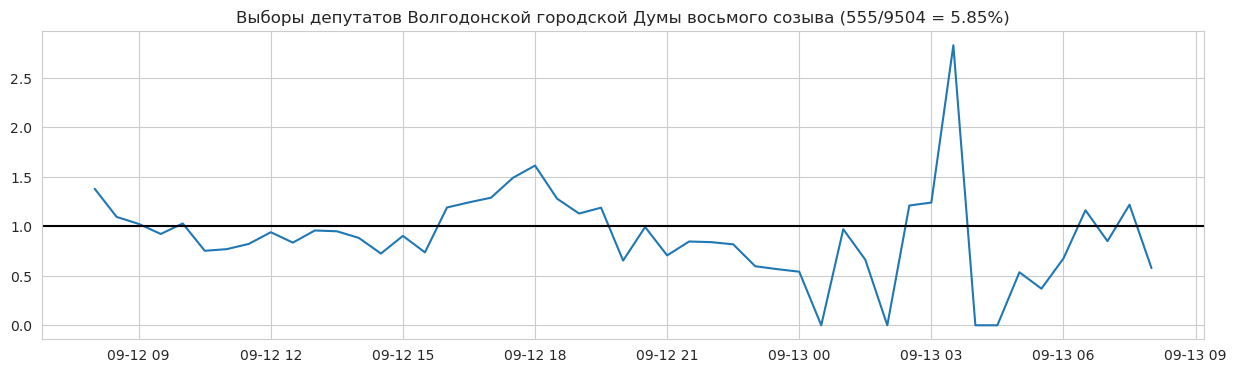

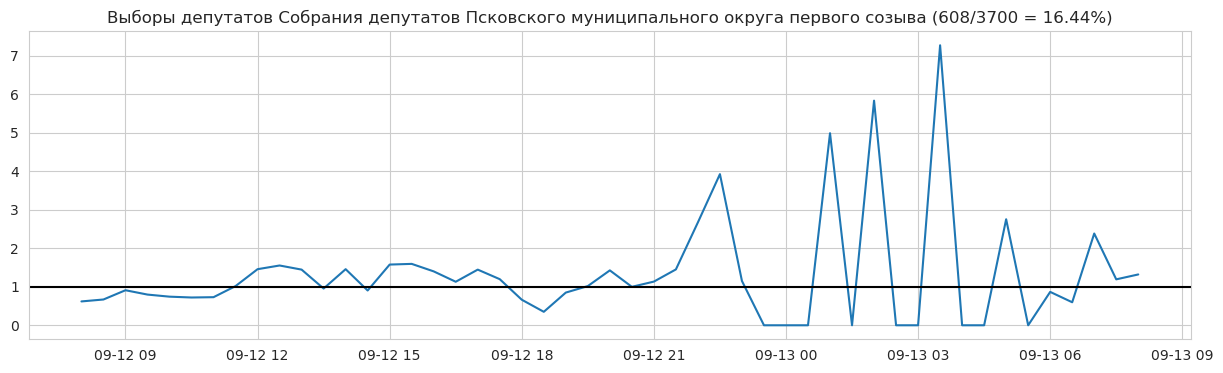

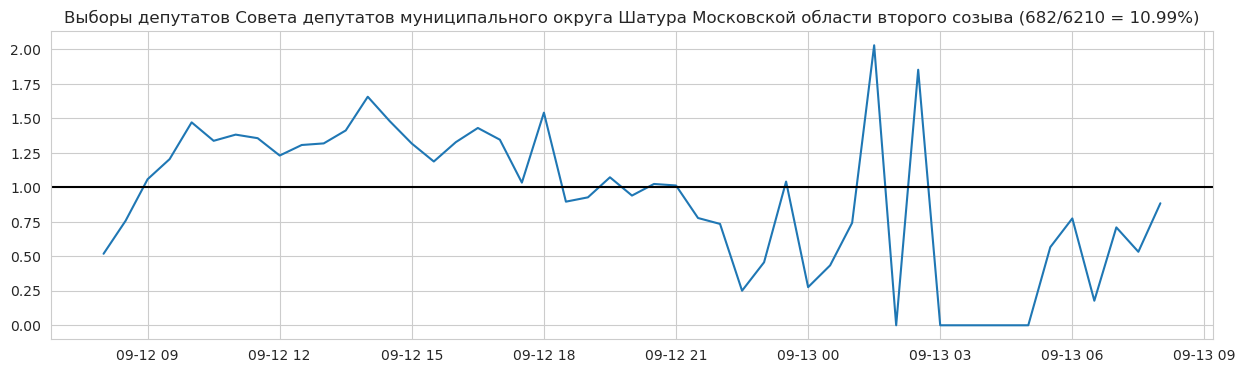

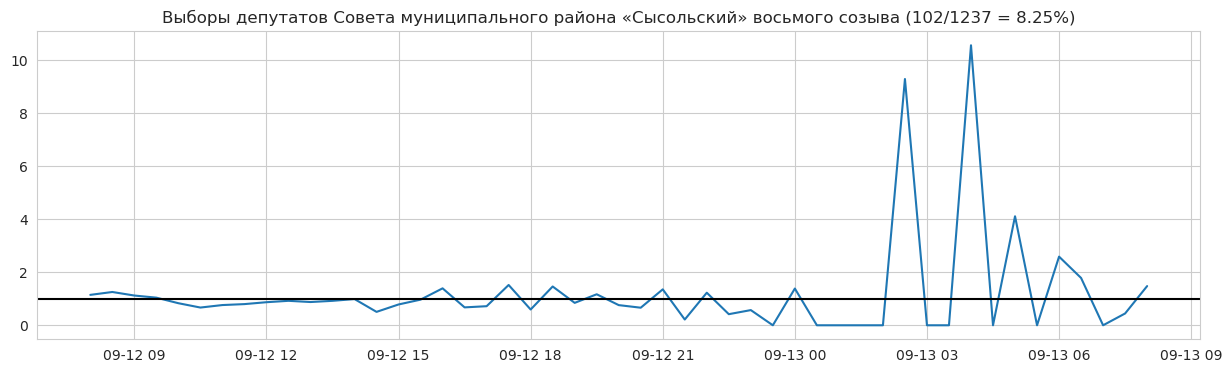

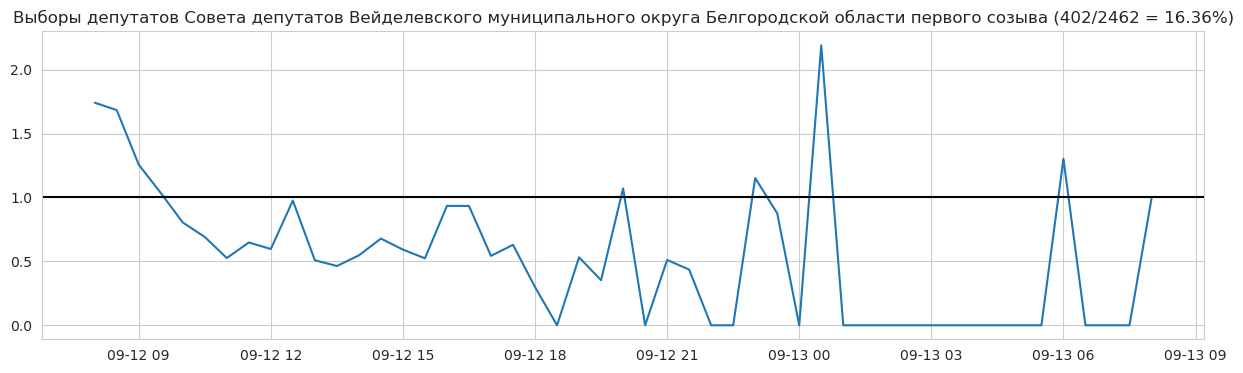

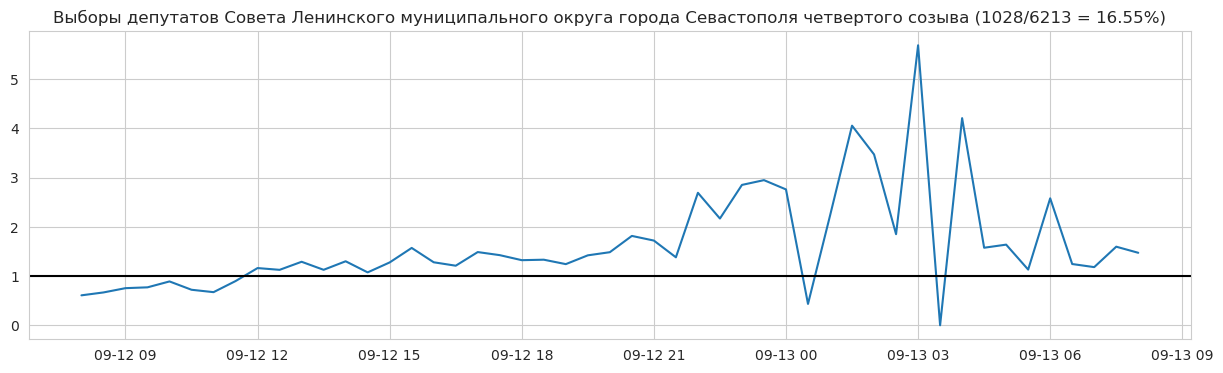

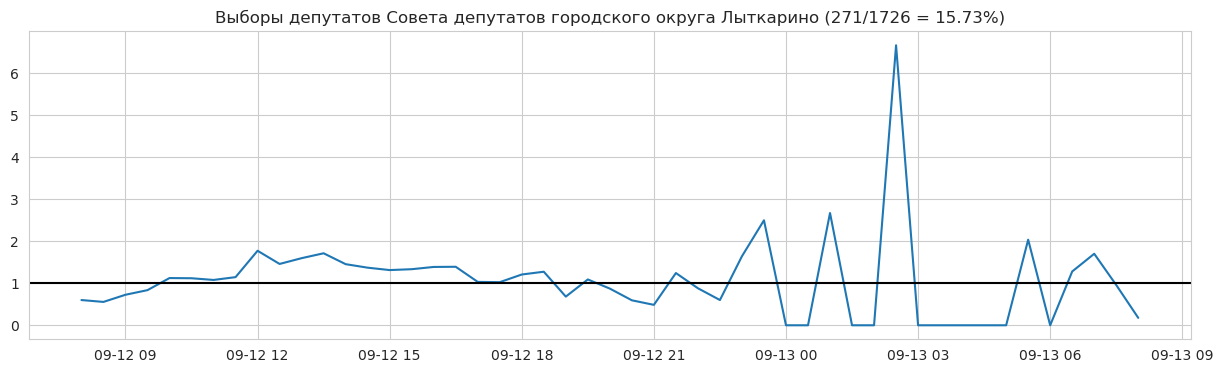

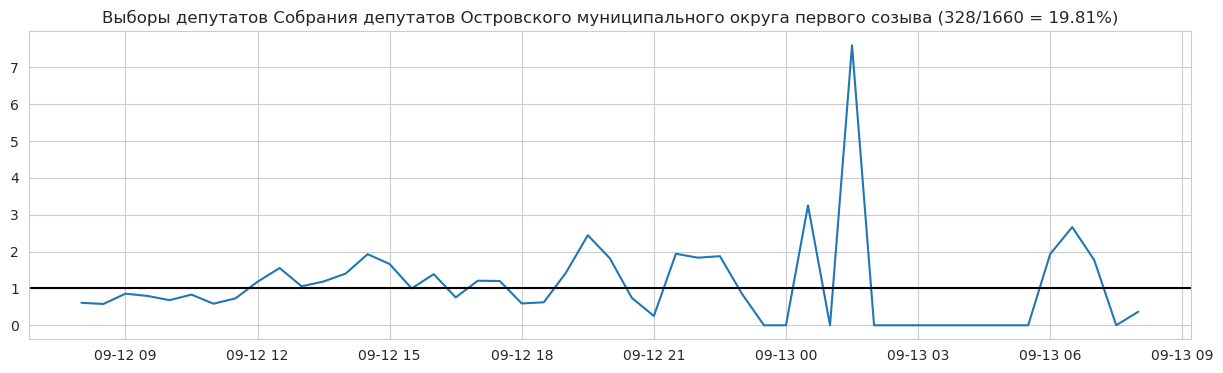

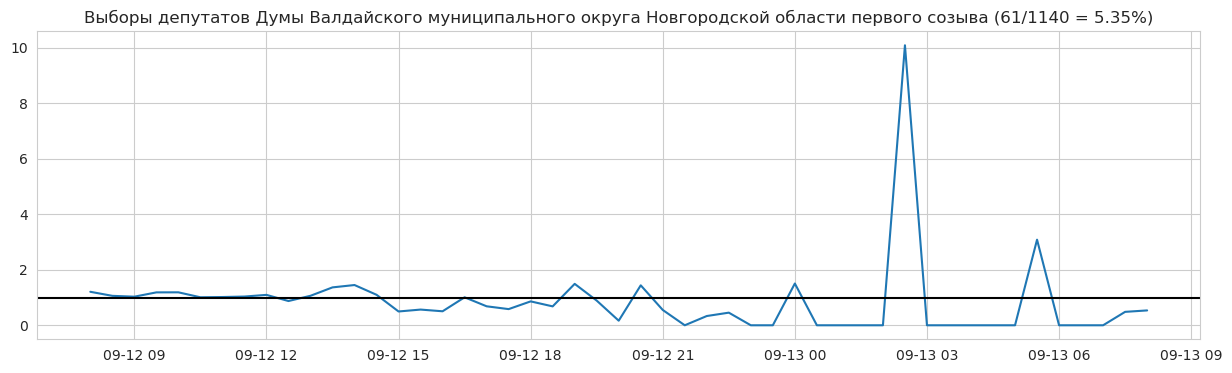

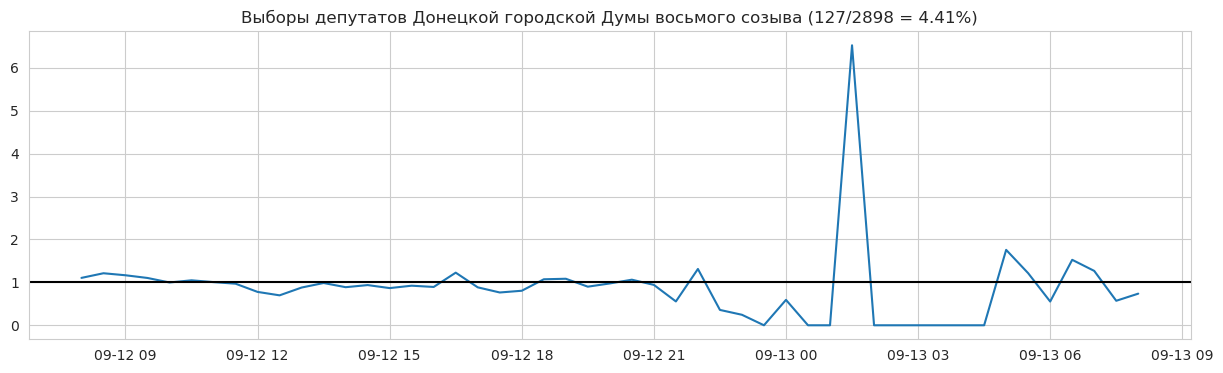

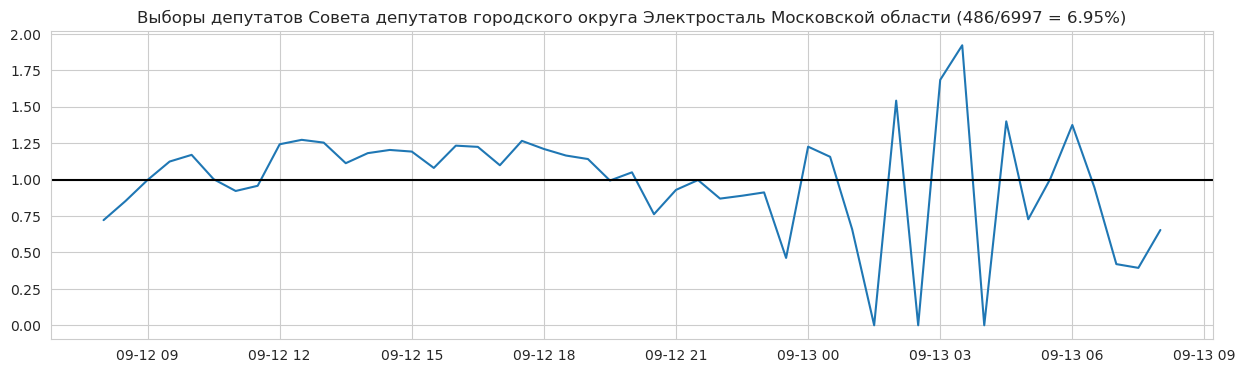

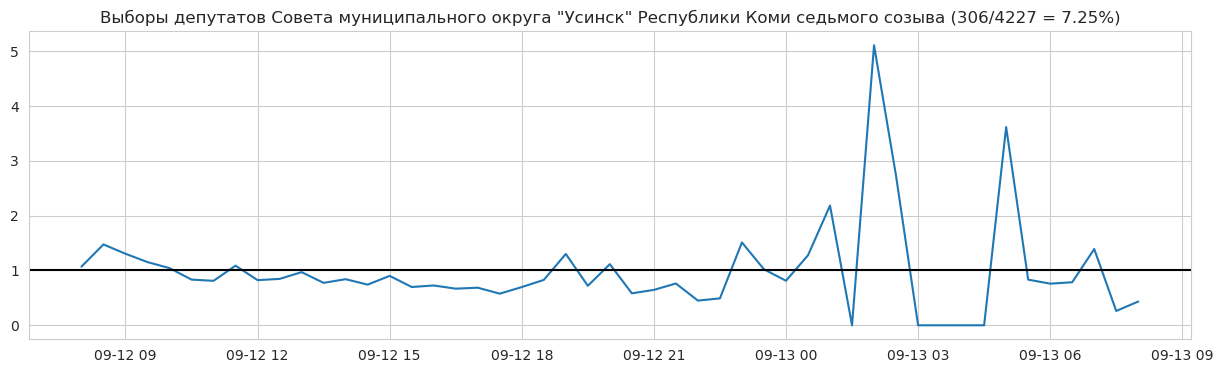

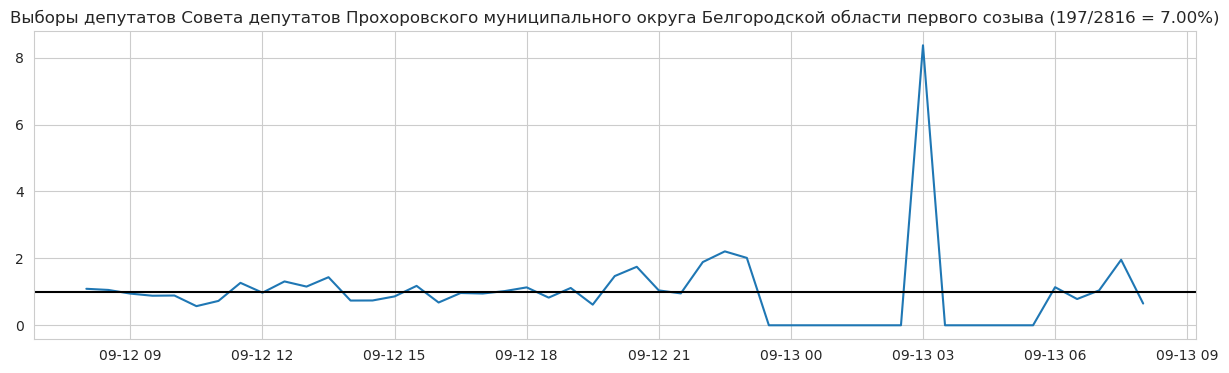

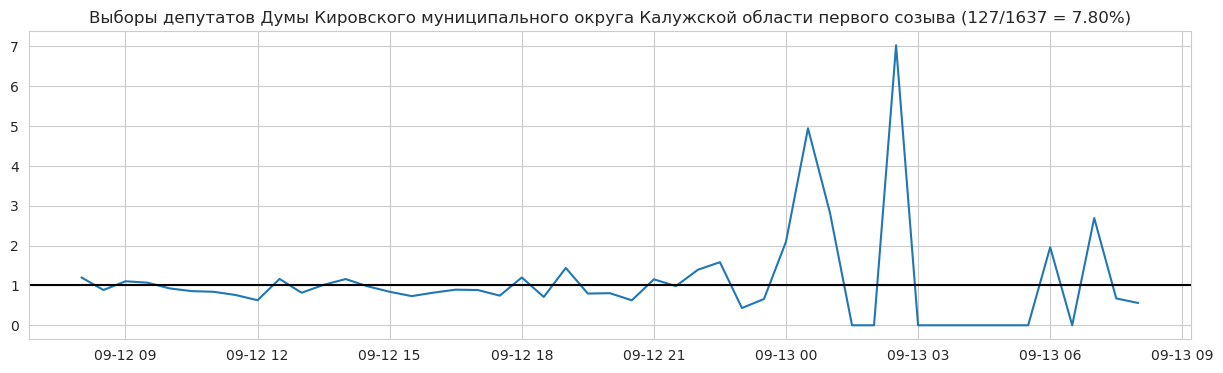

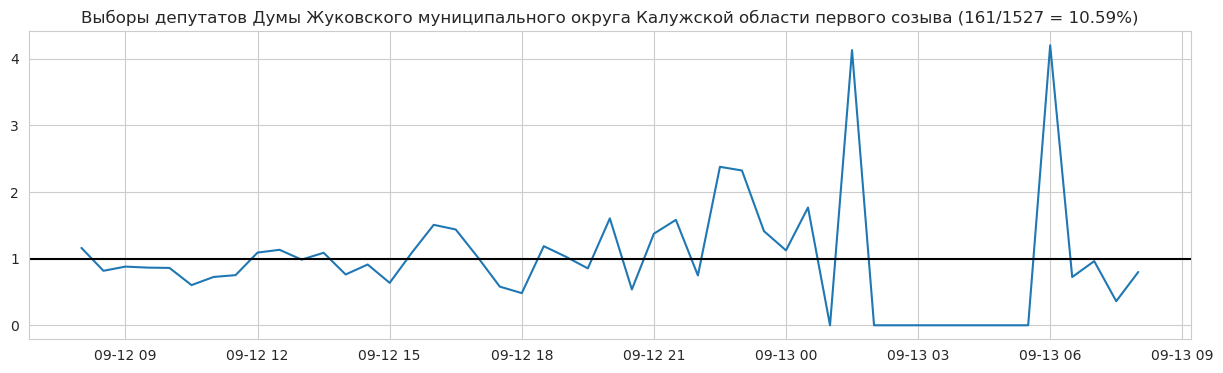

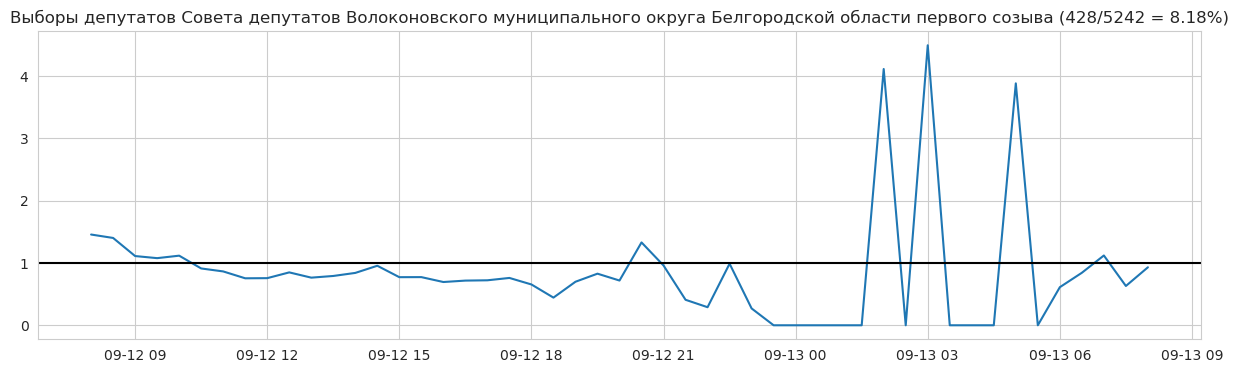

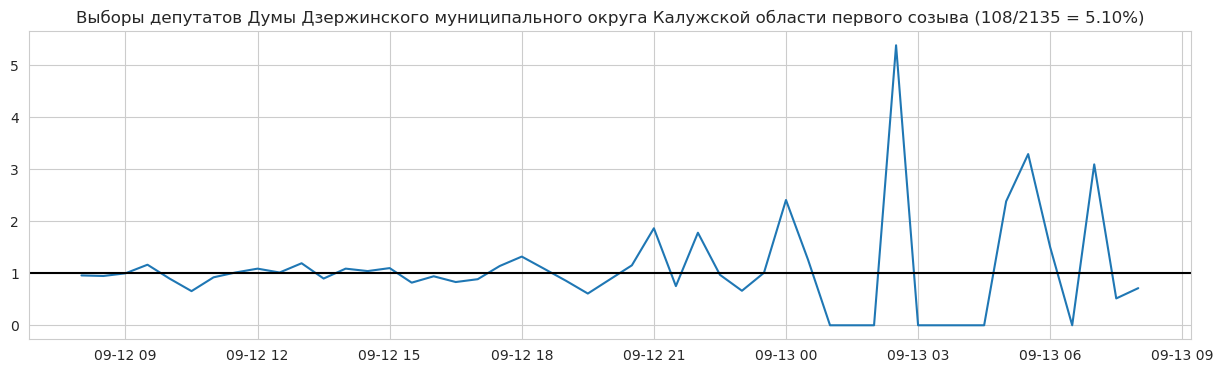

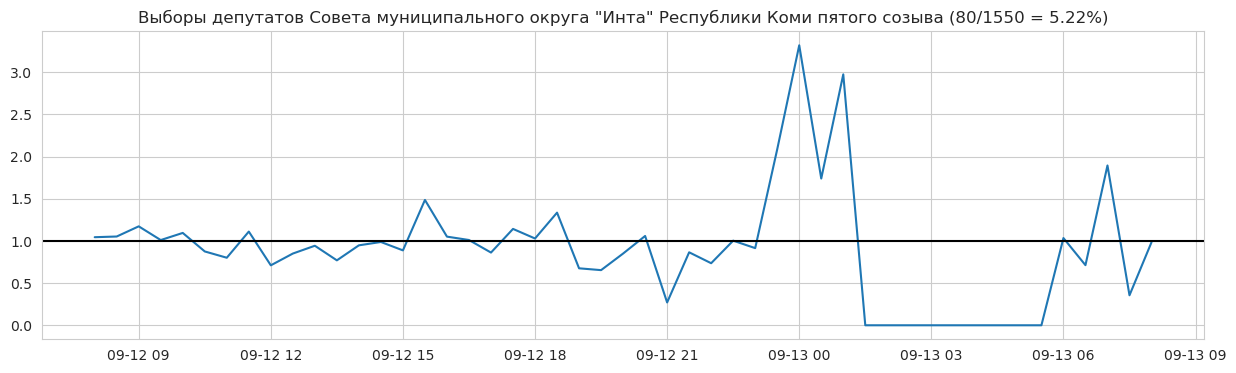

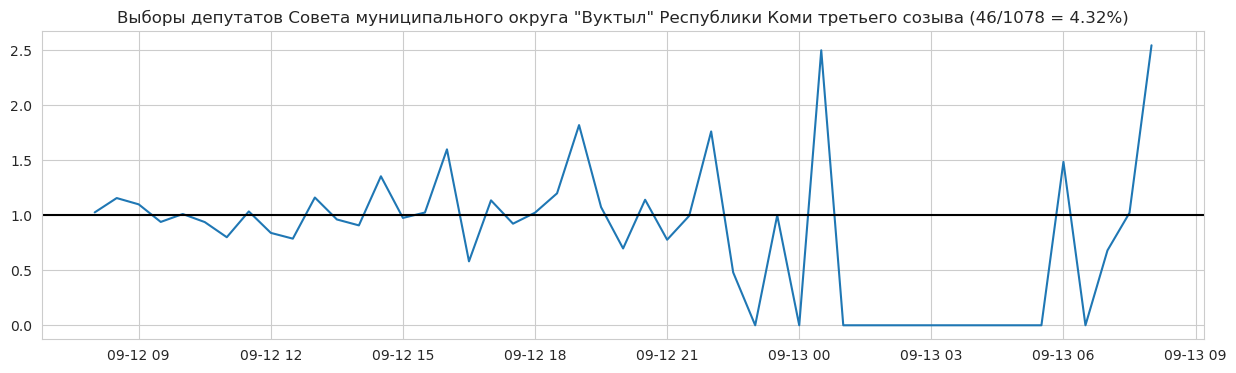

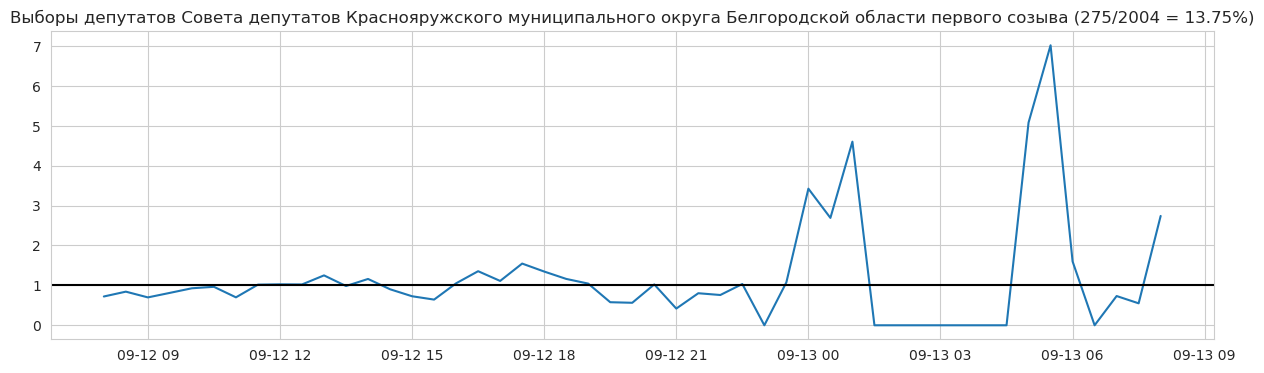

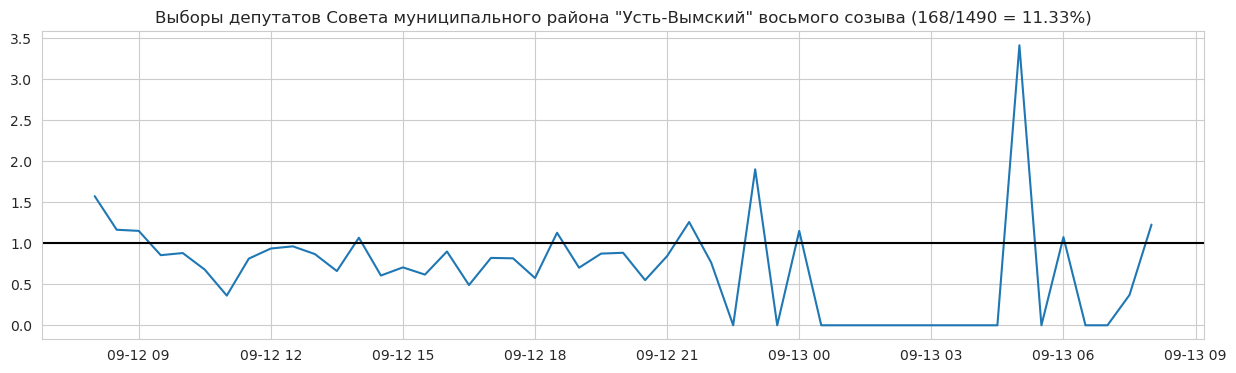

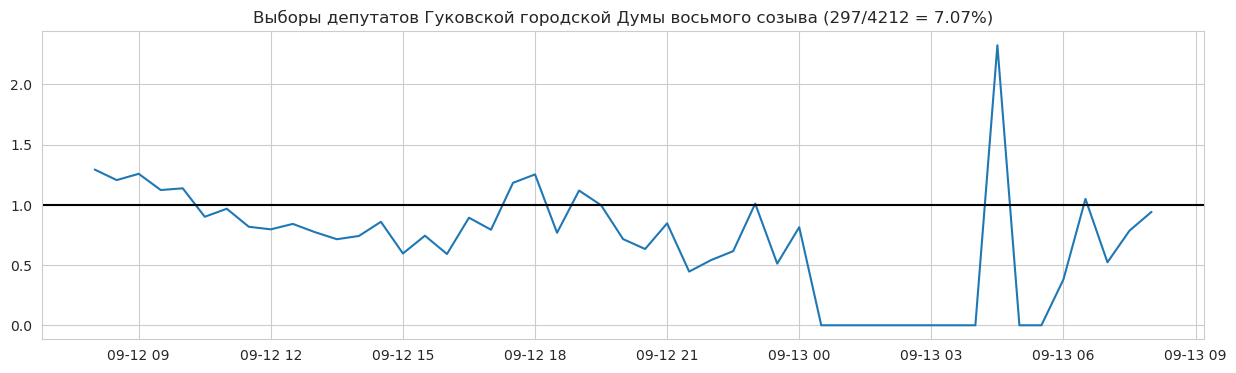

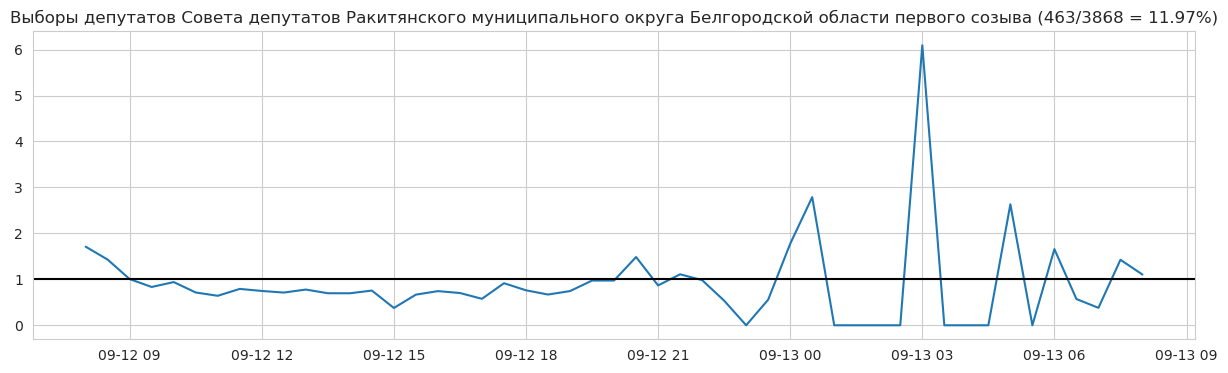

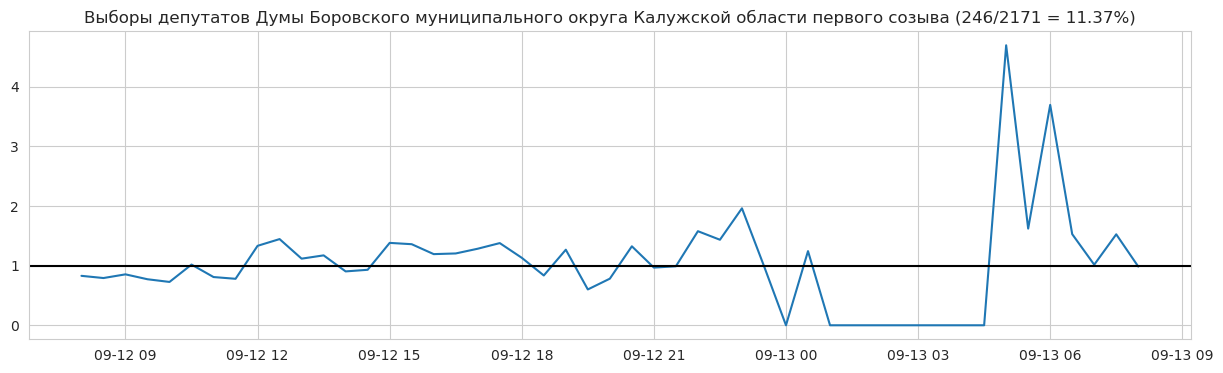

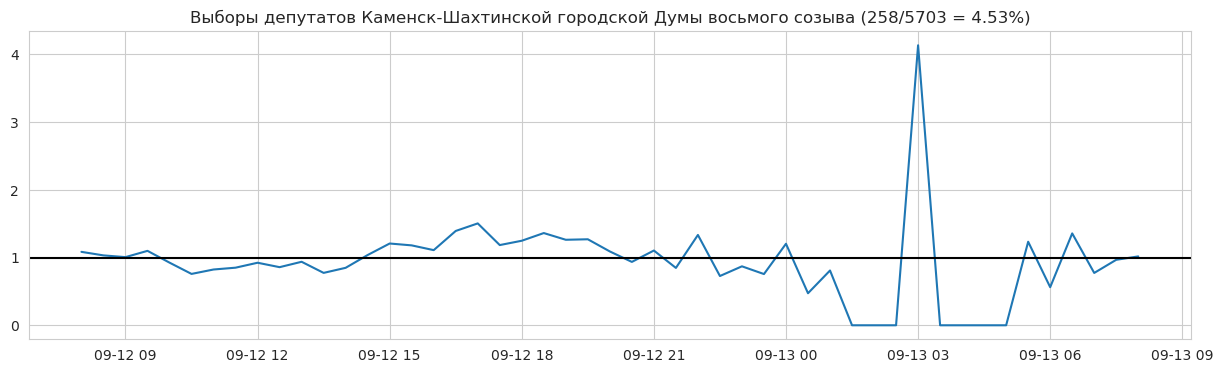

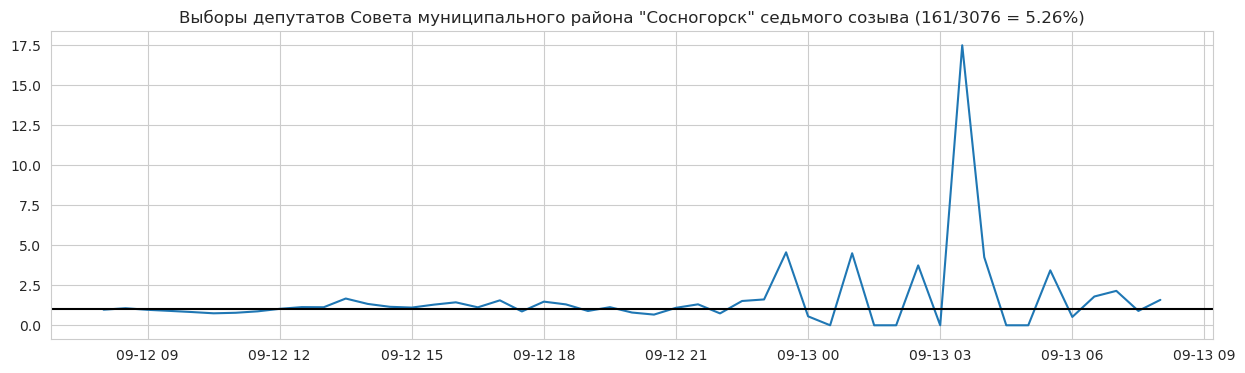

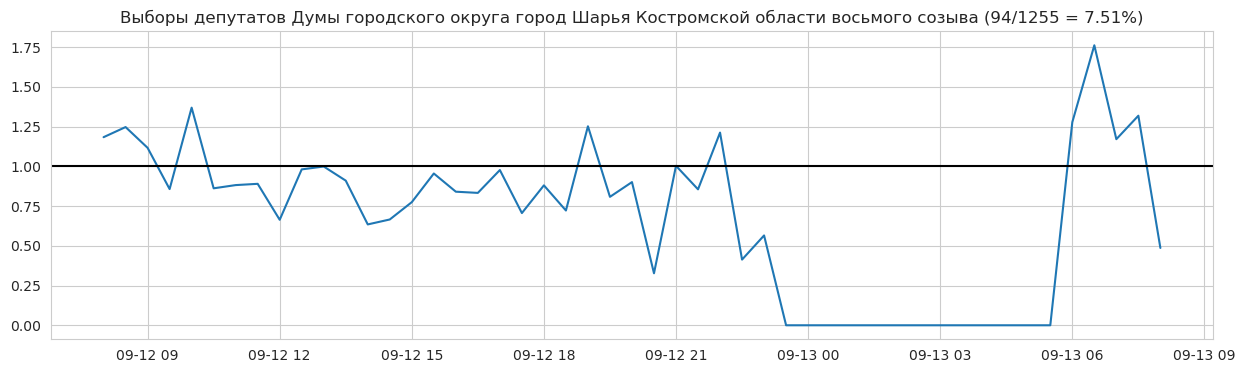

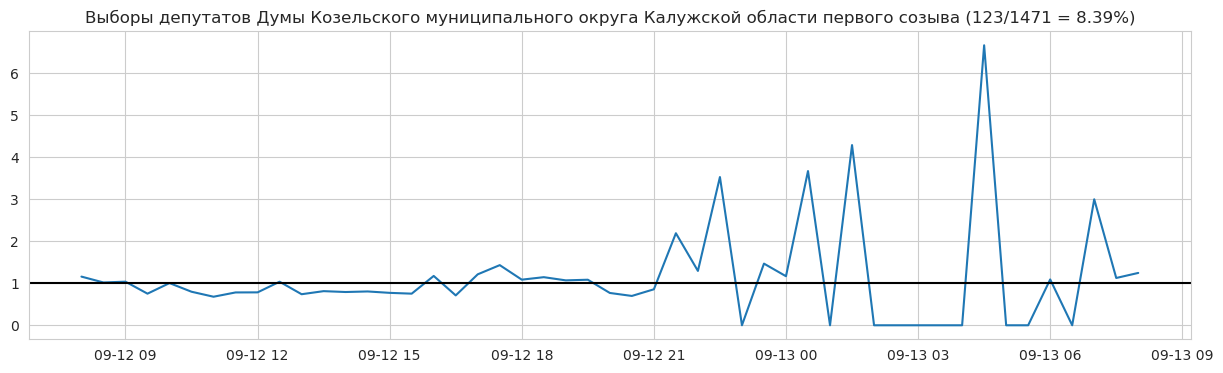

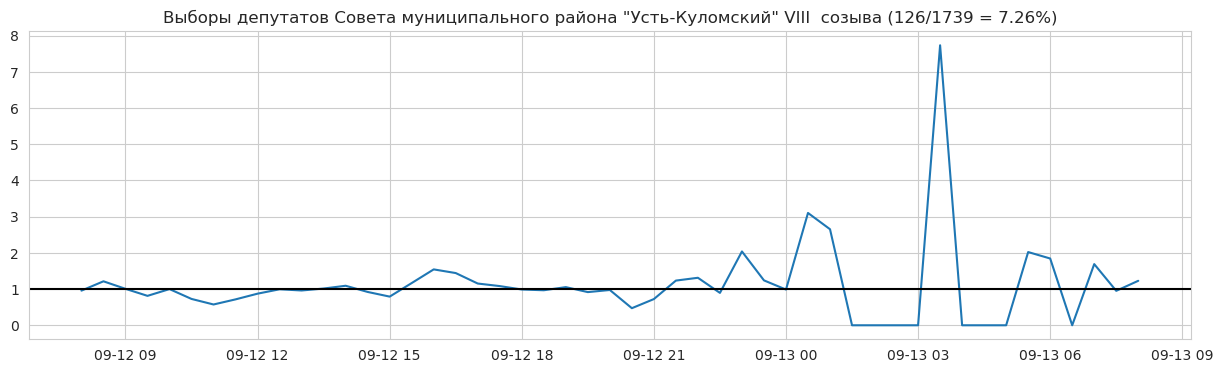

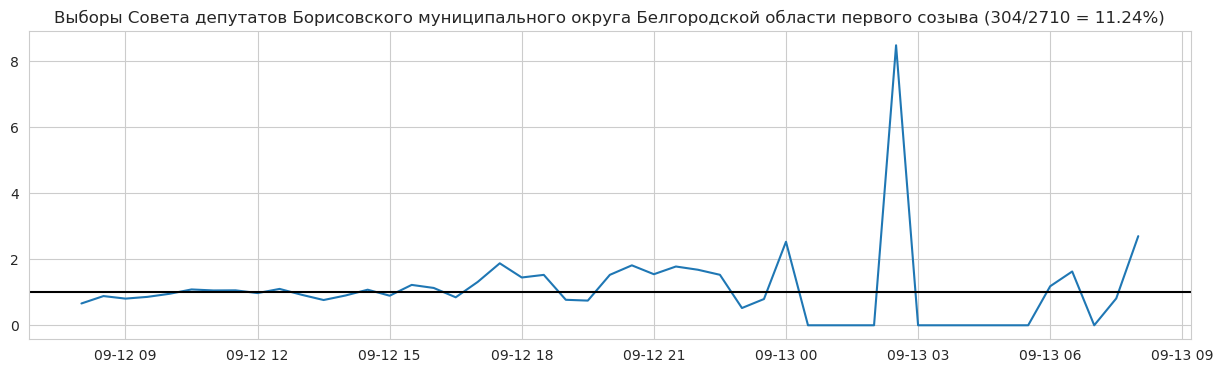

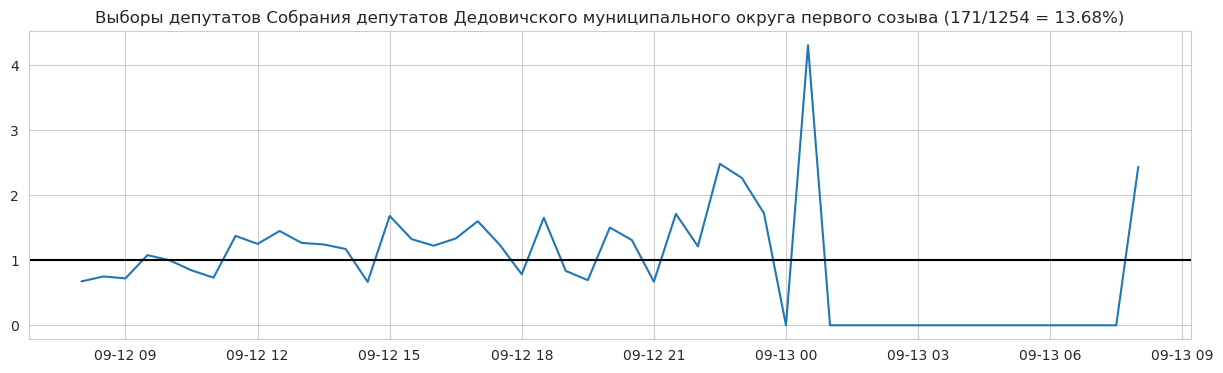

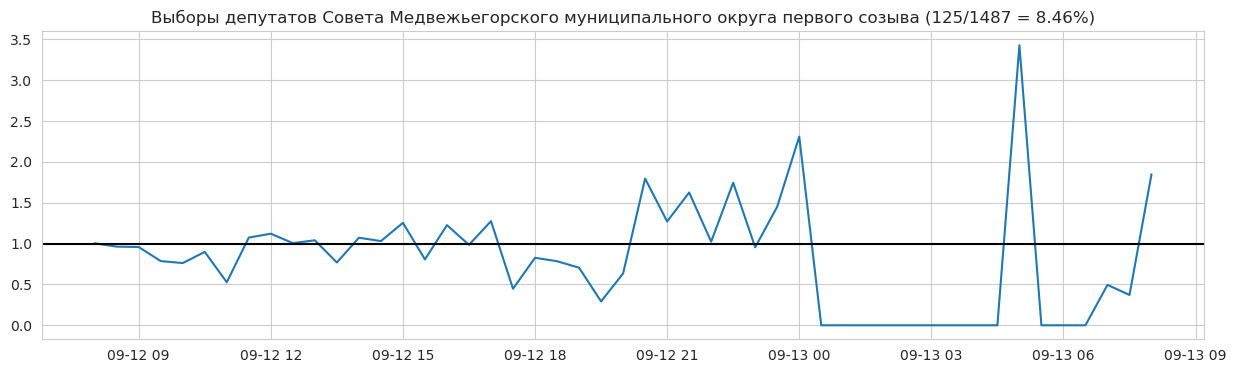

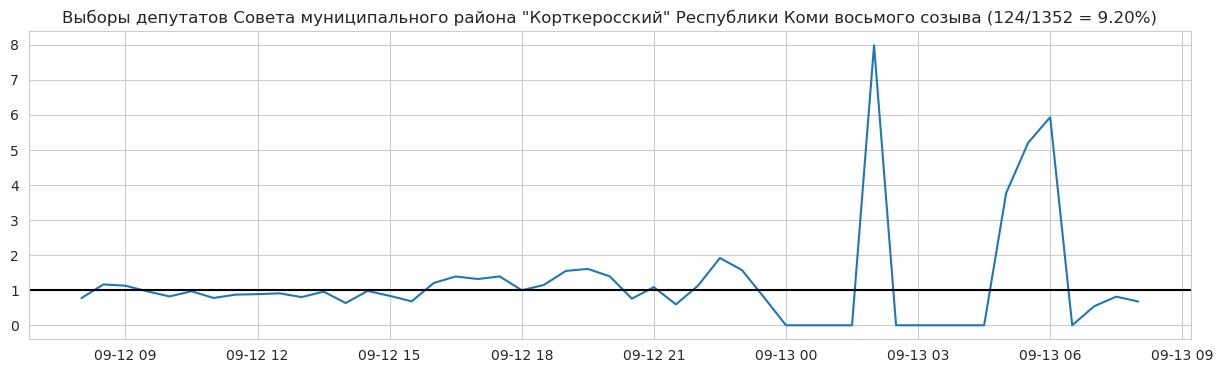

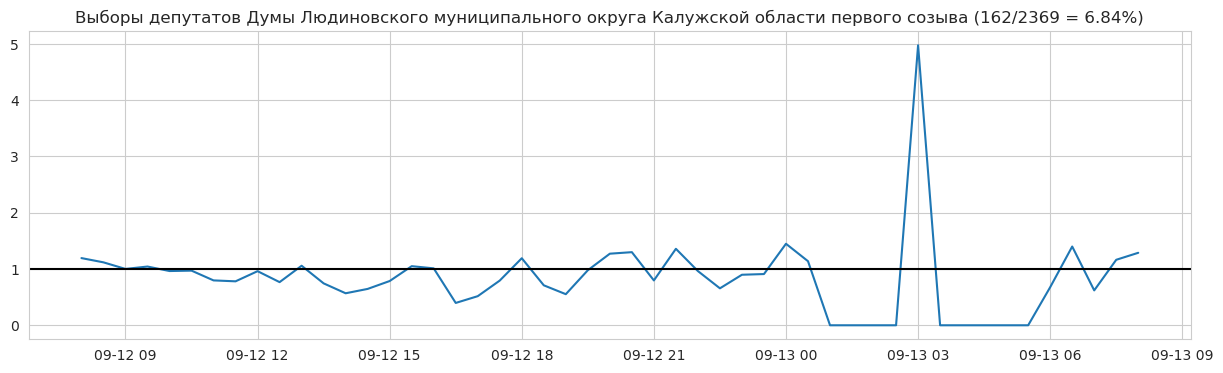

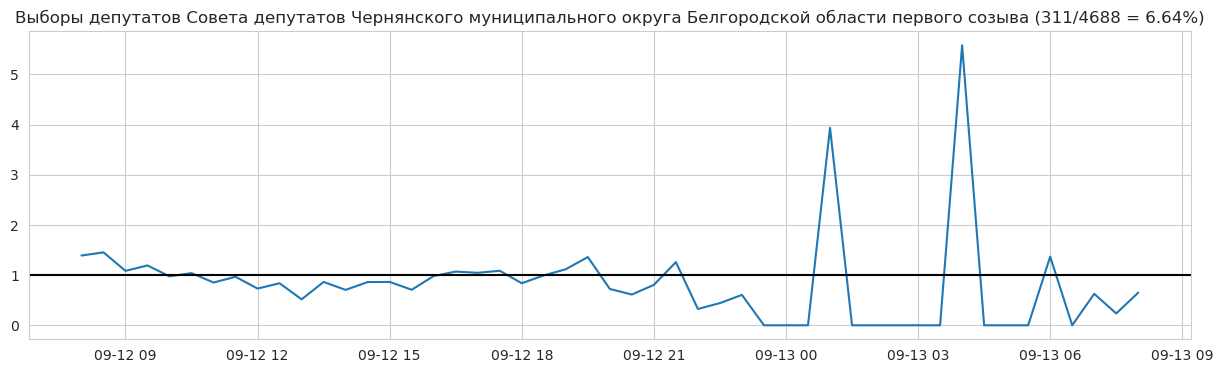

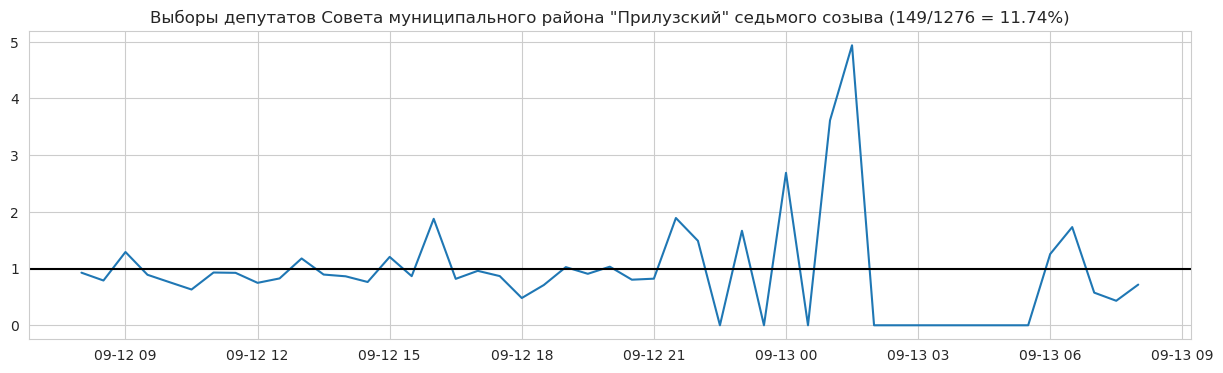

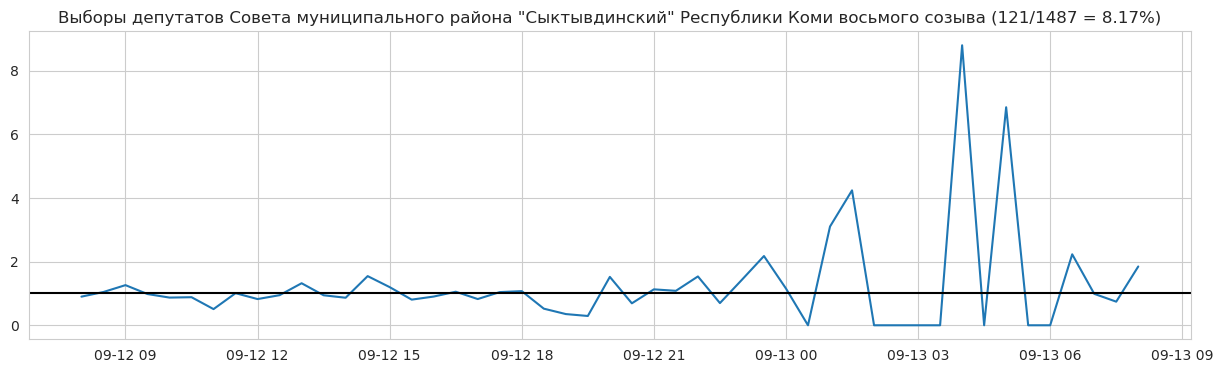

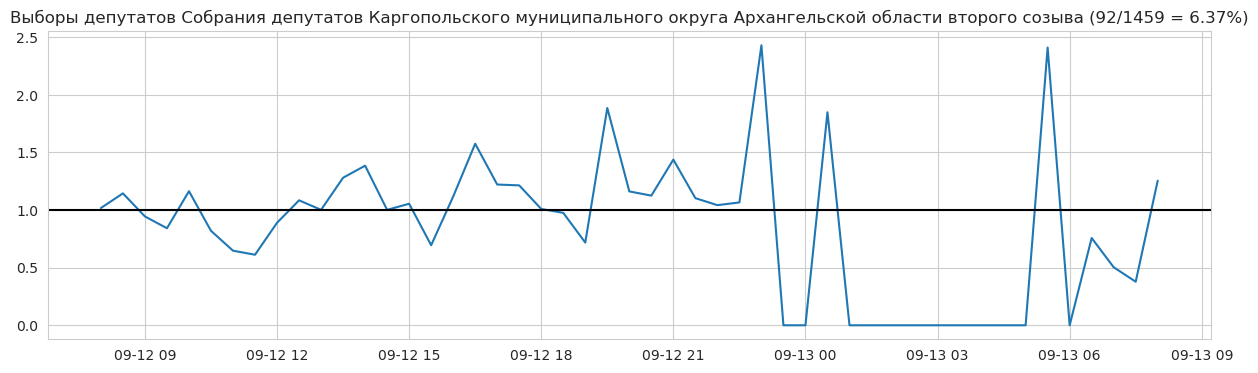

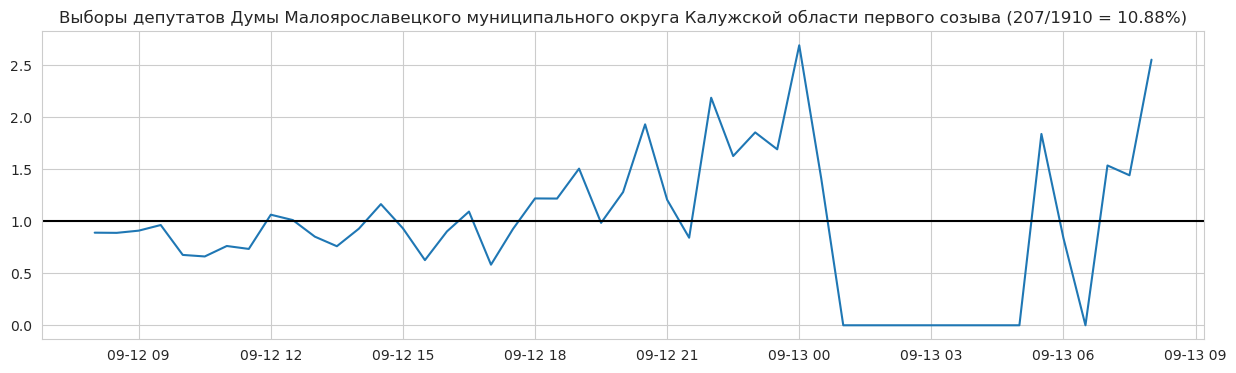

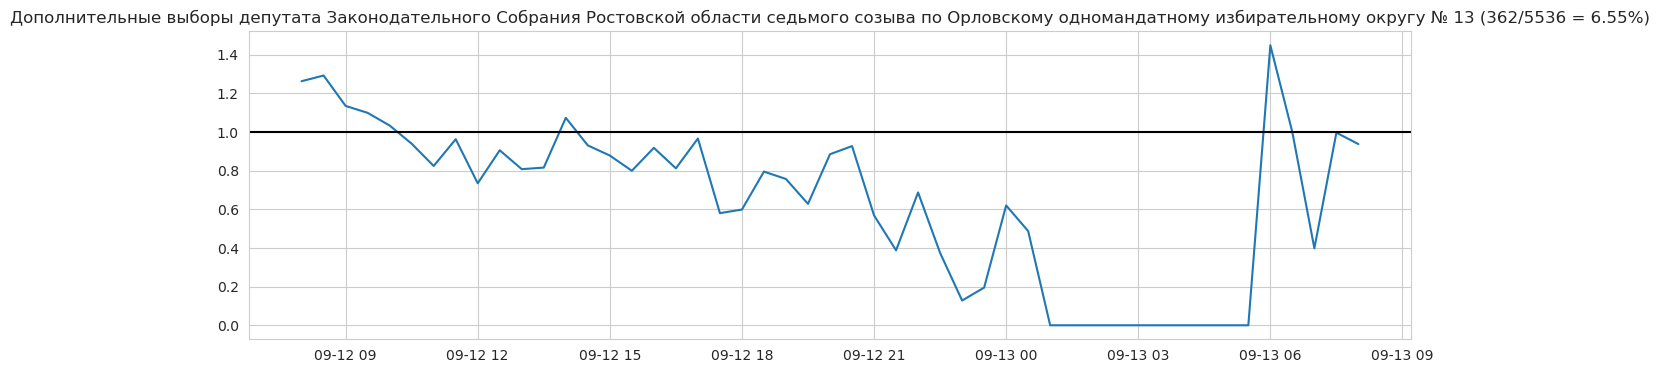

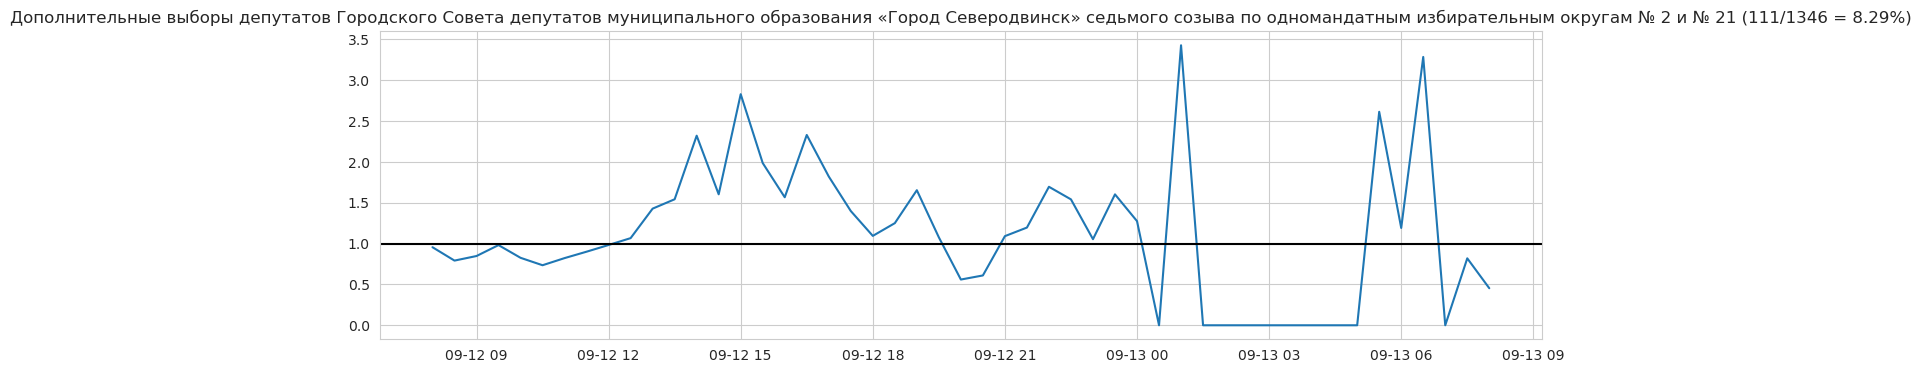

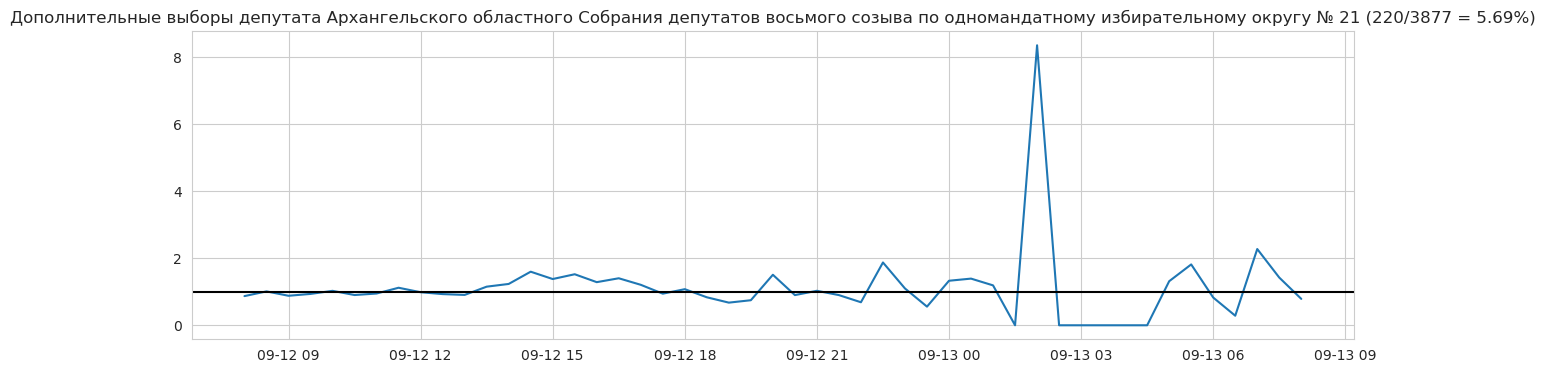

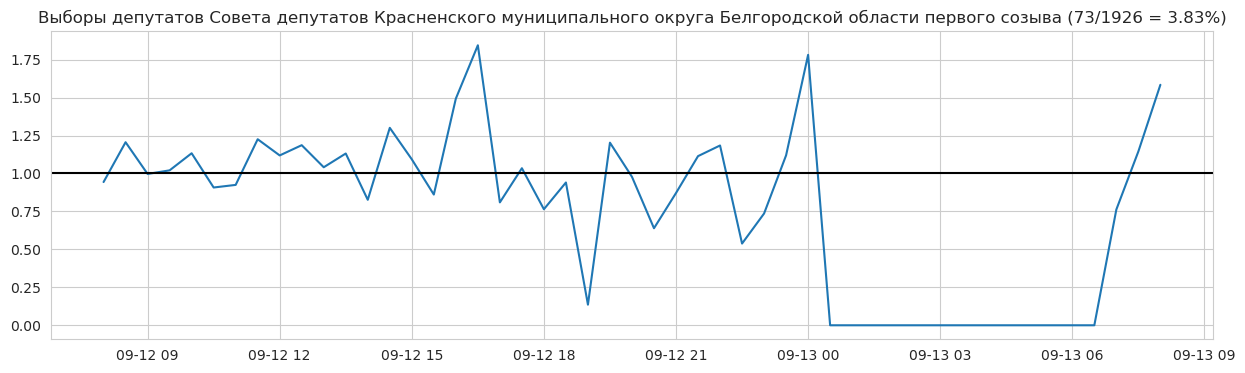

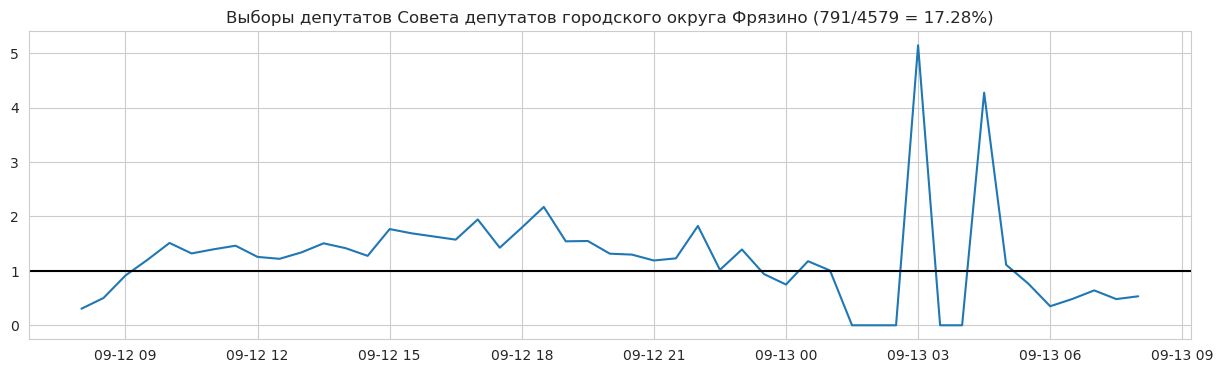

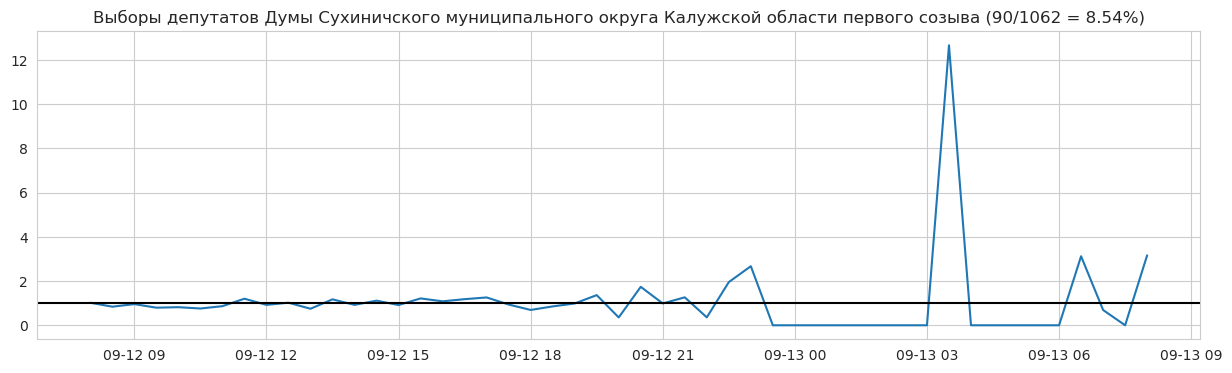

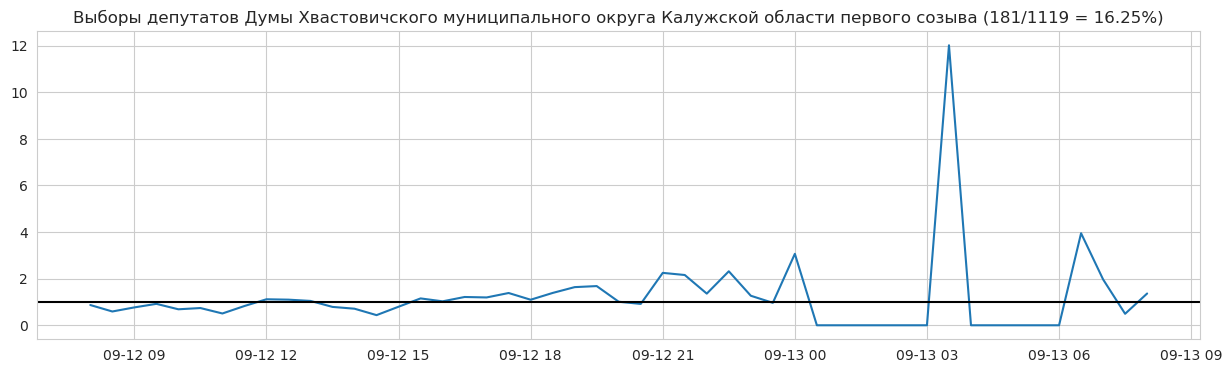

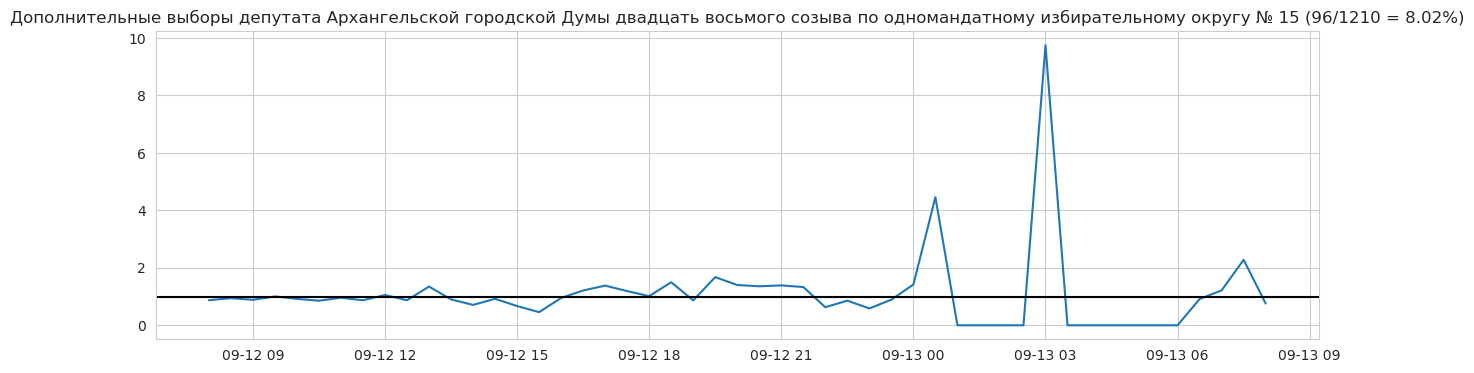

In [74]:
for election in threeday.election.unique():
    election_df = threeday.query('election == @election')
    total = len(election_df)
    negative = 0

    data = []

    for current in pd.date_range(start, end, freq=increment):
        count = len(election_df.query(
             f'"{current}" <= timestamp < "{current+increment}"'
        ))
        diff = count/total - reference[current]
        relative = count/total / reference[current]
        #data.append(diff)
        data.append(relative)
        if diff < 0:
            negative -= total * diff
    
    if total > 1000:# and (max(data) > 0.005 or min(data) < -0.005):
        plt.figure(figsize=(15, 4))
        plt.plot(pd.date_range(start, end, freq=increment), data)
        plt.axhline(1, color='black')
        plt.title(f'{election} ({int(negative)}/{total} = {negative/total:.2%})')
        plt.show()

26.65% = 22960 / 86143: Выборы Губернатора Архангельской области
22.34% = 41593 / 186222: Выборы Главы Чувашской Республики
24.16% = 3642 / 15073: Выборы депутатов Новочебоксарского городского Собрания депутатов восьмого созыва
24.00% = 967 / 4030: Выборы депутатов Собрания депутатов Вельского муниципального округа Архангельской области первого созыва
24.51% = 56979 / 232510: Выборы Губернатора Ростовской области
17.32% = 22898 / 132242: Выборы депутатов Ростовской-на-Дону городской Думы восьмого созыва


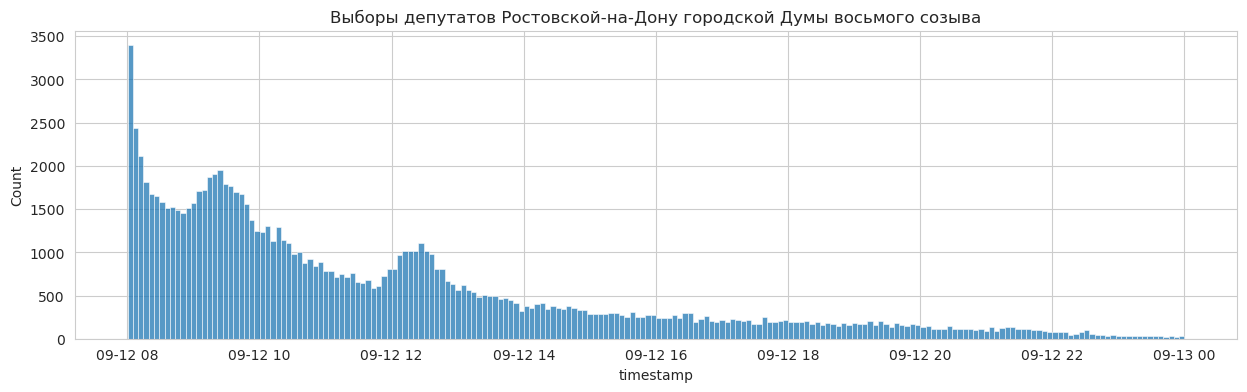

16.93% = 3766 / 22250: Выборы Губернатора города Севастополя


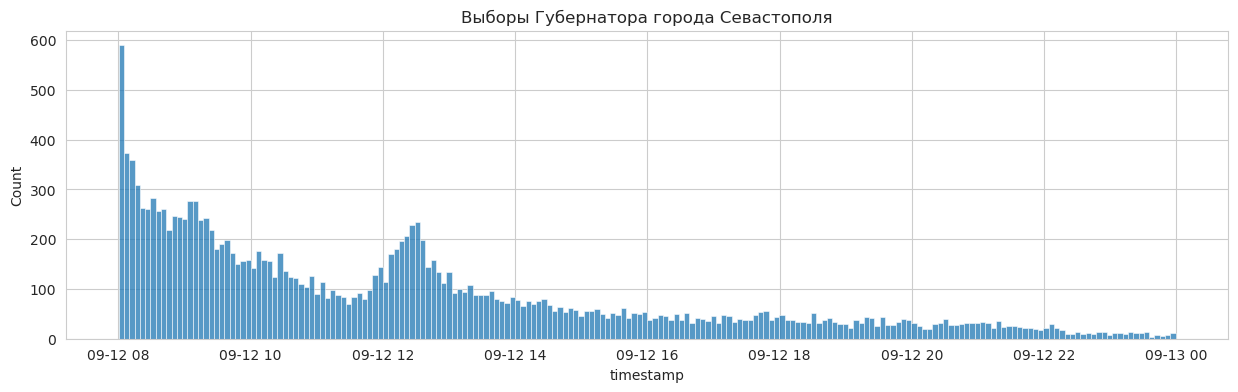

25.37% = 26220 / 103336: Выборы депутатов Законодательного Собрания Калужской области восьмого созыва
25.37% = 13110 / 51668: Выборы Губернатора Калужской области
32.28% = 54366 / 168436: Выборы депутатов Белгородской областной Думы восьмого созыва
29.47% = 35078 / 119048: Выборы депутатов Государственного Совета Республики Коми VIII созыва
33.10% = 3004 / 9076: Выборы депутатов Совета муниципального округа "Ухта" 7-го созыва
29.47% = 17539 / 59524: Выборы Главы Республики Коми
16.62% = 1180 / 7099: Выборы депутатов Совета Гагаринского муниципального округа четвертого созыва
29.93% = 2838 / 9483: Выборы депутатов Городской Думы города Новочеркасска восьмого созыва
15.36% = 2255 / 14680: Выборы депутатов Совета депутатов Городского округа Подольск Московской области


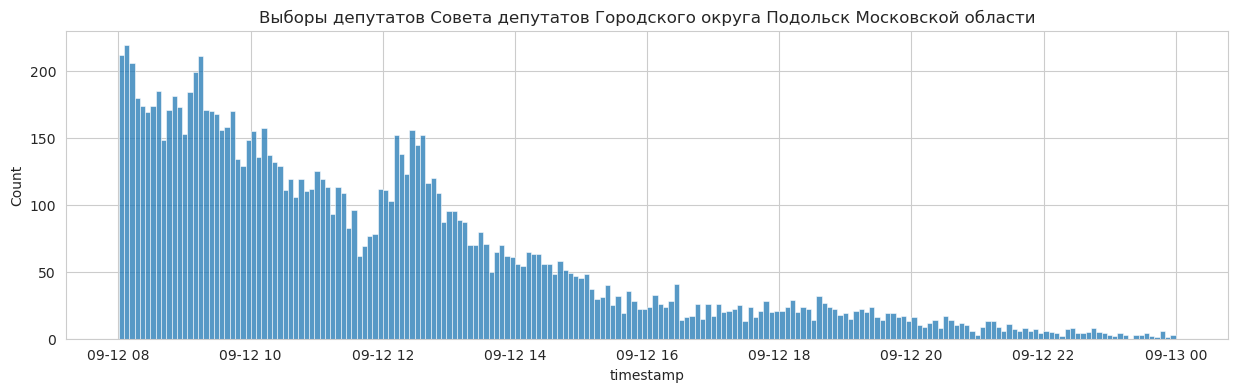

27.60% = 220 / 797: Выборы депутатов Собрания депутатов Вилегодского муниципального округа Архангельской области второго созыва
26.22% = 9886 / 37702: Выборы депутатов Липецкого городского Совета депутатов седьмого созыва
33.99% = 18946 / 55738: Выборы депутатов Костромской областной Думы восьмого созыва
35.83% = 5710 / 15937: Выборы депутатов Думы города Костромы восьмого созыва
31.37% = 5890 / 18775: Досрочные выборы Губернатора Новгородской области
12.14% = 2512 / 20692: Выборы депутатов Совета депутатов Городского округа Балашиха


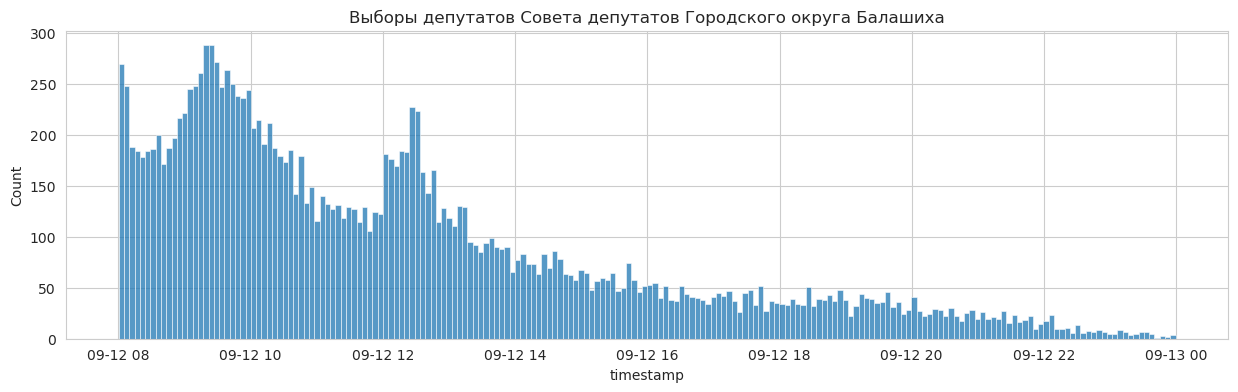

30.20% = 591 / 1957: Выборы депутатов Думы Новгородского муниципального округа Новгородской области первого созыва
28.71% = 907 / 3159: Выборы депутатов Совета муниципального района "Печора" восьмого созыва
25.69% = 38302 / 149108: Выборы депутатов Чебоксарского городского Собрания депутатов восьмого созыва
28.46% = 798 / 2804: Выборы депутатов Собрания депутатов Себежского муниципального округа первого созыва
22.18% = 1902 / 8576: Выборы депутатов Совета депутатов Дмитровского муниципального округа Московской области
30.98% = 1212 / 3912: Выборы депутатов Совета депутатов Ивнянского муниципального округа Белгородской области первого созыва
32.98% = 1186 / 3596: Выборы депутатов Совета депутатов Корочанского муниципального округа Белгородской области первого созыва
35.22% = 1754 / 4980: Выборы депутатов Совета депутатов Красногвардейского муниципального округа Белгородской области первого созыва
29.52% = 4484 / 15192: Выборы депутатов Совета депутатов Белгородского муниципального округ

In [20]:
for election in threeday.election.unique():
    first_hour = len(threeday.query('election == @election and timestamp < "2025-09-12 09:00:00"'))
    total = len(threeday.query('election == @election'))
    print(f"{first_hour/total:.2%} = {first_hour} / {total}: {election}")
    if total > 10000 and first_hour / total < 0.2:
        plt.figure(figsize=(15, 4))
        sns.histplot(pd.to_datetime(threeday.query('election == @election and timestamp < "2025-09-13 00:00:00"').timestamp), bins=200)
        plt.title(election)
        plt.show()